# The Tokyo 09:55 fix and "gotobi" days: is the USD/JPY anomaly still alive?

**The anomaly.** Japanese banks set their customer FX rate (the TTM) from the interbank USD/JPY price at **09:55 Tokyo**.
Corporate settlements cluster on *gotobi* days — the 5th, 10th, 15th, 20th, 25th and last business day of each month —
and Japanese importers are structural USD buyers. Ito & Yamada (2017) documented that USD/JPY drifts **up into 09:55 on
gotobi days** and partly reverts afterwards. Every Tokyo dealer knows it as the "gotobi buy".

**What we test, 2022–2026, on 1-minute data.**
1. Is 09:55 still a visible fix event?
2. Does the pre-fix drift on gotobi days still exist, ten years after publication?
3. Is there a post-fix reversal, and is it specific to gotobi days and to the fix time?
4. Does it survive a battery of significance tests (permutation, calendar shifts, placebo times, outliers, controls, forward walk)?
5. Is it tradeable after cost?

**Headline.** The pre-fix drift has been competed out of the 09:00–09:55 window (it now shows up 08:00–09:00). The
**post-fix unwind is alive**: on gotobi days USD/JPY falls ≈ 2.5 bp in 09:55–10:30 vs ≈ 0 on other days (p = 0.003,
robust to everything below). Shorting USD/JPY 09:55→10:30 on gotobi days nets ≈ +2 bp per trade at a Sharpe ≈ 1.5 —
with the caveat that 2026 is the weakest year in the sample.

## 1. Data
**What this does.** USD/JPY 1-minute OHLC from Twelve Data (free tier: 8 calls/min, 800/day, 5,000 bars/call), pulled
backwards from today in pages, checkpointed to `data/usdjpy_1m.csv`. The pull is *skipped* by default so opening the
notebook doesn't spend API credits; set `RUN_PULL = True` to extend the history (it resumes from the oldest bar saved).

In [1]:
RUN_PULL = False        # True → (re)download / extend data/usdjpy_1m.csv; needs twelvedata.key next to this notebook
if RUN_PULL:
    import os, time, math, requests, pandas as pd
    from collections import deque
    API_KEY, SYMBOL, INTERVAL, TZ = open("twelvedata.key").read().strip(), "USD/JPY", "1min", "Asia/Tokyo"
    OUTPUTSIZE, FLOOR_DATE, PER_MIN, OUT_CSV = 5000, pd.Timestamp("2020-04-01"), 8, "data/usdjpy_1m.csv"
    os.makedirs("data", exist_ok=True); URL = "https://api.twelvedata.com/time_series"
    calls = deque()
    def wait():
        now = time.time()
        while calls and now - calls[0] >= 60: calls.popleft()
        if len(calls) >= PER_MIN: time.sleep(max(60 - (now - calls[0]) + 0.2, 0))
        calls.append(time.time())
    def fetch(end_date):
        while True:
            wait()
            r = requests.get(URL, params=dict(symbol=SYMBOL, interval=INTERVAL, outputsize=OUTPUTSIZE, timezone=TZ,
                                              end_date=end_date.strftime("%Y-%m-%d %H:%M:%S"), apikey=API_KEY), timeout=30).json()
            if r.get("status") == "error":
                msg, code = r.get("message", ""), r.get("code")
                if code == 429 and "for the day" in msg: return None, "daily_limit"
                if code == 429: time.sleep(60 - time.time() % 60 + 0.5); continue
                if code in (400, 404): return None, "nodata"
                raise RuntimeError(f"API error {code}: {msg}")
            vals = r.get("values", [])
            if not vals: return None, "nodata"
            df = pd.DataFrame(vals); df["datetime"] = pd.to_datetime(df["datetime"])
            for c in ["open", "high", "low", "close"]: df[c] = df[c].astype(float)
            return df[["datetime", "open", "high", "low", "close"]], "ok"
    if os.path.exists(OUT_CSV) and os.path.getsize(OUT_CSV) > 0:
        end_date = pd.to_datetime(pd.read_csv(OUT_CSV, usecols=["datetime"])["datetime"]).min() - pd.Timedelta(minutes=1)
    else:
        end_date = pd.Timestamp.now(tz=TZ).tz_localize(None) + pd.Timedelta(days=1)
    n = 0
    while end_date >= FLOOR_DATE:
        page, status = fetch(end_date)
        if status != "ok": print(status); break
        page.to_csv(OUT_CSV, mode="a", header=not os.path.exists(OUT_CSV) or os.path.getsize(OUT_CSV) == 0, index=False)
        end_date = page.datetime.min() - pd.Timedelta(minutes=1); n += 1
        if n % 25 == 0: print(f"{n} calls, oldest {end_date}")
    print(f"done: {n} calls, oldest = {end_date}")
else:
    print("pull skipped (RUN_PULL = False); using existing data/usdjpy_1m.csv")

pull skipped (RUN_PULL = False); using existing data/usdjpy_1m.csv


**What this does.** Loads the 1-minute file, keeps Tokyo hours **08:00–14:59**, removes bad prints (>5 % off the day's
median, or >100 bp off an 11-minute rolling median), keeps only full sessions, drops Japanese holidays (no fix), and
lays the data out as a *days × minutes* price grid. Minute 0 = 08:00; the fix price is the 09:54 close (= 09:55:00).
All returns below are log returns in **basis points**; positive = USD/JPY up (yen weaker).

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, holidays
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdjpy_1m.csv", parse_dates=["datetime"]).drop_duplicates("datetime").sort_values("datetime")
raw["date"] = raw.datetime.dt.normalize()
raw = raw[(raw.datetime.dt.dayofweek < 5) & (raw.datetime.dt.hour >= 8) & (raw.datetime.dt.hour < 15)]
raw["minute"] = (raw.datetime.dt.hour - 8) * 60 + raw.datetime.dt.minute
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
jp = holidays.JP(years=range(2019, 2028))
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
days = ok[ok].index; days = days[[d.date() not in jp for d in days]]
raw = raw[raw.date.isin(days)]
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
lpx = np.log(px); r1 = lpx.diff(axis=1) * 1e4
def bp(a, b): return (lpx[b] - lpx[a]) * 1e4
def lab(m): return f"{8 + m // 60:02d}:{m % 60:02d}"
FIX = 114
years = px.index.year
print(f"{len(px)} Tokyo sessions, {px.index.min().date()} → {px.index.max().date()}")

1082 Tokyo sessions, 2022-04-12 → 2026-09-16


**What this does.** Builds the gotobi calendar: the 5th/10th/15th/20th/25th and the last business day of each month.
If one falls on a weekend or Japanese holiday it is moved **back** to the previous business day (the settlement convention).

In [3]:
def is_bday(d): return d.weekday() < 5 and d.date() not in jp
gotobi_dates, kind = set(), {}
for m in pd.period_range(px.index.min(), px.index.max(), freq="M"):
    for dd in [5, 10, 15, 20, 25, "eom"]:
        d = m.end_time.normalize() if dd == "eom" else pd.Timestamp(m.year, m.month, dd)
        while not is_bday(d): d -= pd.Timedelta(days=1)
        gotobi_dates.add(d); kind[d] = "eom" if dd == "eom" else str(dd)
G = pd.Series(px.index.isin(gotobi_dates), index=px.index, name="gotobi")
K = pd.Series([kind.get(d, "none") for d in px.index], index=px.index)
print(f"gotobi sessions: {G.sum()} of {len(G)} ({G.mean():.1%});  by type: {K[G].value_counts().to_dict()}")

gotobi sessions: 313 of 1082 (28.9%);  by type: {'15': 54, 'eom': 53, '20': 52, '5': 52, '10': 52, '25': 50}


## 2. Is 09:55 a fix event?
**What this does.** Mean absolute 1-minute return around 09:55, gotobi vs other days (left), and the cumulative signed
return from 09:24 (right). A fix should show as a volatility spike; the gotobi story predicts a signed drift too.

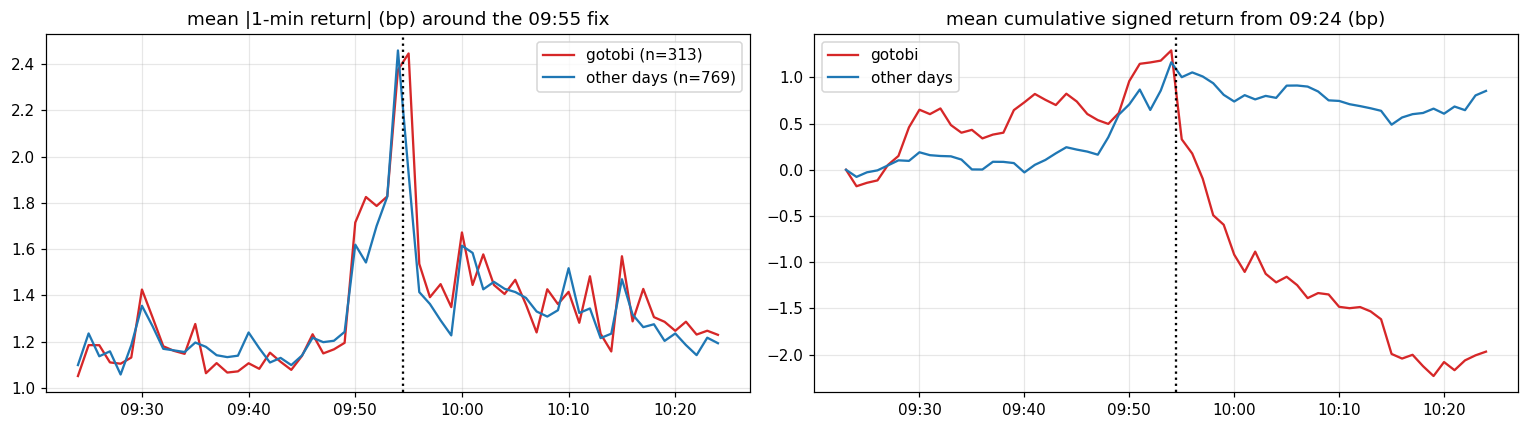

|move| in the 09:54–09:55 bars: 4.51 bp vs 2.65 bp for two neighbouring minutes (ratio 1.70, Wilcoxon p = 5.4e-89)
gotobi 4.82 bp vs other 4.39 bp (Mann–Whitney p = 0.072)


In [4]:
z = range(84, 145)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
    ax[0].plot(z, r1.loc[m_, list(z)].abs().mean(), color=c, label=f"{l} (n={m_.sum()})")
    ax[1].plot([z[0] - 1, *z], [0, *r1.loc[m_, list(z)].mean().cumsum()], color=c, label=l)  # anchor at 0 on the 09:23 close
ax[0].set_title("mean |1-min return| (bp) around the 09:55 fix"); ax[1].set_title("mean cumulative signed return from 09:24 (bp)")
for a in ax:
    a.axvline(FIX + .5, color="k", ls=":"); a.set_xticks(range(90, 145, 10)); a.set_xticklabels([lab(m) for m in range(90, 145, 10)]); a.legend()
plt.tight_layout(); plt.show()
fx = r1[[114, 115]].abs().sum(axis=1); nb = r1[list(range(100, 112)) + list(range(118, 130))].abs().mean(axis=1) * 2
print(f"|move| in the 09:54–09:55 bars: {fx.mean():.2f} bp vs {nb.mean():.2f} bp for two neighbouring minutes (ratio {fx.mean() / nb.mean():.2f}, Wilcoxon p = {stats.wilcoxon(fx - nb).pvalue:.1e})")
print(f"gotobi {fx[G].mean():.2f} bp vs other {fx[~G].mean():.2f} bp (Mann–Whitney p = {stats.mannwhitneyu(fx[G], fx[~G]).pvalue:.3f})")

**Interpretation.** The fix is unmistakable: the two minutes at 09:55 move 1.7× as much as their neighbours
(p ≈ 10⁻⁸⁹), and slightly more on gotobi days. On the right, gotobi days (red) rise into 09:55 and then drop sharply in
the minutes after it, while other days (blue) are flat. That is the shape Ito & Yamada described — but note how much of
the red line's rise happens *before* 09:30.

## 3. Pre-fix drift and post-fix reversal
**What this does.** Compares gotobi vs other days in fixed windows — before the fix (09:00→09:55, 09:30→09:55,
09:45→09:55), after it (09:55→10:30, 09:55→11:00) and the early morning (08:00→09:00) — with Welch t-tests and
Mann–Whitney tests, then plots the average price path from 09:00 with 95 % confidence bands.

window          gotobi mean  other mean    diff   Welch p      MW p  gotobi %up
09:00→09:55            1.28        0.91    0.37     0.709     0.395       56.9%
09:30→09:55            0.64        0.97   -0.33     0.588     0.557       55.0%
09:45→09:55            0.55        0.94   -0.39     0.419     0.476       53.4%
09:55→10:30           -2.54       -0.29   -2.25     0.003     0.001       39.3%
09:55→11:00           -2.55       -0.65   -1.90     0.045     0.110       43.5%
08:00→09:00            0.89       -0.57    1.46     0.032     0.009       57.2%


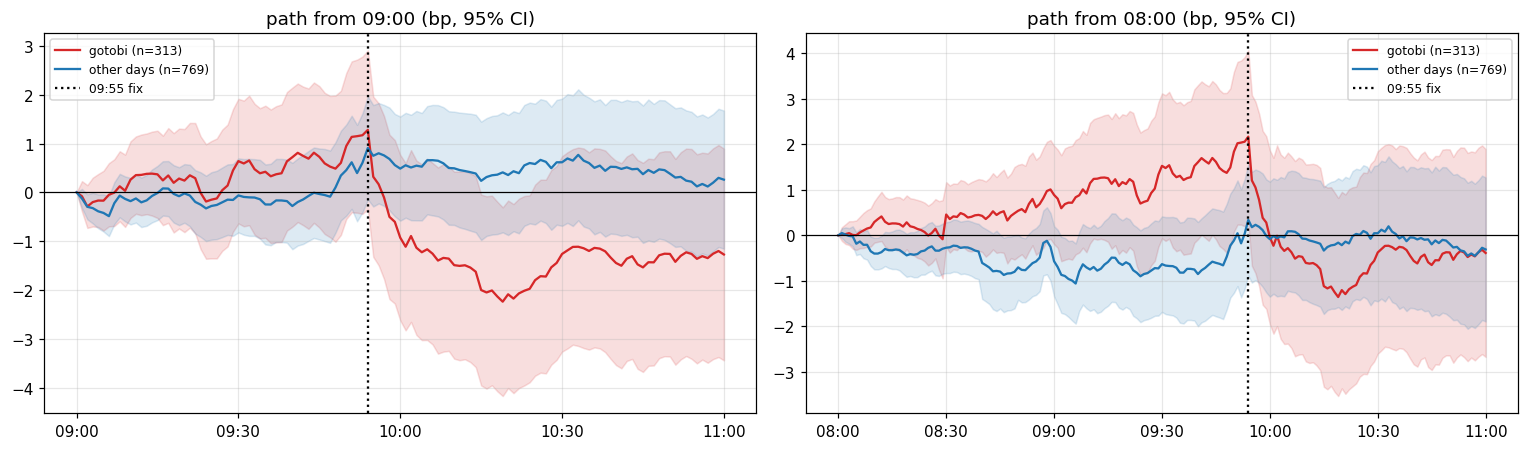


09:55→10:30 regressed on the pre-fix move, a gotobi dummy and their interaction (HC3):
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2536      0.441     -0.576      0.565      -1.117       0.610
pre_fix_move    -0.0418      0.084     -0.495      0.621      -0.207       0.124
gotobi          -2.1772      0.794     -2.743      0.006      -3.733      -0.622
pre_x_gotobi    -0.1335      0.130     -1.030      0.303      -0.387       0.120


In [5]:
W = {"09:00→09:55": (60, FIX), "09:30→09:55": (90, FIX), "09:45→09:55": (105, FIX), "09:55→10:30": (FIX, 150), "09:55→11:00": (FIX, 180), "08:00→09:00": (0, 60)}
D = pd.DataFrame({k: bp(*v) for k, v in W.items()}); D["gotobi"] = G; D["kind"] = K; D["year"] = years
print(f"{'window':14s} {'gotobi mean':>12s} {'other mean':>11s} {'diff':>7s} {'Welch p':>9s} {'MW p':>9s} {'gotobi %up':>11s}")
for k in W:
    a, b = D.loc[G, k], D.loc[~G, k]
    print(f"{k:14s} {a.mean():12.2f} {b.mean():11.2f} {a.mean() - b.mean():7.2f} {stats.ttest_ind(a, b, equal_var=False).pvalue:9.3f} {stats.mannwhitneyu(a, b).pvalue:9.3f} {(a > 0).mean():11.1%}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a_, start, ttl in [(ax[0], 60, "path from 09:00 (bp, 95% CI)"), (ax[1], 0, "path from 08:00 (bp, 95% CI)")]:
    path = (lpx.sub(lpx[start], axis=0) * 1e4).loc[:, start:180]
    for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
        p = path[m_]; mu, se = p.mean(), p.std() / np.sqrt(len(p))
        a_.plot(p.columns, mu, color=c, label=f"{l} (n={m_.sum()})"); a_.fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.15)
    a_.axvline(FIX, color="k", ls=":", label="09:55 fix"); a_.axhline(0, color="k", lw=.8); a_.legend(fontsize=8); a_.set_title(ttl)
    a_.set_xticks(range(start, 181, 30)); a_.set_xticklabels([lab(m) for m in range(start, 181, 30)])
plt.tight_layout(); plt.show()
m = sm.OLS(D["09:55→10:30"], sm.add_constant(pd.DataFrame({"pre_fix_move": D["09:30→09:55"], "gotobi": G.astype(float), "pre_x_gotobi": D["09:30→09:55"] * G})), missing="drop").fit(cov_type="HC3")
print("\n09:55→10:30 regressed on the pre-fix move, a gotobi dummy and their interaction (HC3):"); print(m.summary().tables[1])

**Interpretation.**
- **The textbook drift is gone.** 09:00→09:55 on gotobi days is +1.3 bp vs +0.9 bp on other days — no difference (p = 0.7).
- **It moved earlier.** 08:00→09:00 is +0.9 bp on gotobi vs −0.6 bp otherwise (p = 0.03; Mann–Whitney 0.009). The
  importer demand is being front-run before most Tokyo desks are in. The right-hand chart shows the whole climb now
  happens 08:00–09:55.
- **The post-fix reversal is alive.** 09:55→10:30 is **−2.5 bp on gotobi days vs −0.3 bp** on other days (Welch
  p = 0.003, Mann–Whitney p = 0.001). Only 39 % of gotobi days are up in that window. In the regression the gotobi dummy
  is −2.2 bp (t = −2.7) *after* controlling for the size of the pre-fix move — it's the day type, not just the size of the run-up.
- Round trip 08:00→10:30 on gotobi days nets to ≈ 0: everything bought into the fix is sold back after it.

## 4. Which gotobi days, and is it stable over time?
**What this does.** Splits the pre-fix and post-fix returns by settlement-day type (5/10/15/20/25/month-end) and shows the
gotobi-minus-other post-fix difference year by year.

        n   pre  pre_sd  post  post_sd
kind                                  
5      52 -2.15   13.74 -1.08    11.13
10     52 -1.80   18.35 -0.84    11.45
15     54  2.40   12.84 -1.68    11.81
20     52  2.24   11.16 -3.24    11.89
25     50  3.16   14.37 -3.59    10.92
eom    53  3.81   16.15 -4.86    11.52
none  769  0.91   14.97 -0.29    11.36

post-fix (09:55→10:30) gotobi vs other, by year:
      gotobi  other   n_g      p   diff
2022  -4.739 -2.363  50.0  0.279 -2.376
2023  -1.945  0.249  71.0  0.211 -2.194
2024  -2.827 -0.298  71.0  0.104 -2.529
2025  -3.356 -0.293  70.0  0.065 -3.063
2026   0.287  1.048  51.0  0.572 -0.761


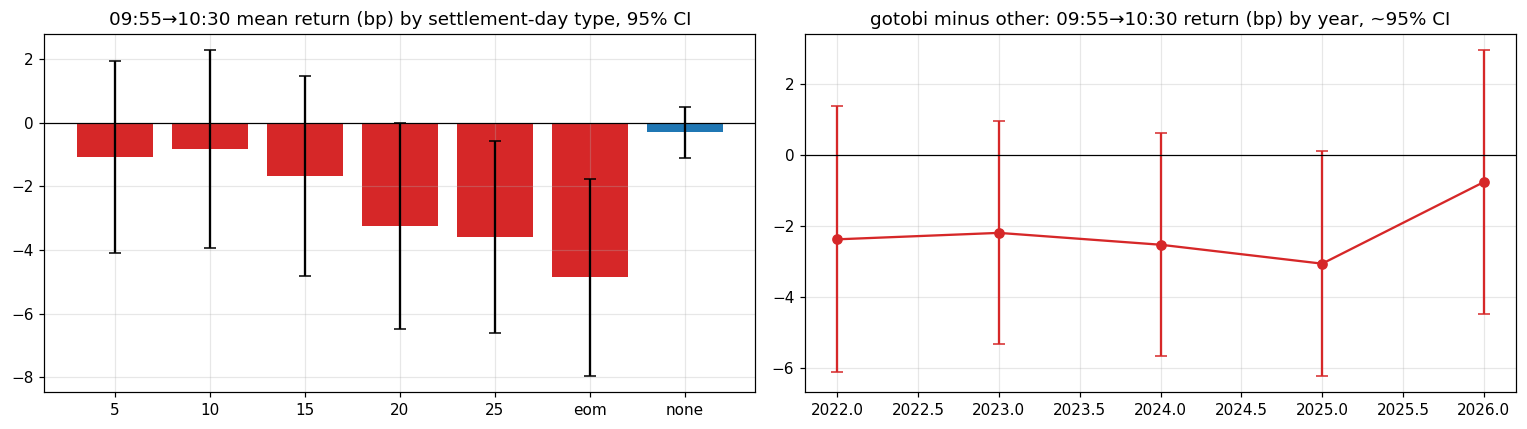

In [6]:
T = D.groupby("kind").agg(n=("09:00→09:55", "size"), pre=("09:00→09:55", "mean"), pre_sd=("09:00→09:55", "std"), post=("09:55→10:30", "mean"), post_sd=("09:55→10:30", "std")).loc[["5", "10", "15", "20", "25", "eom", "none"]]
print(T.round(2))
post = D["09:55→10:30"]
Yp = pd.DataFrame({y: dict(gotobi=post[G & (years == y)].mean(), other=post[~G & (years == y)].mean(), n_g=int((G & (years == y)).sum()),
                            p=stats.ttest_ind(post[G & (years == y)], post[~G & (years == y)], equal_var=False).pvalue) for y in sorted(set(years))}).T
Yp["diff"] = Yp.gotobi - Yp.other; print("\npost-fix (09:55→10:30) gotobi vs other, by year:"); print(Yp.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(T.index, T.post, yerr=1.96 * T.post_sd / np.sqrt(T.n), capsize=4, color=["C3"] * 6 + ["C0"]); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_title("09:55→10:30 mean return (bp) by settlement-day type, 95% CI")
ax[1].errorbar(Yp.index.astype(int), Yp["diff"], yerr=1.96 * np.sqrt(post[G].var() / Yp.n_g + post[~G].var() / (Yp.n_g * 2.5)), fmt="o-", capsize=4, color="C3"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("gotobi minus other: 09:55→10:30 return (bp) by year, ~95% CI")
plt.tight_layout(); plt.show()

**Interpretation.** The reversal is carried by the **20th, 25th and month-end** (−3.2, −3.6, −4.9 bp) — the heavy
settlement days — while the 5th and 10th contribute little. Those same days are the only ones where the *pre*-fix drift
survives (+3.2 / +3.8 bp on the 25th and EOM). Year by year the post-fix difference is negative in **2022, 2023, 2024 and
2025** (−2.2 to −3.1 bp) and shrinks to −0.8 bp in **2026** (n = 51). Either a thin year or the effect being competed away — we can't tell yet.

## 5. Is it significant? A stress test
**What this does.** One significant window out of six deserves more than a t-stat. (a) **Permutation**: reassign the
gotobi label to random days 5,000 times. (b) **Calendar shift**: move the gotobi calendar by ±1…±5 business days (larger shifts alias back onto the true dates, since settlements are only 3–4 business days apart) —
a real settlement effect should vanish at every shift. (c) **Placebo times**: the same gotobi-vs-other test in 35-minute
windows at every other time of day — the effect should be specific to windows containing 09:55.

(a) permutation: observed diff = -2.25 bp;  two-sided p = 0.0030;  null sd = 0.77 bp → z = -2.94
(b) calendar shift: true dates -2.25 bp (p 0.003);  shifted calendars: mean +0.36, range [-0.75, +1.34];  true dates rank 1 of 11
(c) placebo times: windows containing the fix: t from -4.12 to -2.03;  clean windows elsewhere: |t| > 2 in 4 of 60 (≈3 expected by chance)


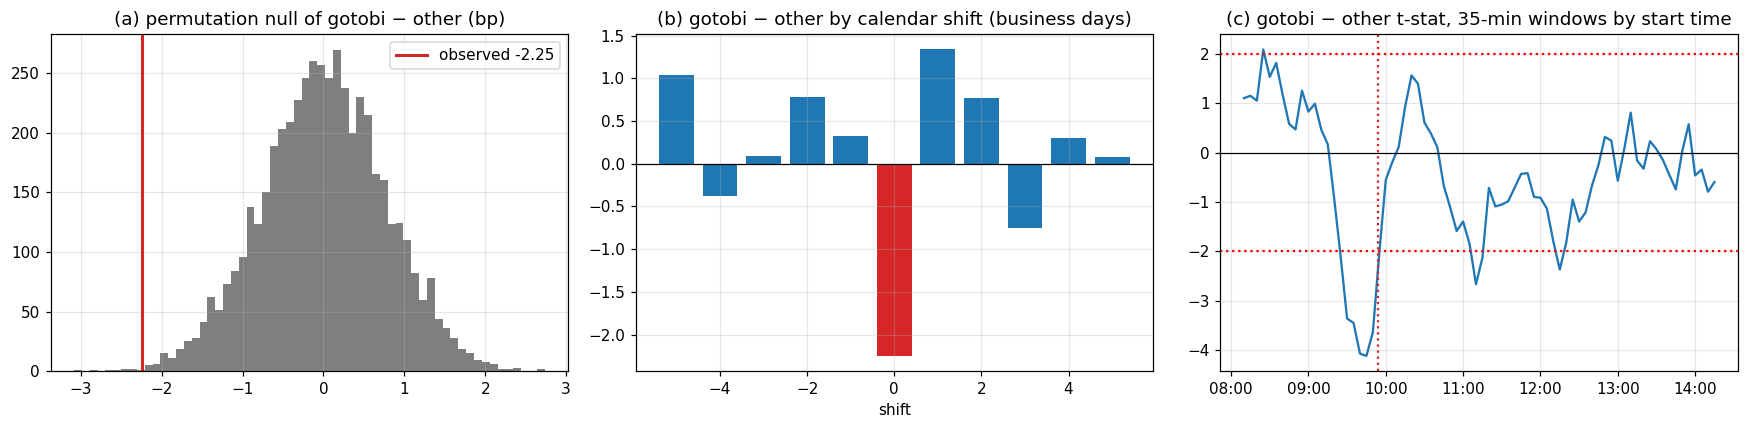

In [7]:
rng = np.random.default_rng(1)
y = D["09:55→10:30"]; gg = G.values; obs = y[gg].mean() - y[~gg].mean()
perm = np.array([(lambda m: y[m].mean() - y[~m].mean())(rng.permutation(gg)) for _ in range(5000)])
print(f"(a) permutation: observed diff = {obs:+.2f} bp;  two-sided p = {(np.abs(perm) >= abs(obs)).mean():.4f};  null sd = {perm.std():.2f} bp → z = {obs / perm.std():.2f}")
bd = pd.Series(np.arange(len(px)), index=px.index); sh = []
for k in range(-5, 6):
    idx = bd[G].values + k; idx = idx[(idx >= 0) & (idx < len(px))]; m = np.zeros(len(px), bool); m[idx] = True
    sh.append(dict(shift=k, diff=y[m].mean() - y[~m].mean(), p=stats.ttest_ind(y[m], y[~m], equal_var=False).pvalue))
SH = pd.DataFrame(sh).set_index("shift")
print(f"(b) calendar shift: true dates {SH.loc[0, 'diff']:+.2f} bp (p {SH.loc[0, 'p']:.3f});  shifted calendars: mean {SH.drop(0)['diff'].mean():+.2f}, range [{SH.drop(0)['diff'].min():+.2f}, {SH.drop(0)['diff'].max():+.2f}];  true dates rank {int((SH['diff'] <= SH.loc[0, 'diff']).sum())} of 11")
pt = []
for t0 in range(10, 380, 5):
    r_ = bp(t0, t0 + 35); pt.append(dict(t=t0, tstat=stats.ttest_ind(r_[G], r_[~G], equal_var=False).statistic))
PT = pd.DataFrame(pt).set_index("t"); clean = PT[(PT.index < FIX - 35) | (PT.index > FIX + 35)]
print(f"(c) placebo times: windows containing the fix: t from {PT.loc[95:115, 'tstat'].min():.2f} to {PT.loc[95:115, 'tstat'].max():.2f};  clean windows elsewhere: |t| > 2 in {(clean.tstat.abs() > 2).sum()} of {len(clean)} (≈{0.05 * len(clean):.0f} expected by chance)")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(perm, bins=60, color="C7"); ax[0].axvline(obs, color="C3", lw=2, label=f"observed {obs:+.2f}"); ax[0].set_title("(a) permutation null of gotobi − other (bp)"); ax[0].legend()
ax[1].bar(SH.index, SH["diff"], color=["C3" if k == 0 else "C0" for k in SH.index]); ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("(b) gotobi − other by calendar shift (business days)"); ax[1].set_xlabel("shift")
ax[2].plot(PT.index, PT.tstat); ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(-2, color="r", ls=":"); ax[2].axhline(2, color="r", ls=":"); ax[2].axvline(FIX, color="C3", ls=":")
ax[2].set_xticks(range(0, 420, 60)); ax[2].set_xticklabels([lab(m) for m in range(0, 420, 60)]); ax[2].set_title("(c) gotobi − other t-stat, 35-min windows by start time")
plt.tight_layout(); plt.show()

**Interpretation.** (a) The observed −2.25 bp sits far in the tail of the permutation null (p = 0.003, z ≈ −2.9).
(b) The true calendar is the most negative of all 11 shifts; the 10 shifted calendars average +0.4 bp and none is significantly below zero — it is *these* dates.
(c) Every window with |t| > 3 contains 09:55; away from the fix, |t| > 2 appears at roughly the chance rate. The effect
is specific to the fix, and most of the unwind happens in the first ~20 minutes after it.

**What this does.** (d) **Heavy tails**: trimmed and winsorised means, medians, vol-standardised returns, a bootstrap CI and
a sign test. (e) **Confounds**: regress the post-fix return on the gotobi dummy with weekday, year, month-end,
month-start, pre-fix move, 08:00–09:00 move, overnight move and trailing-volatility controls. (f) **Forward walk**:
trade each year only if the *previous* years' pooled evidence was already significant at 10 %.

In [8]:
a, b = y[gg], y[~gg]
tr = lambda s, q: s[(s > s.quantile(q)) & (s < s.quantile(1 - q))]
wz = lambda s, q: s.clip(s.quantile(q), s.quantile(1 - q))
boot = np.array([rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(5000)])
vol = (np.log(px.max(axis=1) / px.min(axis=1)) * 1e4).shift(1).rolling(20).mean(); yz = y / vol
print(f"(d) raw {obs:+.2f} | 5% trimmed {tr(a, .05).mean() - tr(b, .05).mean():+.2f} | 5% winsorised {wz(a, .05).mean() - wz(b, .05).mean():+.2f} | medians {a.median():+.2f} vs {b.median():+.2f} | vol-standardised t = {stats.ttest_ind(yz[gg].dropna(), yz[~gg].dropna(), equal_var=False).statistic:.2f}")
print(f"    bootstrap 95% CI [{np.percentile(boot, 2.5):+.2f}, {np.percentile(boot, 97.5):+.2f}] | share of days negative: gotobi {(a < 0).mean():.1%} vs other {(b < 0).mean():.1%}, 2-proportion p = {sm.stats.proportions_ztest([(a < 0).sum(), (b < 0).sum()], [len(a), len(b)])[1]:.4f}")
X = pd.DataFrame({"gotobi": G.astype(float), "eom": (K == "eom").astype(float), "pre_fix": bp(60, FIX), "early": bp(0, 60),
                  "overnight": (lpx[0] - lpx[419].shift(1)) * 1e4, "range_20d": vol, "month_start": (px.index.day <= 3).astype(float)})
X = pd.concat([X, pd.get_dummies(px.index.weekday, prefix="wd", drop_first=True).set_index(px.index).astype(float),
               pd.get_dummies(years, prefix="y", drop_first=True).set_index(px.index).astype(float)], axis=1)
m = sm.OLS(y, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
print(f"(e) with all controls: gotobi β = {m.params.gotobi:+.2f} bp (t {m.tvalues.gotobi:.2f}, p {m.pvalues.gotobi:.4f});  EOM extra = {m.params.eom:+.2f} (t {m.tvalues.eom:.2f});  "
      f"excluding EOM days entirely: β = {sm.OLS(y[K != 'eom'], sm.add_constant(X.drop(columns='eom')[K != 'eom']), missing='drop').fit(cov_type='HC3').params.gotobi:+.2f}")
COST = 0.5
print("(f) forward walk — trade year Y only if pooled prior years show gotobi − other < 0 with p < 0.10:")
for yv in sorted(set(years))[1:]:
    pa, pb = y[gg & (years < yv)], y[~gg & (years < yv)]; pv = stats.ttest_ind(pa, pb, equal_var=False).pvalue; go = (pa.mean() - pb.mean() < 0) and pv < .10
    r = -y[gg & (years == yv)] - COST
    print(f"    {yv}: prior p = {pv:.3f} → {'TRADE' if go else 'skip '}   realised net = {r.mean():+.2f} bp on {len(r)} trades (hit {(r > 0).mean():.0%})")

(d) raw -2.25 | 5% trimmed -2.27 | 5% winsorised -2.38 | medians -2.23 vs +0.00 | vol-standardised t = -2.42
    bootstrap 95% CI [-3.77, -0.77] | share of days negative: gotobi 59.7% vs other 49.8%, 2-proportion p = 0.0030
(e) with all controls: gotobi β = -2.71 bp (t -3.28, p 0.0010);  EOM extra = -2.65 (t -1.44);  excluding EOM days entirely: β = -2.74
(f) forward walk — trade year Y only if pooled prior years show gotobi − other < 0 with p < 0.10:
    2023: prior p = 0.279 → skip    realised net = +1.45 bp on 71 trades (hit 56%)
    2024: prior p = 0.100 → skip    realised net = +2.33 bp on 71 trades (hit 58%)
    2025: prior p = 0.023 → TRADE   realised net = +2.86 bp on 70 trades (hit 56%)
    2026: prior p = 0.004 → TRADE   realised net = -0.79 bp on 51 trades (hit 51%)


**Interpretation.** (d) Nothing depends on outliers: trimmed, winsorised and median versions are all ≈ −2.3 bp, the
bootstrap CI [−3.8, −0.8] excludes zero, and 60 % of gotobi days are down after the fix vs 50 % of other days (p = 0.003).
(e) With every control we can think of the gotobi effect is **−2.7 bp, t = −3.3, p = 0.001**, and it is not a month-end
artefact. (f) The honest weak spot: a rule that waited for prior-year significance would have traded only 2025 (+2.9 bp)
and 2026 (−0.8 bp). 2023 and 2024 were profitable but you would not yet have had the evidence to trade them.

**What this does.** Two tests of the post-fix drop that ask different questions, drawn so you can see what each one
compares. **Left — two-sample t-test (how big?):** the full distribution of the 09:55→10:30 return on gotobi days against
other days; the test asks whether the two means (dashed lines) differ by more than sampling noise allows. **Right —
calendar shift (which dates?):** move every gotobi date forward or back by k business days (so the 25th becomes the 26th,
month-end becomes the 1st, …), recompute the same gotobi-minus-other statistic on that fake calendar, and repeat for
k = −5 … +5 (larger shifts wrap back onto the true dates, since settlements are only 3–4 business days apart). A settlement-flow effect should exist only at k = 0 and vanish at every shift, including ±1.

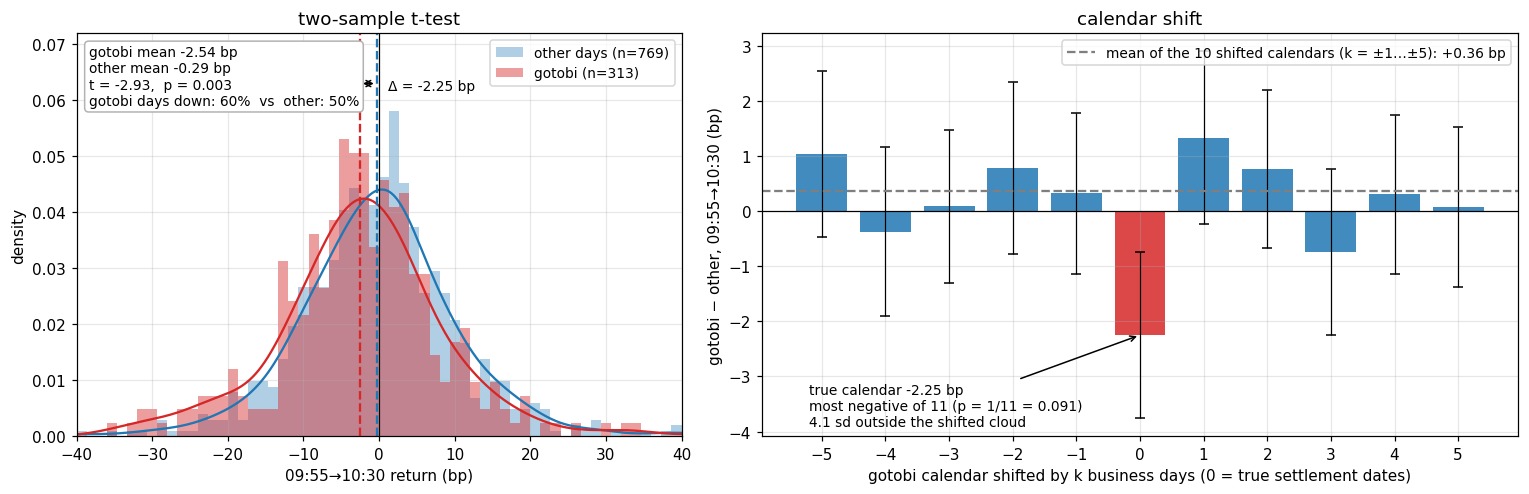

In [9]:
a, b = y[gg], y[~gg]; wt = stats.ttest_ind(a, b, equal_var=False)
SH["se"] = [np.sqrt(y[m].var() / m.sum() + y[~m].var() / (~m).sum()) for m in
            [np.isin(np.arange(len(px)), bd[G].values + k) for k in SH.index]]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})
bins = np.linspace(-40, 40, 61)
ax[0].hist(b, bins=bins, density=True, color="C0", alpha=.35, label=f"other days (n={len(b)})"); ax[0].hist(a, bins=bins, density=True, color="C3", alpha=.45, label=f"gotobi (n={len(a)})")
xs = np.linspace(-40, 40, 400); ax[0].plot(xs, stats.gaussian_kde(b)(xs), color="C0", lw=1.5); ax[0].plot(xs, stats.gaussian_kde(a)(xs), color="C3", lw=1.5)
ax[0].axvline(b.mean(), color="C0", ls="--", lw=1.5); ax[0].axvline(a.mean(), color="C3", ls="--", lw=1.5); ax[0].axvline(0, color="k", lw=.8)
ax[0].set_ylim(0, .072); ax[0].annotate("", xy=(a.mean(), .063), xytext=(b.mean(), .063), arrowprops=dict(arrowstyle="<->", color="k")); ax[0].text(b.mean() + 1.5, .0625, f"Δ = {obs:+.2f} bp", ha="left", va="center", fontsize=9)
ax[0].text(.02, .97, f"gotobi mean {a.mean():+.2f} bp\nother mean {b.mean():+.2f} bp\nt = {wt.statistic:.2f},  p = {wt.pvalue:.3f}\ngotobi days down: {(a < 0).mean():.0%}  vs  other: {(b < 0).mean():.0%}", transform=ax[0].transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", fc="w", ec="0.7"))
ax[0].set_xlim(-40, 40); ax[0].set_xlabel("09:55→10:30 return (bp)"); ax[0].set_ylabel("density"); ax[0].set_title("two-sample t-test"); ax[0].legend(loc="upper right", fontsize=9)
ax[1].bar(SH.index, SH["diff"], color=["C3" if k == 0 else "C0" for k in SH.index], alpha=.85); ax[1].errorbar(SH.index, SH["diff"], yerr=1.96 * SH.se, fmt="none", color="k", capsize=3, lw=.8)
ax[1].axhline(0, color="k", lw=.8); ax[1].axhline(SH.drop(0)["diff"].mean(), color="C7", ls="--", label=f"mean of the 10 shifted calendars (k = ±1…±5): {SH.drop(0)['diff'].mean():+.2f} bp")
ax[1].annotate(f"true calendar {SH.loc[0, 'diff']:+.2f} bp\nmost negative of 11 (p = 1/11 = {1 / 11:.3f})\n{abs(SH.loc[0, 'diff'] - SH.drop(0)['diff'].mean()) / SH.drop(0)['diff'].std():.1f} sd outside the shifted cloud", (0, SH.loc[0, "diff"]), xytext=(-5.2, -3.9), fontsize=9, arrowprops=dict(arrowstyle="->"))
ax[1].set_xticks(SH.index); ax[1].set_xlabel("gotobi calendar shifted by k business days (0 = true settlement dates)"); ax[1].set_ylabel("gotobi − other, 09:55→10:30 (bp)")
ax[1].set_title("calendar shift"); ax[1].legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* the two distributions sit almost on top of each other — daily noise (σ ≈ 11 bp) dwarfs
the effect — but the gotobi mean is shifted 2.25 bp to the left, 60 % of gotobi days are down after the fix versus 50 %
of other days, and with n = 313 vs 769 that shift is 2.9 standard errors (p = 0.003). *Right:* the true calendar is the
only one of 11 below zero by any margin and the only one whose 95 % CI excludes it; the 10 shifted calendars scatter
between −0.8 and +1.3 bp around a mean of +0.4, and the ±1-day shifts — calendars that share the same weeks, weekdays and
month position and differ only in whether settlement is *today* — show nothing (+1.3 and +0.3 bp). The rank test alone
gives p = 1/11 ≈ 0.09 (its floor with ten placebos), so the magnitude proof is the t-test; the true calendar sits 4 sd
outside the shifted cloud, and what the shift adds is that the drop is pinned
to the settlement dates themselves, which is what bank pre-hedging of customer flow predicts and a generic time-of-day
story does not.

**What this does.** Was 10:30 cherry-picked? For every exit minute from 09:56 to 11:00, rerun both tests above on the
09:55→exit return. *Left:* the two-sample t-statistic by exit. *Middle:* the gotobi-minus-other gap by exit for the true
calendar (red) and for each of the 10 shifted calendars (grey) — the shift test as a fan. *Right:* how far the true
calendar sits outside the shifted cloud at each exit (z = (true − mean of shifted) ÷ sd of shifted) and its rank among
the 11. If the drop is real and pinned to the settlement dates, the red line should leave the grey fan immediately and
stay outside it, and the rank should stay at 1.

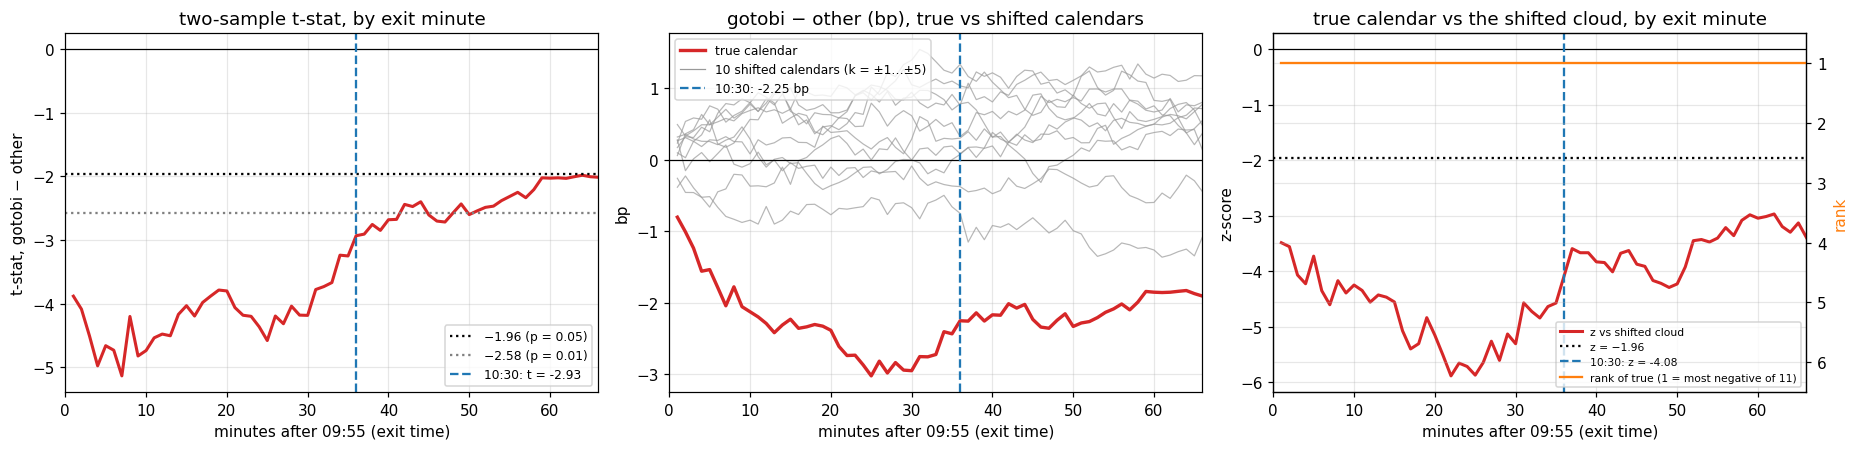

t < −1.96 for every exit to 11:00;  true calendar ranks 1 of 11 for 66 of 66 exits (worst rank 1 at 09:55);  z < −1.96 vs shifted cloud for exits to 11:00
most negative: t = -5.14 at 10:01;  largest bp gap -3.02 at 10:19;  shifted calendars' most negative value at any exit: -1.36 bp


In [10]:
ks = np.arange(1, 180 - FIX + 1)
R = np.column_stack([bp(FIX, FIX + k).values for k in ks])                                   # days × exits
masks = {k: np.isin(np.arange(len(px)), bd[G].values + k) for k in range(-5, 6)}           # shifted gotobi calendars
DIF = pd.DataFrame({k: R[m].mean(0) - R[~m].mean(0) for k, m in masks.items()}, index=ks)   # exits × shifts
true, fake = DIF[0], DIF.drop(columns=0)
EX = pd.DataFrame({"t": [stats.ttest_ind(R[gg, j], R[~gg, j], equal_var=False).statistic for j in range(len(ks))],
                   "z_shift": (true - fake.mean(1)) / fake.std(1), "rank": (DIF.le(true, axis=0)).sum(1)}, index=ks)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].plot(EX.index, EX.t, color="C3", lw=2); ax[0].axhline(0, color="k", lw=.8); ax[0].axhline(-1.96, color="k", ls=":", label="−1.96 (p = 0.05)"); ax[0].axhline(-2.58, color="0.5", ls=":", label="−2.58 (p = 0.01)")
ax[0].axvline(150 - FIX, color="C0", ls="--", label=f"10:30: t = {EX.t[150 - FIX]:.2f}"); ax[0].set_title("two-sample t-stat, by exit minute"); ax[0].set_ylabel("t-stat, gotobi − other"); ax[0].legend(fontsize=8, loc="lower right")
for k in fake.columns: ax[1].plot(ks, fake[k], color="0.6", lw=.8, alpha=.7)
ax[1].plot(ks, true, color="C3", lw=2.2, label="true calendar"); ax[1].plot([], [], color="0.6", lw=.8, label="10 shifted calendars (k = ±1…±5)")
ax[1].axhline(0, color="k", lw=.8); ax[1].axvline(150 - FIX, color="C0", ls="--", label=f"10:30: {true[150 - FIX]:+.2f} bp"); ax[1].set_title("gotobi − other (bp), true vs shifted calendars"); ax[1].set_ylabel("bp"); ax[1].legend(fontsize=8, loc="upper left")
ax[2].plot(EX.index, EX.z_shift, color="C3", lw=2, label="z vs shifted cloud"); ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(-1.96, color="k", ls=":", label="z = −1.96"); ax[2].axvline(150 - FIX, color="C0", ls="--", label=f"10:30: z = {EX.z_shift[150 - FIX]:.2f}")
ax2 = ax[2].twinx(); ax2.step(EX.index, EX["rank"], color="C1", lw=1.5, where="mid", label="rank of true (1 = most negative of 11)"); ax2.set_ylim(0.5, 6.5); ax2.set_yticks(range(1, 7)); ax2.set_ylabel("rank", color="C1"); ax2.invert_yaxis()
ax[2].set_title("true calendar vs the shifted cloud, by exit minute"); ax[2].set_ylabel("z-score"); h1, l1 = ax[2].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax[2].legend(h1 + h2, l1 + l2, fontsize=7, loc="lower right", bbox_to_anchor=(1, 0.0))
for a_ in ax: a_.set_xlim(0, ks[-1]); a_.set_xticks(range(0, ks[-1] + 1, 10)); a_.set_xlabel("minutes after 09:55 (exit time)")
plt.tight_layout(); plt.show()
print(f"t < −1.96 for every exit to {lab(FIX + EX.t[EX.t < -1.96].index.max())};  true calendar ranks 1 of 11 for {(EX['rank'] == 1).sum()} of {len(ks)} exits (worst rank {EX['rank'].max()} at {lab(FIX + EX['rank'].idxmax())});  z < −1.96 vs shifted cloud for exits to {lab(FIX + EX.z_shift[EX.z_shift < -1.96].index.max())}")
print(f"most negative: t = {EX.t.min():.2f} at {lab(FIX + EX.t.idxmin())};  largest bp gap {true.min():+.2f} at {lab(FIX + true.idxmin())};  shifted calendars' most negative value at any exit: {fake.min().min():+.2f} bp")

**Interpretation.** *Left:* the t-statistic is below −3.8 from the first minute, bottoms near −5 around 10:00, stays
under −4 until about 10:20 and then decays to −2.9 at 10:30 and toward −2 by 11:00 — the bp gap keeps building to ~10:20
but later minutes add variance faster than effect. *Middle:* the true calendar (red) leaves the grey fan of shifted
calendars within the first minute and never re-enters it; the shifted calendars wander around zero (their most negative
value at any exit is −1.4 bp, while the true one is −2 to −3 bp for the whole hour). *Right:* the true calendar is
well outside the shifted cloud at every exit and ranks 1 of 11 at all 66 exits. So 10:30 was not fitted: any exit from 10:00 to 11:00 gives the same answer on both tests, 10:30 sits on the
decaying tail of the t-curve and is the conservative choice, and a 10:00–10:20 exit captures the same move with less noise.

## 5b. The climb before the fix: the same tests, run backwards
**What this does.** The mirror image of the exit sweep. For every *entry* minute from 08:00 to 09:54, take the
entry→09:55 return and run the same tests on it: the two-sample t-test (gotobi vs other days), a one-sample t-test
(is the gotobi climb different from zero at all — a weaker claim, but the one a long trade actually needs), and the
calendar shift (true calendar vs the 10 shifted ones, k = ±1…±5). If the pre-fix leg were the symmetric twin of the post-fix drop,
the red lines should leave the grey fan early and the t-curves should sit below −2 / above +2 for most entries.

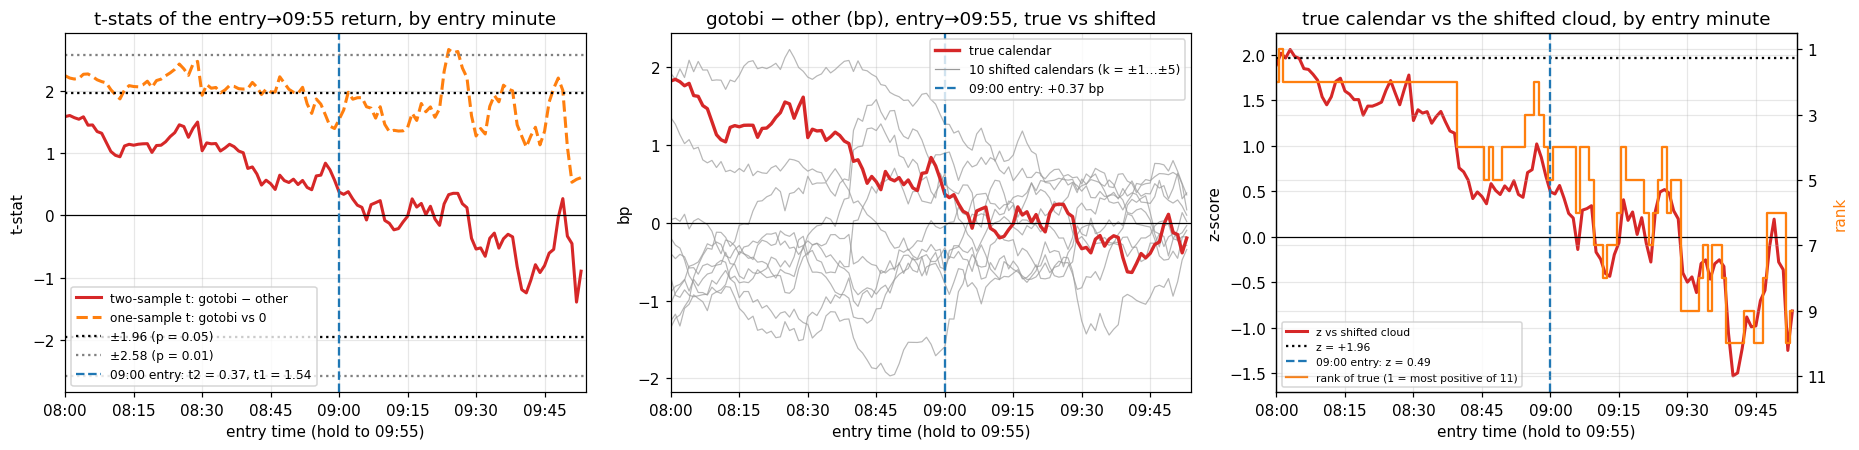

two-sample t > 1.96 at 0 of 114 entries (entries —–—);  one-sample t > 1.96 at 61 entries
best two-sample t = 1.60 at 08:01 (gotobi +2.14 vs other +0.29 bp);  best one-sample t = 2.66 at 09:24
true calendar rank 1 of 11 at 1 of 114 entries; median rank 4;  z > 1.96 at 4 entries
  08:00→09:55: gotobi +2.17  other +0.34  diff +1.83  t2 1.59  t1 2.24  z_shift 1.89  rank 2
  08:30→09:55: gotobi +1.71  other +0.61  diff +1.10  t2 1.04  t1 1.93  z_shift 1.28  rank 2
  09:00→09:55: gotobi +1.28  other +0.91  diff +0.37  t2 0.37  t1 1.54  z_shift 0.49  rank 5
  09:30→09:55: gotobi +0.64  other +0.97  diff -0.33  t2 -0.54  t1 1.27  z_shift -0.50  rank 9
  09:45→09:55: gotobi +0.55  other +0.94  diff -0.39  t2 -0.81  t1 1.35  z_shift -0.98  rank 10


In [11]:
ms = np.arange(0, FIX)                                                                     # entry minutes 08:00 … 09:53
Rp = np.column_stack([bp(m, FIX).values for m in ms])                                       # days × entries, entry→09:55
DIFp = pd.DataFrame({k: Rp[m_].mean(0) - Rp[~m_].mean(0) for k, m_ in masks.items()}, index=ms)
truep, fakep = DIFp[0], DIFp.drop(columns=0)
EN = pd.DataFrame({"t2": [stats.ttest_ind(Rp[gg, j], Rp[~gg, j], equal_var=False).statistic for j in range(len(ms))],
                   "t1": [stats.ttest_1samp(Rp[gg, j], 0).statistic for j in range(len(ms))],
                   "g_mean": Rp[gg].mean(0), "o_mean": Rp[~gg].mean(0),
                   "z_shift": (truep - fakep.mean(1)) / fakep.std(1), "rank": (DIFp.ge(truep, axis=0)).sum(1)}, index=ms)
tk = range(0, FIX + 1, 15)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].plot(ms, EN.t2, color="C3", lw=2, label="two-sample t: gotobi − other"); ax[0].plot(ms, EN.t1, color="C1", lw=2, ls="--", label="one-sample t: gotobi vs 0")
ax[0].axhline(0, color="k", lw=.8); ax[0].axhline(1.96, color="k", ls=":", label="±1.96 (p = 0.05)"); ax[0].axhline(-1.96, color="k", ls=":"); ax[0].axhline(2.58, color="0.5", ls=":", label="±2.58 (p = 0.01)"); ax[0].axhline(-2.58, color="0.5", ls=":")
ax[0].axvline(60, color="C0", ls="--", label=f"09:00 entry: t2 = {EN.t2[60]:.2f}, t1 = {EN.t1[60]:.2f}"); ax[0].set_title("t-stats of the entry→09:55 return, by entry minute"); ax[0].set_ylabel("t-stat"); ax[0].legend(fontsize=8, loc="lower left")
for k in fakep.columns: ax[1].plot(ms, fakep[k], color="0.6", lw=.8, alpha=.7)
ax[1].plot(ms, truep, color="C3", lw=2.2, label="true calendar"); ax[1].plot([], [], color="0.6", lw=.8, label="10 shifted calendars (k = ±1…±5)"); ax[1].axhline(0, color="k", lw=.8)
ax[1].axvline(60, color="C0", ls="--", label=f"09:00 entry: {truep[60]:+.2f} bp"); ax[1].set_title("gotobi − other (bp), entry→09:55, true vs shifted"); ax[1].set_ylabel("bp"); ax[1].legend(fontsize=8, loc="upper right")
ax[2].plot(ms, EN.z_shift, color="C3", lw=2, label="z vs shifted cloud"); ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(1.96, color="k", ls=":", label="z = +1.96"); ax[2].axvline(60, color="C0", ls="--", label=f"09:00 entry: z = {EN.z_shift[60]:.2f}")
ax2 = ax[2].twinx(); ax2.step(ms, EN["rank"], color="C1", lw=1.5, where="mid", label="rank of true (1 = most positive of 11)"); ax2.set_ylim(0.5, 11.5); ax2.set_yticks([1, 3, 5, 7, 9, 11]); ax2.set_ylabel("rank", color="C1"); ax2.invert_yaxis()
ax[2].set_title("true calendar vs the shifted cloud, by entry minute"); ax[2].set_ylabel("z-score"); h1, l1 = ax[2].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax[2].legend(h1 + h2, l1 + l2, fontsize=7, loc="lower left")
for a_ in ax: a_.set_xlim(0, FIX); a_.set_xticks(list(tk)); a_.set_xticklabels([lab(m) for m in tk]); a_.set_xlabel("entry time (hold to 09:55)")
plt.tight_layout(); plt.show()
print(f"two-sample t > 1.96 at {(EN.t2 > 1.96).sum()} of {len(ms)} entries (entries {lab(EN.t2[EN.t2 > 1.96].index.min()) if (EN.t2 > 1.96).any() else '—'}–{lab(EN.t2[EN.t2 > 1.96].index.max()) if (EN.t2 > 1.96).any() else '—'});  one-sample t > 1.96 at {(EN.t1 > 1.96).sum()} entries")
print(f"best two-sample t = {EN.t2.max():.2f} at {lab(EN.t2.idxmax())} (gotobi {EN.g_mean[EN.t2.idxmax()]:+.2f} vs other {EN.o_mean[EN.t2.idxmax()]:+.2f} bp);  best one-sample t = {EN.t1.max():.2f} at {lab(EN.t1.idxmax())}")
print(f"true calendar rank 1 of 11 at {(EN['rank'] == 1).sum()} of {len(ms)} entries; median rank {EN['rank'].median():.0f};  z > 1.96 at {(EN.z_shift > 1.96).sum()} entries")
for m in [0, 30, 60, 90, 105]: print(f"  {lab(m)}→09:55: gotobi {EN.g_mean[m]:+.2f}  other {EN.o_mean[m]:+.2f}  diff {truep[m]:+.2f}  t2 {EN.t2[m]:.2f}  t1 {EN.t1[m]:.2f}  z_shift {EN.z_shift[m]:.2f}  rank {EN['rank'][m]}")

**Interpretation — the climb is not the drop's twin.** *Left:* the two-sample t (gotobi − other) never reaches 1.96 at
any entry; it peaks at 1.6 for an 08:00 entry and falls through zero by 09:10. The one-sample t (gotobi vs zero) does clear
2 for entries before ~09:00 — USD/JPY *does* tend to rise into the fix on gotobi days (+2.2 bp from 08:00, t = 2.2) — but
other days rise too (+0.3 bp), so the gotobi-specific part is small and noisy. *Middle:* the true calendar (red) sits at
the top of the grey fan for early entries but inside it, not outside; two shifted calendars climb just as much.
*Right:* the true calendar is the most positive of the 11 at just 1 of 114 entries, median rank 4, z above 1.96 at only 4 entries (all 08:00–08:05). **Reading:** the
pre-fix climb is a weak one-sample effect that is not pinned to the settlement dates and does not survive the
gotobi-vs-other test at any entry and only scrapes the calendar-shift test at the very earliest entries. That is consistent with the front half of the anomaly having been
competed away (and with section 4: only the 25th/month-end still show a pre-fix drift). The tradeable, defensible leg is
the post-fix drop; the climb can be mentioned but should not be sold.

**What this does.** The same two pictures as for the drop, for the full pre-fix window 08:00→09:55 (the session open —
chosen because it is where the data starts, not because it scores best). Left: the two distributions and their means.
Right: the calendar-shift bars.

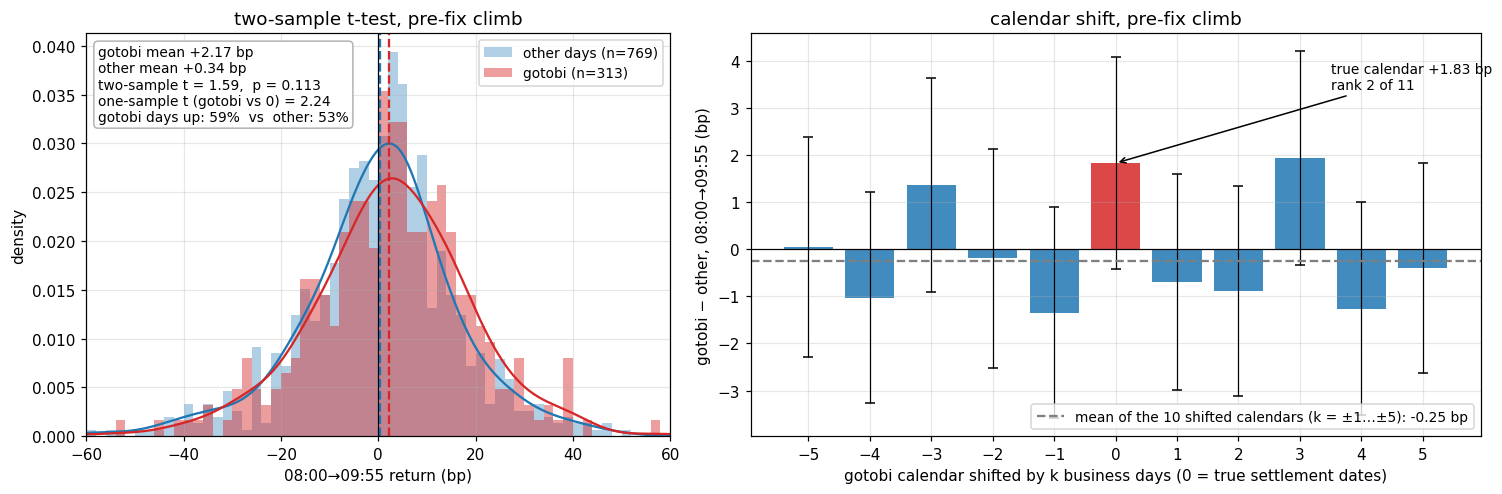

In [12]:
yp = bp(0, FIX); ap, bpp = yp[gg], yp[~gg]; wtp = stats.ttest_ind(ap, bpp, equal_var=False); obsp = ap.mean() - bpp.mean()
SHp = pd.DataFrame({k: dict(diff=yp[m_].mean() - yp[~m_].mean(), se=np.sqrt(yp[m_].var() / m_.sum() + yp[~m_].var() / (~m_).sum())) for k, m_ in masks.items()}).T
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})
bins = np.linspace(-60, 60, 61)
ax[0].hist(bpp, bins=bins, density=True, color="C0", alpha=.35, label=f"other days (n={len(bpp)})"); ax[0].hist(ap, bins=bins, density=True, color="C3", alpha=.45, label=f"gotobi (n={len(ap)})")
xs = np.linspace(-60, 60, 400); ax[0].plot(xs, stats.gaussian_kde(bpp)(xs), color="C0", lw=1.5); ax[0].plot(xs, stats.gaussian_kde(ap)(xs), color="C3", lw=1.5)
ax[0].axvline(bpp.mean(), color="C0", ls="--", lw=1.5); ax[0].axvline(ap.mean(), color="C3", ls="--", lw=1.5); ax[0].axvline(0, color="k", lw=.8)
ax[0].text(.02, .97, f"gotobi mean {ap.mean():+.2f} bp\nother mean {bpp.mean():+.2f} bp\ntwo-sample t = {wtp.statistic:.2f},  p = {wtp.pvalue:.3f}\none-sample t (gotobi vs 0) = {stats.ttest_1samp(ap, 0).statistic:.2f}\ngotobi days up: {(ap > 0).mean():.0%}  vs  other: {(bpp > 0).mean():.0%}", transform=ax[0].transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round", fc="w", ec="0.7"))
ax[0].set_xlim(-60, 60); ax[0].set_xlabel("08:00→09:55 return (bp)"); ax[0].set_ylabel("density"); ax[0].set_title("two-sample t-test, pre-fix climb"); ax[0].legend(loc="upper right", fontsize=9)
ax[1].bar(SHp.index, SHp["diff"], color=["C3" if k == 0 else "C0" for k in SHp.index], alpha=.85); ax[1].errorbar(SHp.index, SHp["diff"], yerr=1.96 * SHp.se, fmt="none", color="k", capsize=3, lw=.8)
ax[1].axhline(0, color="k", lw=.8); ax[1].axhline(SHp.drop(0)["diff"].mean(), color="C7", ls="--", label=f"mean of the 10 shifted calendars (k = ±1…±5): {SHp.drop(0)['diff'].mean():+.2f} bp")
ax[1].annotate(f"true calendar {SHp.loc[0, 'diff']:+.2f} bp\nrank {int((SHp['diff'] >= SHp.loc[0, 'diff']).sum())} of 11", (0, SHp.loc[0, "diff"]), xytext=(3.5, 3.4), fontsize=9, arrowprops=dict(arrowstyle="->"))
ax[1].set_xticks(SHp.index); ax[1].set_xlabel("gotobi calendar shifted by k business days (0 = true settlement dates)"); ax[1].set_ylabel("gotobi − other, 08:00→09:55 (bp)")
ax[1].set_title("calendar shift, pre-fix climb"); ax[1].legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** *Left:* over 08:00→09:55 the gotobi distribution is shifted right (+2.2 vs +0.3 bp, 59 % of days up
vs 53 %), but the pre-fix window is nearly two hours long and its noise is correspondingly larger (σ ≈ 15 bp), so the gap
is only 1.6 standard errors (p = 0.11). Against zero the gotobi climb is significant (one-sample t = 2.2), which is the
weaker statement: "USD/JPY tends to rise into the fix on gotobi days", not "more than on other days". *Right:* the true
calendar ranks 2nd of 11 and its 95 % CI touches zero; one shifted calendar climbs nearly as much. Compare with the
post-fix picture above, where the true calendar was alone at the bottom with nothing near it. **Reading:** the pre-fix
climb is real but small, not gotobi-specific, and would not survive the tests the drop passes — which is what you expect
from a leg that has been front-run for a decade.

## 5c. Does morning volatility predict the post-fix drop?
**What this does.** Morning vol = realised volatility of 1-minute returns from 08:00 to 09:55 (std of the 114 one-minute
log returns, in bp/min). Post-fix move = the 09:55→10:15 return (bar-close, no execution lag — this is about the
anomaly, not the trade). Three views: a scatter of the two with fitted lines for gotobi and other days; the mean post-fix
return, its Sharpe-like ratio (mean ÷ std) and the hit rate by morning-vol quintile; and a regression of the post-fix
return on morning vol, the gotobi dummy and their interaction. The question is whether a noisy morning means banks have
more to hedge (bigger drop), or just more noise (bigger |move|, same mean).

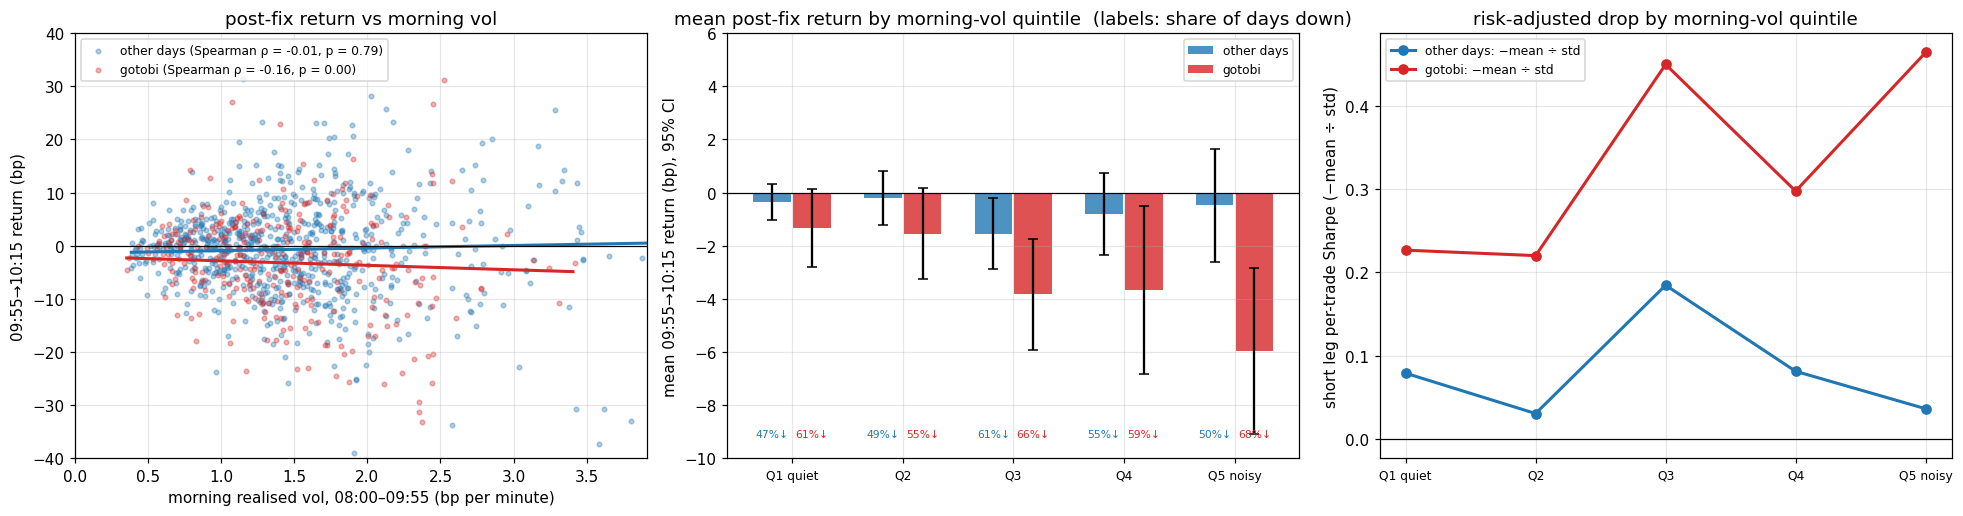

                 mean    std    n  down    se  ratio
q        gotobi                                     
Q1 quiet False  -0.34   4.33  156  0.47  0.35  -0.08
         True   -1.33   5.88   61  0.61  0.75  -0.23
Q2       False  -0.19   6.38  151  0.49  0.52  -0.03
         True   -1.55   7.04   65  0.55  0.87  -0.22
Q3       False  -1.54   8.36  152  0.61  0.68  -0.18
         True   -3.83   8.51   64  0.66  1.06  -0.45
Q4       False  -0.81   9.98  158  0.55  0.79  -0.08
         True   -3.66  12.30   58  0.59  1.61  -0.30
Q5 noisy False  -0.48  13.31  152  0.50  1.08  -0.04
         True   -5.96  12.84   65  0.68  1.59  -0.46

09:55→10:15 return on standardised morning vol, gotobi dummy, interaction (HC3):
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.6787      0.324     -2.096      0.036      -1.313      -0.044
mvol_z            0.4864      0.652 

In [13]:
mv = r1.loc[:, 1:FIX].std(axis=1); post = bp(FIX, FIX + 21); post30 = bp(FIX, 150)
D5 = pd.DataFrame({"mvol": mv, "post": post, "post30": post30, "gotobi": G, "year": years})
D5["q"] = pd.qcut(D5.mvol, 5, labels=["Q1 quiet", "Q2", "Q3", "Q4", "Q5 noisy"])
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
for m_, c, l in [(~G, "C0", "other days"), (G, "C3", "gotobi")]:
    d = D5[m_]; ax[0].scatter(d.mvol, d.post, s=9, alpha=.35, color=c, label=f"{l} (Spearman ρ = {stats.spearmanr(d.mvol, d.post).statistic:+.2f}, p = {stats.spearmanr(d.mvol, d.post).pvalue:.2f})")
    b = np.polyfit(d.mvol, d.post, 1); xs = np.linspace(d.mvol.min(), d.mvol.quantile(.99), 50); ax[0].plot(xs, np.polyval(b, xs), color=c, lw=2)
ax[0].axhline(0, color="k", lw=.8); ax[0].set_xlim(0, D5.mvol.quantile(.99)); ax[0].set_ylim(-40, 40); ax[0].set_xlabel("morning realised vol, 08:00–09:55 (bp per minute)"); ax[0].set_ylabel("09:55→10:15 return (bp)"); ax[0].set_title("post-fix return vs morning vol"); ax[0].legend(fontsize=8, loc="upper left")
Q = D5.groupby(["q", "gotobi"], observed=True).post.agg(["mean", "std", "count", lambda s: (s < 0).mean()]); Q.columns = ["mean", "std", "n", "down"]; Q["se"] = Q["std"] / np.sqrt(Q.n); Q["ratio"] = Q["mean"] / Q["std"]
xq = np.arange(5)
for gflag, c, l, off in [(False, "C0", "other days", -.18), (True, "C3", "gotobi", .18)]:
    q = Q.xs(gflag, level="gotobi"); ax[1].bar(xq + off, q["mean"], .34, yerr=1.96 * q.se, capsize=3, color=c, alpha=.8, label=l)
    for x_, (m_, d_) in zip(xq + off, zip(q["mean"], q.down)): ax[1].text(x_, -9.2, f"{d_:.0%}↓", ha="center", fontsize=7, color=c)
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xticks(xq); ax[1].set_xticklabels(Q.index.levels[0], fontsize=8); ax[1].set_ylim(-10, 6); ax[1].set_ylabel("mean 09:55→10:15 return (bp), 95% CI"); ax[1].set_title("mean post-fix return by morning-vol quintile  (labels: share of days down)"); ax[1].legend(fontsize=8)
for gflag, c, l in [(False, "C0", "other days"), (True, "C3", "gotobi")]:
    q = Q.xs(gflag, level="gotobi"); ax[2].plot(xq, -q.ratio, "o-", color=c, lw=2, label=f"{l}: −mean ÷ std")
ax[2].axhline(0, color="k", lw=.8); ax[2].set_xticks(xq); ax[2].set_xticklabels(Q.index.levels[0], fontsize=8); ax[2].set_ylabel("short leg per-trade Sharpe (−mean ÷ std)"); ax[2].set_title("risk-adjusted drop by morning-vol quintile"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(Q.round(2).to_string()); print()
D5["mvol_z"] = (D5.mvol - D5.mvol.mean()) / D5.mvol.std()
X5 = sm.add_constant(pd.DataFrame({"mvol_z": D5.mvol_z, "gotobi": D5.gotobi.astype(float), "mvol_x_gotobi": D5.mvol_z * D5.gotobi}))
m5 = sm.OLS(D5.post, X5).fit(cov_type="HC3"); print("09:55→10:15 return on standardised morning vol, gotobi dummy, interaction (HC3):"); print(m5.summary().tables[1])
m5a = sm.OLS(D5.post.abs(), X5).fit(cov_type="HC3"); print(f"\nsame regression on |09:55→10:15|:  mvol_z β = {m5a.params.mvol_z:+.2f} (t {m5a.tvalues.mvol_z:.1f}),  gotobi β = {m5a.params.gotobi:+.2f} (t {m5a.tvalues.gotobi:.1f}),  interaction β = {m5a.params.mvol_x_gotobi:+.2f} (t {m5a.tvalues.mvol_x_gotobi:.1f})")
g = D5[G]; hi, lo = g[g.mvol > g.mvol.median()], g[g.mvol <= g.mvol.median()]
print(f"\ngotobi days, noisy-morning half vs quiet-morning half:  mean {hi.post.mean():+.2f} vs {lo.post.mean():+.2f} bp (Welch p {stats.ttest_ind(hi.post, lo.post, equal_var=False).pvalue:.3f});  std {hi.post.std():.1f} vs {lo.post.std():.1f};  −mean/std {-hi.post.mean() / hi.post.std():.3f} vs {-lo.post.mean() / lo.post.std():.3f};  down {(hi.post < 0).mean():.0%} vs {(lo.post < 0).mean():.0%}")
print(f"morning vol on gotobi vs other days: {mv[G].mean():.2f} vs {mv[~G].mean():.2f} bp/min (MW p = {stats.mannwhitneyu(mv[G], mv[~G]).pvalue:.3f})")

**Interpretation.**
- **Yes, on gotobi days a noisier morning means a bigger drop — and only on gotobi days.** Spearman ρ between morning
  vol and the 09:55→10:15 return is −0.16 (p = 0.004) on gotobi days and −0.01 (p = 0.8) on other days. By quintile the
  gotobi mean goes −1.3, −1.6, −3.8, −3.7, **−6.0 bp** from quietest to noisiest morning; other days sit at −0.2 to −1.5
  with no pattern. Splitting gotobi days at the median morning vol: −4.6 bp on noisy mornings vs −2.0 on quiet ones
  (Welch p = 0.017).
- **The effect is in the mean, not just the noise.** Volatility scales everything, so the fair question is whether the
  *risk-adjusted* drop improves. It does: the short leg's per-trade Sharpe (−mean ÷ std) rises from ≈ 0.22 in Q1–Q2 to
  ≈ 0.45 in Q3 and Q5 (right panel); on other days it never leaves 0.03–0.18. The hit rate also edges up (61 % → 68 %).
  A noisy morning is not merely a bigger coin — it is a more loaded one.
- **The regression is the weak point.** With a single linear term the interaction (vol × gotobi) is −1.3 bp per sd of
  morning vol but only t = −0.6, because the relationship is a step (Q1–Q2 vs Q3–Q5), not a line, and the top quintile
  is fat-tailed. The quintile and median-split views are the honest ones; treat the linear coefficient as unproven.
- **Mechanism check.** Gotobi and other days have the same morning vol (1.50 vs 1.53 bp/min, p = 0.97), so this is not
  "gotobi days are noisier". A noisy Tokyo morning on a settlement day is consistent with larger or more one-sided
  customer flow being pre-hedged, which leaves more to unwind after 09:55.
- **Tradeable implication.** Morning vol is known by 09:54, so it is a legitimate conditioning variable. Skipping the
  quietest 40 % of gotobi mornings, or sizing up on the noisiest 20 %, would have roughly doubled the per-trade Sharpe on
  the days traded. It is one parameter and it is a priori — a good candidate for the vol-scaling step suggested in
  section 6, but it should be walked forward before it is believed.

## 6. Is it tradeable?
**What this does.** The rule: on gotobi days, **short USD/JPY at 09:55, cover at 10:30**. Reported net of a round-trip
cost (0.5 bp is conservative for interbank USD/JPY; the table also shows 0.3–2.0 bp), with the same rule on non-gotobi
days as a placebo, plus the surviving *pre*-fix leg (long 09:00→09:55 on the 25th and month-end only).

short 09:55→10:30, gotobi days, net 0.5 bp     n= 313  mean= +2.04 bp  hit=58.1%  t= 3.15  Sharpe≈ 1.52
   placebo: same rule on non-gotobi days       n= 769  mean= -0.21 bp  hit=48.0%  t=-0.50  Sharpe≈-0.24
long 09:00→09:55, 25th & month-end only        n= 103  mean= +2.99 bp  hit=63.1%  t= 1.99  Sharpe≈ 0.96

cost sensitivity of the short leg:
   cost 0.3 bp: mean +2.24 bp  t 3.46  Sharpe≈1.67  worst trade -44 bp  worst 20-trade run -59 bp  80% of years positive
   cost 0.5 bp: mean +2.04 bp  t 3.15  Sharpe≈1.52  worst trade -44 bp  worst 20-trade run -63 bp  80% of years positive
   cost 1.0 bp: mean +1.54 bp  t 2.38  Sharpe≈1.15  worst trade -45 bp  worst 20-trade run -73 bp  80% of years positive
   cost 1.5 bp: mean +1.04 bp  t 1.61  Sharpe≈0.78  worst trade -45 bp  worst 20-trade run -83 bp  80% of years positive
   cost 2.0 bp: mean +0.54 bp  t 0.84  Sharpe≈0.40  worst trade -46 bp  worst 20-trade run -93 bp  60% of years positive


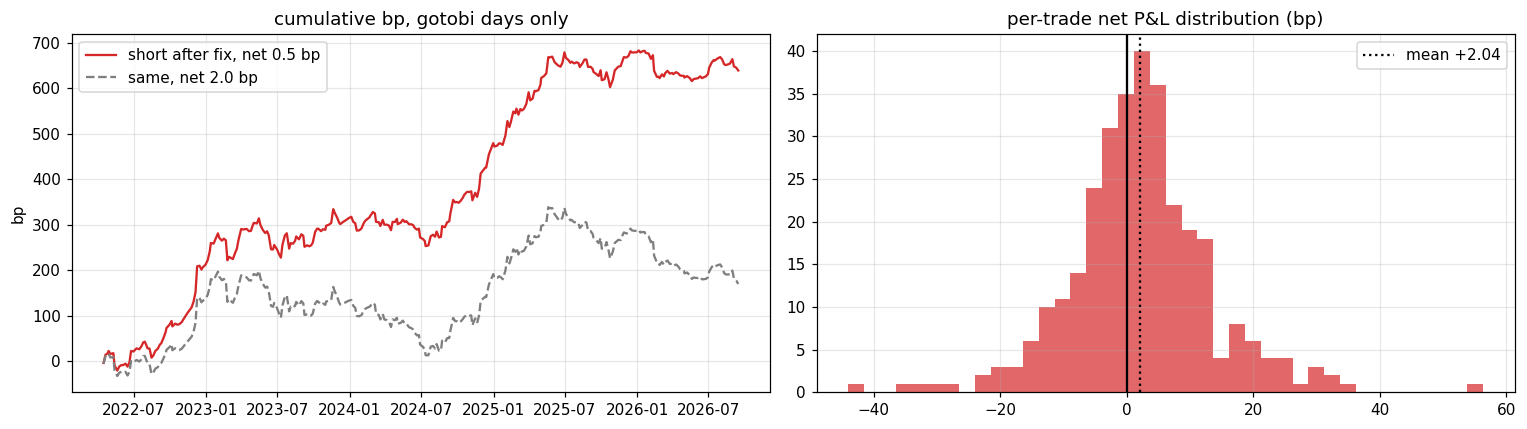

In [14]:
def rep(r, label):
    n = len(r); print(f"{label:46s} n={n:4d}  mean={r.mean():+6.2f} bp  hit={(r > 0).mean():5.1%}  t={r.mean() / r.std() * np.sqrt(n):5.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * n / len(D)):5.2f}")
    return r
short_g = rep(-D.loc[G, "09:55→10:30"] - COST, "short 09:55→10:30, gotobi days, net 0.5 bp")
rep(-D.loc[~G, "09:55→10:30"] - COST, "   placebo: same rule on non-gotobi days")
long_25 = rep(D.loc[G & K.isin(["25", "eom"]), "09:00→09:55"] - COST, "long 09:00→09:55, 25th & month-end only")
print("\ncost sensitivity of the short leg:")
r0 = -D.loc[G, "09:55→10:30"]
for c in [0.3, 0.5, 1.0, 1.5, 2.0]:
    r = r0 - c; print(f"   cost {c:.1f} bp: mean {r.mean():+.2f} bp  t {r.mean() / r.std() * np.sqrt(len(r)):.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * len(r) / len(D)):.2f}  worst trade {r.min():.0f} bp  worst 20-trade run {r.rolling(20).sum().min():+.0f} bp  {(r.groupby(years[gg]).sum() > 0).mean():.0%} of years positive")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(short_g.cumsum(), label="short after fix, net 0.5 bp", color="C3"); ax[0].plot((r0 - 2.0).cumsum(), label="same, net 2.0 bp", color="C7", ls="--"); ax[0].legend(); ax[0].set_title("cumulative bp, gotobi days only"); ax[0].set_ylabel("bp")
ax[1].hist(short_g, bins=40, color="C3", alpha=.7); ax[1].axvline(0, color="k"); ax[1].axvline(short_g.mean(), color="k", ls=":", label=f"mean {short_g.mean():+.2f}"); ax[1].legend(); ax[1].set_title("per-trade net P&L distribution (bp)")
plt.tight_layout(); plt.show()

**Interpretation.** Short USD/JPY 09:55→10:30 on gotobi days: **+2.0 bp per trade net of 0.5 bp, 58 % hit rate, t = 3.2,
Sharpe ≈ 1.5** on ~70 trades a year. The identical rule on non-gotobi days loses 0.2 bp (placebo passes). It survives a
1 bp cost (t = 2.4) but not 2 bp — so it is an interbank-cost edge, not a retail one. The 25th/month-end pre-fix long
adds +3.0 bp per trade (t = 2.0) on ~24 days a year. The distribution is fat-tailed (worst trade −44 bp on a BoJ-type
day; a −60 bp 20-trade run is in the history), so position sizing matters more than the mean suggests.

**What this does.** Optimisation of the round trip around the 09:55 pivot over two parameters: **long entry between
08:00 and 08:50** (5-minute steps, long held to 09:55) and **short exit between 10:00 and 10:45** (5-minute steps, short
opened at 09:55). At 09:55 the long is closed and the short opened in one execution, so the round trip is three fills.
**Execution assumptions:** every fill lands **one minute after** its signal minute (you do not get the fix print itself),
and total transaction cost is **1 bp per day** across the three fills. Objective: annualised Sharpe of the daily net P&L,
**in-sample = 2022-04 to 2024-12** (2025 onward held out), computed the standard way — mean ÷ std of the daily series × √252. Three
versions of the same grid: the rule on **gotobi days only** (flat otherwise), the identical rule on **non-gotobi days
only** (the placebo), and on **every day** with no calendar filter. Marked: the 08:00→09:55→10:30 round trip used above.

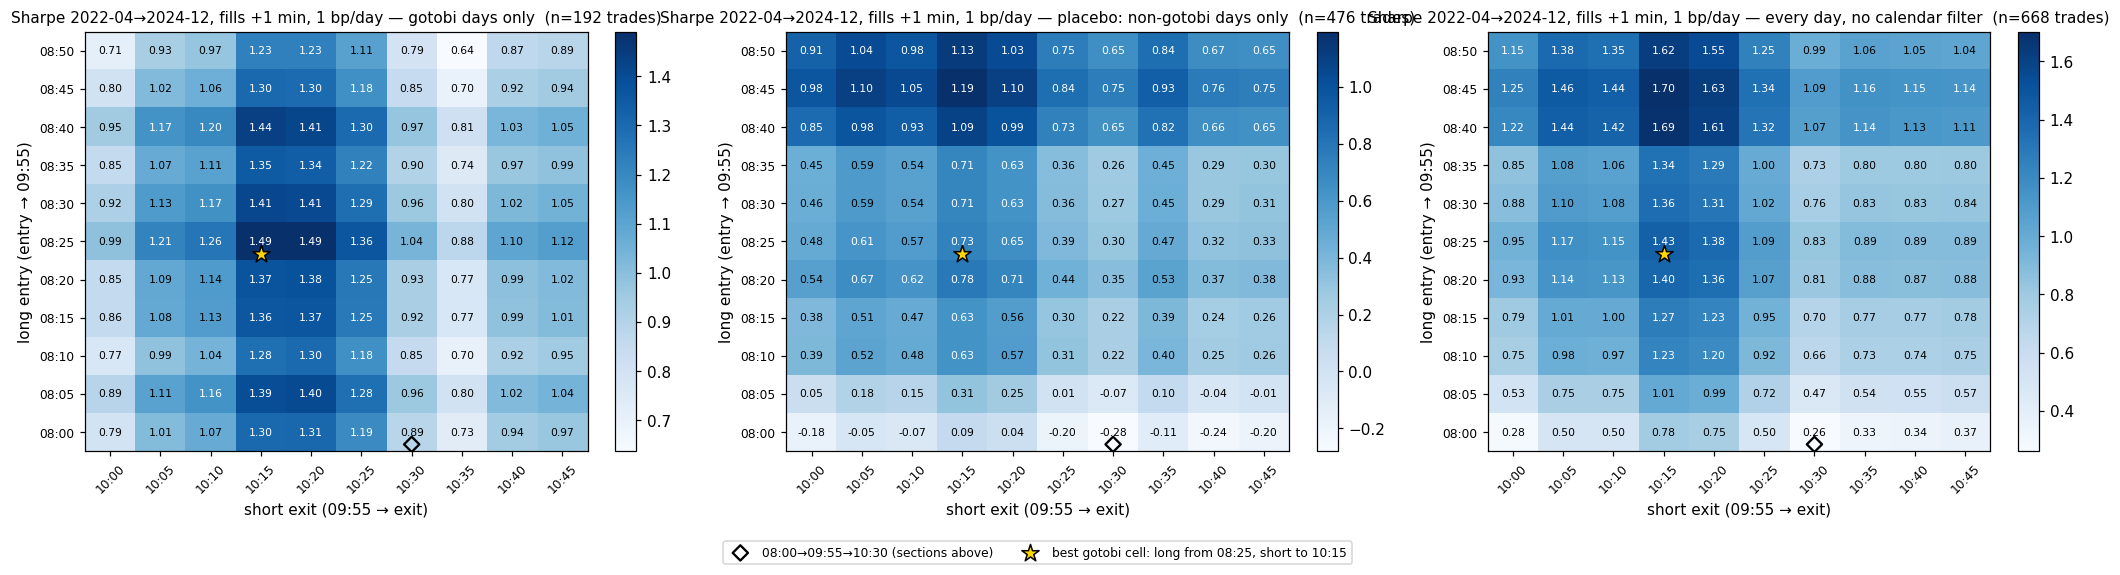

gotobi only      best gotobi cell (08:25→09:55→10:15): Sharpe  1.49, mean +3.13 bp/trade   |   baseline (08:00→09:55→10:30): Sharpe  0.89, mean +2.15 bp/trade   |   grid range 0.64 – 1.49
non-gotobi only  best gotobi cell (08:25→09:55→10:15): Sharpe  0.73, mean +0.94 bp/trade   |   baseline (08:00→09:55→10:30): Sharpe -0.28, mean -0.41 bp/trade   |   grid range -0.28 – 1.19
every day        best gotobi cell (08:25→09:55→10:15): Sharpe  1.43, mean +1.57 bp/trade   |   baseline (08:00→09:55→10:30): Sharpe  0.26, mean +0.33 bp/trade   |   grid range 0.26 – 1.70

gotobi grid: cells within 0.25 of best: 27 of 110;  best exit per entry: 08:00→10:20, 08:05→10:20, 08:10→10:20, 08:15→10:20, 08:20→10:20, 08:25→10:15, 08:30→10:15, 08:35→10:15, 08:40→10:15, 08:45→10:15, 08:50→10:20
non-gotobi grid: cells with Sharpe > 0: 99 of 110;  cells with Sharpe > 1: 8


In [15]:
ents = np.arange(0, 51, 5)                                # long entry minute index: 0 = 08:00 … 50 = 08:50
exts = np.arange(6, 52, 5)                                # short exit: 10:00 … 10:45 (minute index 120 = 10:00)
SPLIT = pd.Timestamp('2025-01-01'); INS = np.asarray(px.index < SPLIT)
LAG, TC_DAY = 1, 1.0                                      # fills 1 minute late; 1 bp total cost per day (3 fills)
Lall = np.column_stack([bp(e + LAG, FIX + LAG).values for e in ents])[INS]            # long leg, filled 1 min late at both ends
Sall = np.column_stack([-bp(FIX + LAG, FIX + x + LAG).values for x in exts])[INS]     # short leg, filled 1 min late at both ends
P = Lall[:, :, None] + Sall[:, None, :] - TC_DAY                          # days × entries × exits, net P&L if traded
def sharpe(mask):                                                          # daily series over ALL in-sample days, 0 when not traded
    D_ = np.where(mask[INS][:, None, None], P, 0.0)
    return pd.DataFrame(D_.mean(0) / D_.std(0, ddof=1) * np.sqrt(252), index=ents, columns=exts), pd.DataFrame(P[mask[INS]].mean(0), index=ents, columns=exts)
SR_g, M_g = sharpe(gg); SR_o, M_o = sharpe(~gg); SR_a, M_a = sharpe(np.ones(len(gg), bool))
base = (0, 150 - FIX); bi = np.unravel_index(np.nanargmax(SR_g.values), SR_g.shape); best = (ents[bi[0]], exts[bi[1]])
fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
from matplotlib.colors import TwoSlopeNorm, Normalize
for a_, Gd, Md, ttl in [(ax[0], SR_g, M_g, f"gotobi days only  (n={(gg & INS).sum()} trades)"), (ax[1], SR_o, M_o, f"placebo: non-gotobi days only  (n={(~gg & INS).sum()} trades)"), (ax[2], SR_a, M_a, f"every day, no calendar filter  (n={INS.sum()} trades)")]:
    lo, hi = Gd.values.min(), Gd.values.max(); norm = Normalize(lo, hi)   # each panel stretched over its own range
    im = a_.imshow(Gd.values, aspect="auto", origin="lower", cmap="Blues", norm=norm, extent=[exts[0] - 2.5, exts[-1] + 2.5, ents[0] - 2.5, ents[-1] + 2.5]); plt.colorbar(im, ax=a_, fraction=.04)
    for r, e_ in enumerate(ents):
        for cidx, x_ in enumerate(exts): a_.text(x_, e_, f"{Gd.values[r, cidx]:.2f}", ha="center", va="center", fontsize=7, color="w" if norm(Gd.values[r, cidx]) > 0.6 else "k")
    a_.scatter(base[1], base[0] - 1.6, marker="D", s=50, facecolor="none", edgecolor="k", lw=1.5, label="08:00→09:55→10:30 (sections above)")
    a_.scatter(best[1], best[0] - 1.6, marker="*", s=140, color="gold", edgecolor="k", label=f"best gotobi cell: long from {lab(best[0])}, short to {lab(FIX + best[1])}")
    a_.set_xticks(exts); a_.set_xticklabels([lab(FIX + v) for v in exts], fontsize=8, rotation=45); a_.set_yticks(ents); a_.set_yticklabels([lab(v) for v in ents], fontsize=8)
    a_.set_title(f"Sharpe 2022-04→2024-12, fills +1 min, 1 bp/day — {ttl}", fontsize=10); a_.set_xlabel("short exit (09:55 → exit)"); a_.set_ylabel("long entry (entry → 09:55)"); a_.grid(False)
ax[1].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2); plt.tight_layout(); plt.show()
for lbl, SRx, Mx in [("gotobi only", SR_g, M_g), ("non-gotobi only", SR_o, M_o), ("every day", SR_a, M_a)]:
    print(f"{lbl:16s} best gotobi cell ({lab(best[0])}→09:55→{lab(FIX + best[1])}): Sharpe {SRx.loc[best]:5.2f}, mean {Mx.loc[best]:+5.2f} bp/trade   |   baseline (08:00→09:55→10:30): Sharpe {SRx.loc[base]:5.2f}, mean {Mx.loc[base]:+5.2f} bp/trade   |   grid range {SRx.values.min():.2f} – {SRx.values.max():.2f}")
print(f"\ngotobi grid: cells within 0.25 of best: {(SR_g >= SR_g.values.max() - .25).sum().sum()} of {SR_g.size};  best exit per entry: " + ", ".join(f"{lab(e)}→{lab(FIX + SR_g.loc[e].idxmax())}" for e in ents))
print(f"non-gotobi grid: cells with Sharpe > 0: {(SR_o > 0).sum().sum()} of {SR_o.size};  cells with Sharpe > 1: {(SR_o > 1).sum().sum()}")

**Interpretation.** (Standard Sharpe on the daily series × √252; in-sample 2022–2024, 192 gotobi trades; fills one
minute late; 1 bp/day cost.)
- **Gotobi only (left): best cell long 08:25 → flip 09:55 → cover 10:15, Sharpe 1.49, +3.1 bp/day.** The
  08:00→09:55→10:30 round trip is 0.89 / +2.2 bp. Every cell positive (worst 0.64); 27 of 110 cells within 0.25 of the
  best, so it is a plateau.
- **Exit carries the structure:** 10:15–10:20 is the best exit in every row (10:15 for 08:25–08:45, 10:20 elsewhere —
  same thing at 5-minute resolution); Sharpe drops below 1 by 10:35. **Entry is flat:** 1.2–1.4 down the 10:15 column
  for every entry, 1.49 at the 08:25 stripe (08:20: 1.3, 08:30: 1.3). Choose the entry on execution grounds.
- **Placebo (middle) is weak but not zero this time:** best 1.19, 8 cells above 1, at the same 10:15–10:20 exits. Over
  2022–2024 the post-fix drift was mildly present on non-gotobi days too (the early-morning climb in section 3). The
  gotobi grid is still ~0.3–0.8 Sharpe better cell for cell, and the placebo's mean is +0.9 bp vs +3.1.
- **Every-day (right)** peaks at 1.70 — comparable Sharpe to gotobi-only but on +1.6 bp/trade, 3.5× the trades and cost,
  and it is what the placebo's residual drift buys you. It says the fix pattern is general; the calendar concentrates it.
- The real test is the next cell: the same rule run forward from January 2025 with nothing re-fitted.

**What this does.** Takes the best in-sample cell (long 08:25 → flip 09:55 → cover 10:20, fills one minute late, 1 bp/day)
and runs it through every trading day: in-sample to end-2024, then **2025 onward out of sample** with the parameters frozen.
Cumulative P&L in bp of notional (flat on non-gotobi days), with the in-sample / out-of-sample boundary marked, plus
Sharpe, hit rate and unlevered return per year.

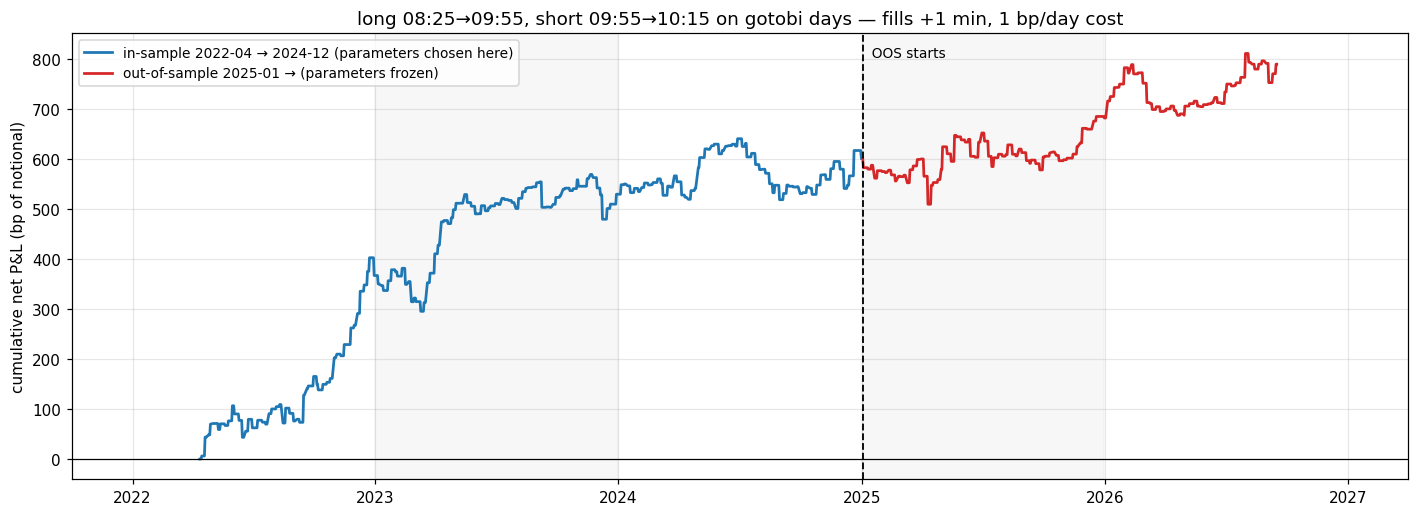

in-sample 2022–2024          days  668  trades 192  Sharpe  1.49  mean/trade +3.13 bp  hit  60%  total  +601.7 bp = +6.02%  max drawdown -122 bp
out-of-sample 2025 onward    days  414  trades 121  Sharpe  0.78  mean/trade +1.56 bp  hit  55%  total  +188.5 bp = +1.88%  max drawdown -102 bp
all                          days 1082  trades 313  Sharpe  1.23  mean/trade +2.52 bp  hit  58%  total  +790.2 bp = +7.90%  max drawdown -131 bp

by year (unlevered, bp of notional; 2026 partial):
   2022                      days  175  trades  50  Sharpe  3.00  mean/trade +7.34 bp  hit  68%  total  +367.2 bp = +3.67%  max drawdown -63 bp
   2023                      days  246  trades  71  Sharpe  1.12  mean/trade +2.29 bp  hit  61%  total  +162.7 bp = +1.63%  max drawdown -90 bp
   2024                      days  247  trades  71  Sharpe  0.54  mean/trade +1.01 bp  hit  55%  total   +71.8 bp = +0.72%  max drawdown -122 bp
   2025                      days  241  trades  70  Sharpe  0.55  mean/trade +1.

In [16]:
e_, x_ = best
daily = pd.Series(0.0, index=px.index); daily[gg] = (bp(e_ + LAG, FIX + LAG) - bp(FIX + LAG, FIX + x_ + LAG) - TC_DAY)[gg]
oos_start = px.index[px.index >= SPLIT][0]; is_m, oos_m = daily.index < oos_start, daily.index >= oos_start
cum = daily.cumsum()
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(cum.index[is_m], cum[is_m], color="C0", lw=1.8, label="in-sample 2022-04 → 2024-12 (parameters chosen here)")
ax.plot(cum.index[oos_m], cum[oos_m], color="C3", lw=1.8, label="out-of-sample 2025-01 → (parameters frozen)")
ax.axvline(oos_start, color="k", ls="--", lw=1.2); ax.text(oos_start, ax.get_ylim()[1] * .97 if ax.get_ylim()[1] > 0 else 0, "  OOS starts", va="top", fontsize=9)
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("cumulative net P&L (bp of notional)"); ax.set_title(f"long {lab(e_)}→09:55, short 09:55→{lab(FIX + x_)} on gotobi days — fills +1 min, 1 bp/day cost")
for y in sorted(set(years)): ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31), color="0.5" if y % 2 else "1.0", alpha=.06)
ax.legend(loc="upper left", fontsize=9); plt.tight_layout(); plt.show()
def stats_(d, lbl):
    tr = d[d != 0]; sh = d.mean() / d.std() * np.sqrt(252)
    print(f"{lbl:28s} days {len(d):4d}  trades {len(tr):3d}  Sharpe {sh:5.2f}  mean/trade {tr.mean():+5.2f} bp  hit {(tr > 0).mean():4.0%}  total {d.sum():+7.1f} bp = {d.sum() / 100:+.2f}%  max drawdown {(d.cumsum() - d.cumsum().cummax()).min():+.0f} bp")
stats_(daily[is_m], "in-sample 2022–2024"); stats_(daily[oos_m], "out-of-sample 2025 onward"); stats_(daily, "all")
print("\nby year (unlevered, bp of notional; 2026 partial):")
for y, d in daily.groupby(years): stats_(d, f"   {y}")
yr = daily.groupby(years).sum() / 100; frac = (daily.index[-1] - daily.index[0]).days / 365.25
print(f"\ncumulative return {daily.sum() / 100:+.2f}% over {frac:.1f} years → {daily.sum() / 100 / frac:+.2f}% per year unlevered (annual vol {daily.std() * np.sqrt(252) / 100:.2f}%)")

**Interpretation.**
- **Out of sample: positive, about half the in-sample Sharpe.** Parameters frozen at end-2024; 2025-01 → 2026-09 gives
  121 trades, Sharpe 0.78, +1.6 bp/trade, 55 % hit rate, +1.9 % unlevered, −102 bp max drawdown. In-sample was 1.49 /
  +3.1 bp / 60 %. The red segment is flat for the first ~9 months of 2025 and then earns everything in late 2025–2026;
  it ends at its high.
- **Year by year:** 2022 Sharpe 3.0 (+3.7 %), 2023 1.1, 2024 0.5, 2025 0.6, 2026 1.2 (partial). Every calendar year is
  positive. 2022 — the BoJ-intervention year — contributes almost half of the 4.4-year P&L; the post-2022 run rate is
  ≈ +1.0–1.6 % a year.
- **Totals:** +7.9 % cumulative over 4.4 years = +1.8 % a year unlevered at 1.5 % annual vol; Sharpe 1.23 across the
  whole sample, 0.78 out of sample. At 10× leverage that is ≈ 18 % / 15 % vol / ~13 % worst drawdown — a strategy, but a
  visible one at the 09:55 fix.
- **Reading.** A calendar-specific edge that survives realistic fills and cost, was positive in every year and out of
  sample, and has roughly halved in size since 2022. Pitch the out-of-sample number (Sharpe ≈ 0.8, ≈ +1.5 bp per gotobi
  day), not the in-sample one, and pitch it as an overlay for a desk already active at the Tokyo fix.

**What this does.** The same P&L chart for the **short leg alone** — sell USD/JPY at 09:55, cover at 10:15, gotobi days
only, fills one minute late, two fills so ⅔ of the 1 bp/day cost (0.67 bp). No long leg. The round trip from the cell
above is drawn faintly for comparison. Same split: in-sample 2022–2024, out-of-sample 2025 onward.

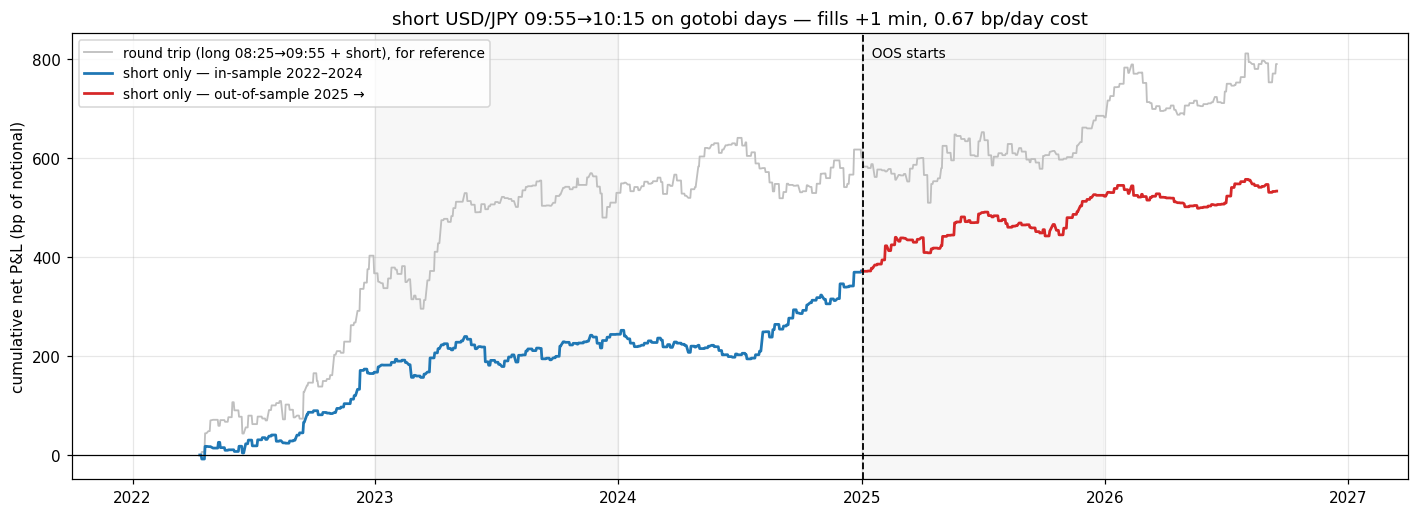

short only, in-sample 2022–24 days  668  trades 192  Sharpe  1.71  mean/trade +1.94 bp  hit  60%  total  +372.0 bp = +3.72%  max drawdown -61 bp
short only, OOS 2025 onward  days  414  trades 121  Sharpe  1.37  mean/trade +1.33 bp  hit  58%  total  +161.5 bp = +1.61%  max drawdown -48 bp
short only, all              days 1082  trades 313  Sharpe  1.59  mean/trade +1.70 bp  hit  59%  total  +533.4 bp = +5.33%  max drawdown -61 bp

by year:
   2022                      days  175  trades  50  Sharpe  2.82  mean/trade +3.35 bp  hit  66%  total  +167.3 bp = +1.67%  max drawdown -22 bp
   2023                      days  246  trades  71  Sharpe  0.99  mean/trade +1.08 bp  hit  59%  total   +76.7 bp = +0.77%  max drawdown -61 bp
   2024                      days  247  trades  71  Sharpe  1.60  mean/trade +1.80 bp  hit  56%  total  +127.9 bp = +1.28%  max drawdown -58 bp
   2025                      days  241  trades  70  Sharpe  1.96  mean/trade +2.16 bp  hit  63%  total  +151.0 bp = +1.51%  m

In [17]:
tc_short = TC_DAY * 2 / 3
daily_s = pd.Series(0.0, index=px.index); daily_s[gg] = (-bp(FIX + LAG, FIX + x_ + LAG) - tc_short)[gg]
cum_s = daily_s.cumsum()
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(cum.index, cum, color="0.75", lw=1.2, label=f"round trip (long {lab(e_)}→09:55 + short), for reference")
ax.plot(cum_s.index[is_m], cum_s[is_m], color="C0", lw=1.8, label="short only — in-sample 2022–2024")
ax.plot(cum_s.index[oos_m], cum_s[oos_m], color="C3", lw=1.8, label="short only — out-of-sample 2025 →")
ax.axvline(oos_start, color="k", ls="--", lw=1.2); ax.text(oos_start, ax.get_ylim()[1] * .97, "  OOS starts", va="top", fontsize=9); ax.axhline(0, color="k", lw=.8)
for y in sorted(set(years)): ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31), color="0.5" if y % 2 else "1.0", alpha=.06)
ax.set_ylabel("cumulative net P&L (bp of notional)"); ax.set_title(f"short USD/JPY 09:55→{lab(FIX + x_)} on gotobi days — fills +1 min, {tc_short:.2f} bp/day cost"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()
stats_(daily_s[is_m], "short only, in-sample 2022–24"); stats_(daily_s[oos_m], "short only, OOS 2025 onward"); stats_(daily_s, "short only, all")
print("\nby year:")
for y, d in daily_s.groupby(years): stats_(d, f"   {y}")
print(f"\ncumulative return {daily_s.sum() / 100:+.2f}% over {frac:.1f} years → {daily_s.sum() / 100 / frac:+.2f}% per year unlevered (annual vol {daily_s.std() * np.sqrt(252) / 100:.2f}%)")
print(f"vs round trip: cumulative {daily.sum() / 100:+.2f}%, Sharpe {daily.mean() / daily.std() * np.sqrt(252):.2f};  correlation of daily P&L between the two: {daily[gg].corr(daily_s[gg]):.2f}")

**Interpretation.**
- **Short only is the better risk-adjusted trade.** In-sample Sharpe 1.71 (vs 1.49 for the round trip), **out of
  sample 1.37 (vs 0.78)**, all-sample 1.59 (vs 1.23). It earns less — +1.7 bp/trade, +5.3 % cumulative, +1.2 % a year —
  but at half the vol (0.78 % vs 1.5 %) and half the drawdown (−61 bp vs −131 bp). 20 minutes in the market instead of
  110.
- **It also decays far less.** Round trip: in-sample 1.49 → out-of-sample 0.78. Short only: 1.71 → 1.37. Year by year
  it is 2.8 / 1.0 / 1.6 / 2.0 / 0.3 — the 2024–2025 years that the round trip found hard (0.5 / 0.6) are among the
  short leg's best (1.6 / 2.0). What made the round trip look worse in those years was the long leg.
- **2026 is the weak spot:** +0.2 bp/trade, 51 % hit rate, Sharpe 0.27 on 51 trades so far. Eight and a half months is
  too short to call a regime change (2023 was similar and recovered), but it is the number to watch, and it is
  consistent with section 4's "weakest year" note.
- **The long leg, on this evidence, is a diversifier at best.** The two legs' daily P&L correlate at only 0.44, so the
  round trip does add bp and some diversification — but it lowers Sharpe in both periods and doubles the risk. Section 5b
  already showed the pre-fix climb is not gotobi-specific; this is the same fact in P&L form.
- **Reading.** The cleanest expression of the anomaly is the short alone: sell USD/JPY at the 09:55 fix on gotobi days,
  cover at ~10:15, ≈ +1.5 bp/day after realistic costs, Sharpe ≈ 1.4 out of sample, tiny drawdowns. Lever it if you
  want return; do not add the long leg for Sharpe.

## 6b. Is the long leg alpha, or beta to the trend?
**The objection.** USD/JPY went from 125 to 155 over the sample. A leg that is *long* USD/JPY for 90 minutes on ~70 days
a year could be earning nothing but a slice of that drift — and section 5b already showed the pre-fix climb fails the
gotobi-vs-other test at every entry. The short leg has the opposite exposure and passes its two-sample test, so the
question only bites the long leg. This section tests it four ways.

**What this does.** Each leg on its own, gotobi days only, fills one minute late, half the 1 bp/day cost per leg
(two fills each). Top: cumulative P&L of the long leg (orange), the short leg (red), and the long leg with
β × (that day's close-to-close spot move) subtracted, β fitted on gotobi days. Bottom: USD/JPY spot on the same
time axis, so you can see whether the long leg's curve tracks it. Then Sharpe / hit rate / drawdown for each leg
in-sample, out-of-sample and by year, and how concentrated each leg's P&L is.

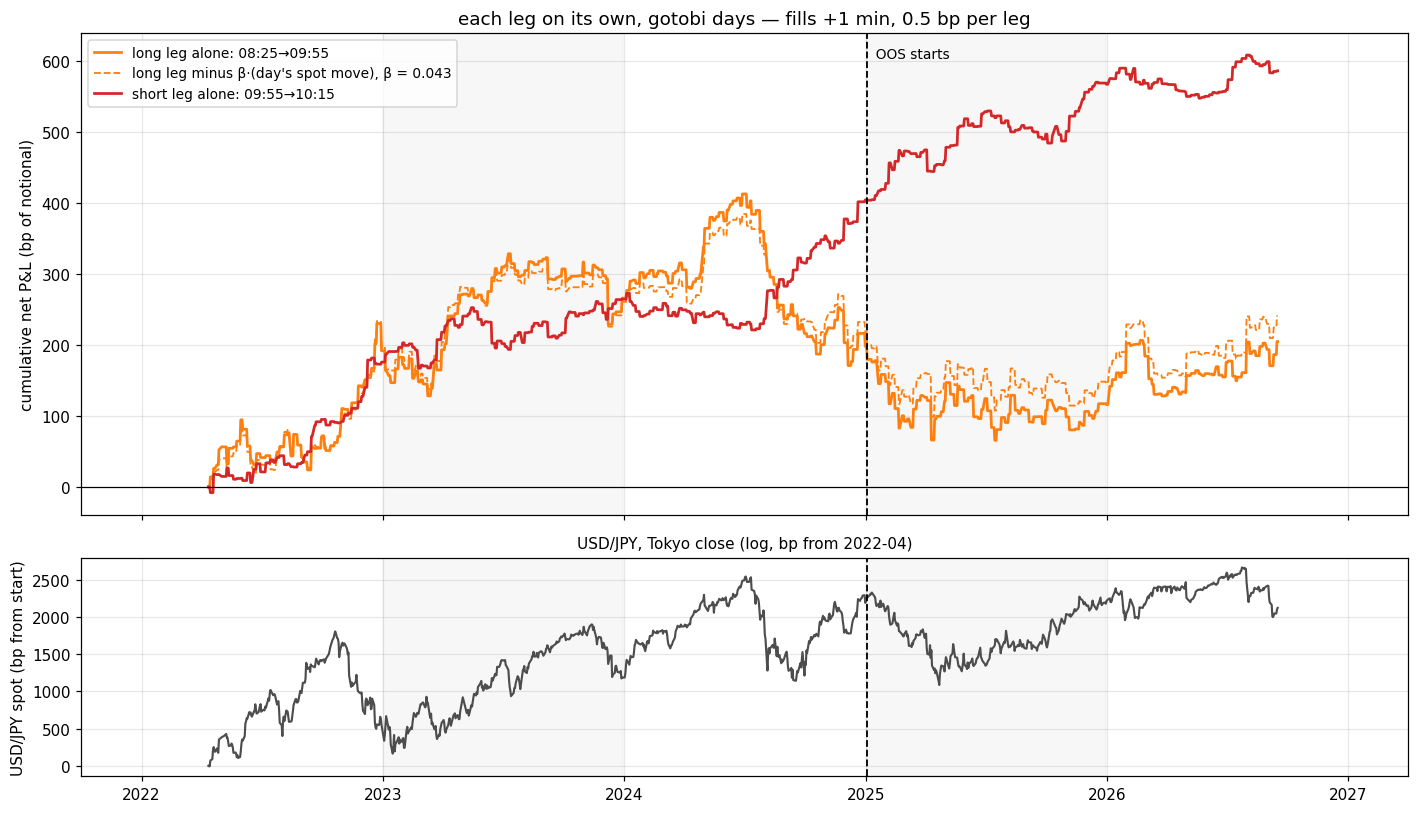

long leg, in-sample 2022–24  days  668  trades 192  Sharpe  0.55  mean/trade +1.03 bp  hit  57%  total  +197.7 bp = +1.98%  max drawdown -241 bp
long leg, OOS 2025 onward    days  414  trades 121  Sharpe  0.03  mean/trade +0.06 bp  hit  50%  total    +6.8 bp = +0.07%  max drawdown -132 bp
long leg, all                days 1082  trades 313  Sharpe  0.35  mean/trade +0.65 bp  hit  55%  total  +204.6 bp = +2.05%  max drawdown -347 bp
   by year (total bp / Sharpe): 2022: +192 / 1.85, 2023: +74 / 0.58, 2024: -68 / -0.52, 2025: -82 / -0.61, 2026: +89 / 1.08
   concentration: 2022 = 94% of total, best 10 days = 178% of total

short leg, in-sample 2022–24 days  668  trades 192  Sharpe  1.85  mean/trade +2.10 bp  hit  60%  total  +404.0 bp = +4.04%  max drawdown -59 bp
short leg, OOS 2025 onward   days  414  trades 121  Sharpe  1.53  mean/trade +1.50 bp  hit  59%  total  +181.6 bp = +1.82%  max drawdown -45 bp
short leg, all               days 1082  trades 313  Sharpe  1.74  mean/trade +1.87 b

In [18]:
LEG_TC = TC_DAY / 2                                                            # two fills per leg → half the 1 bp/day
long_leg = pd.Series(0.0, index=px.index); long_leg[gg] = (bp(e_ + LAG, FIX + LAG) - LEG_TC)[gg]          # long entry→09:55
short_leg = pd.Series(0.0, index=px.index); short_leg[gg] = (-bp(FIX + LAG, FIX + x_ + LAG) - LEG_TC)[gg]  # short 09:55→exit
cc = (lpx[419] - lpx[419].shift(1)) * 1e4                                      # close-to-close spot return (prev 14:59 → today 14:59), bp
beta_L = sm.OLS(long_leg[gg], sm.add_constant(cc[gg]), missing="drop").fit().params.iloc[1]
hedged = pd.Series(0.0, index=px.index); hedged[gg] = (long_leg - beta_L * cc)[gg]                        # long leg minus β × day's spot move
spot_bp = (lpx[419] - lpx[419].iloc[0]) * 1e4
fig, ax = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
ax[0].plot(long_leg.cumsum(), color="C1", lw=1.8, label=f"long leg alone: {lab(e_)}→09:55")
ax[0].plot(hedged.cumsum(), color="C1", lw=1.2, ls="--", label=f"long leg minus β·(day's spot move), β = {beta_L:.3f}")
ax[0].plot(short_leg.cumsum(), color="C3", lw=1.8, label=f"short leg alone: 09:55→{lab(FIX + x_)}")
ax[0].axvline(oos_start, color="k", ls="--", lw=1.2); ax[0].text(oos_start, ax[0].get_ylim()[1] * .97, "  OOS starts", va="top", fontsize=9); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_ylabel("cumulative net P&L (bp of notional)"); ax[0].set_title(f"each leg on its own, gotobi days — fills +1 min, {LEG_TC:.1f} bp per leg"); ax[0].legend(loc="upper left", fontsize=9)
ax[1].plot(spot_bp, color="0.3", lw=1.4); ax[1].axvline(oos_start, color="k", ls="--", lw=1.2)
ax[1].set_ylabel("USD/JPY spot (bp from start)"); ax[1].set_title("USD/JPY, Tokyo close (log, bp from 2022-04)", fontsize=10)
for a_ in ax:
    for y in sorted(set(years)): a_.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31), color="0.5" if y % 2 else "1.0", alpha=.06)
plt.tight_layout(); plt.show()
for nm, d in [("long leg", long_leg), ("short leg", short_leg)]:
    stats_(d[is_m], f"{nm}, in-sample 2022–24"); stats_(d[oos_m], f"{nm}, OOS 2025 onward"); stats_(d, f"{nm}, all")
    print("   by year (total bp / Sharpe): " + ", ".join(f"{y}: {d[years == y].sum():+.0f} / {d[years == y].mean() / d[years == y].std() * np.sqrt(252):.2f}" for y in sorted(set(years))))
    t = d[gg]; print(f"   concentration: 2022 = {t[years[gg] == 2022].sum() / t.sum():.0%} of total, best 10 days = {t.nlargest(10).sum() / t.sum():.0%} of total\n")
print(f"spot: {px[419].iloc[0]:.1f} → {px[419].iloc[-1]:.1f} ({spot_bp.iloc[-1] / 100:+.1f}%), i.e. {cc.mean():+.2f} bp per day, of which a pro-rata 90 minutes is {cc.mean() * 90 / 1440:+.2f} bp.  On gotobi days the spot day is {cc[gg].mean():+.2f} bp on average (the post-fix drop is in it).")

**What this does.** (i) **The regression** $\text{PnL}_t = \alpha + \beta\, r_t + \varepsilon_t$ on gotobi days,
each leg separately, HC3 errors. β is the leg's directional exposure, α is what is left. Five definitions of
$r_t$, because the obvious one (the day's close-to-close move) *contains* the leg's own window and so has a
mechanical β: the day's move **excluding** the leg's window, the Tokyo session, and the trailing 20- and 60-day
spot return (both known at entry, so they are the honest "trend" regressors). (ii) The same regression pooled over
all days with a gotobi dummy and a dummy × $r_t$ interaction — the gotobi-specific α. (iii) **Regime split:** each leg's
mean when the trailing 60-day trend is up vs down. (iv) **Quarterly blocks:** the mean leg P&L in each calendar quarter
against the spot move in that quarter — non-overlapping, so the correlation has a real p-value. (v) **Time placebo:**
the same 89-minute long started at every other minute of the Tokyo session on gotobi days — if the long leg is
riding a drift, every start time should look alike.

PnL_t = α + β·r_t on gotobi days (bp, HC3):
                                 alpha    a_t    a_p   beta    b_t     R2    n
leg   r                                                                       
long  day (close→close)          1.268  1.448  0.148  0.043  2.295  0.035  313
      day ex the leg's window    1.118  1.257  0.209 -0.009 -0.436  0.002  313
      Tokyo session 08:00→15:00  1.445  1.787  0.074  0.171  2.013  0.146  313
      trailing 20-day            0.988  1.025  0.305  0.000  0.021  0.000  306
      trailing 60-day            0.704  0.701  0.483  0.003  1.347  0.008  296
short day (close→close)          2.310  4.599  0.000 -0.023 -1.893  0.030  313
      day ex the leg's window    2.369  4.590  0.000 -0.006 -0.449  0.002  313
      Tokyo session 08:00→15:00  2.216  4.684  0.000 -0.091 -2.310  0.125  313
      trailing 20-day            2.495  4.602  0.000 -0.003 -1.409  0.011  306
      trailing 60-day            2.464  4.424  0.000 -0.001 -0.824  0.002  296

pooled,


89-minute long at every start time, gotobi days: 08:25 start = +1.15 bp (one-sample t 1.29, gotobi−other t 0.69), rank 22 of 330;  starts with one-sample |t| > 1.96: 5 positive, 25 negative


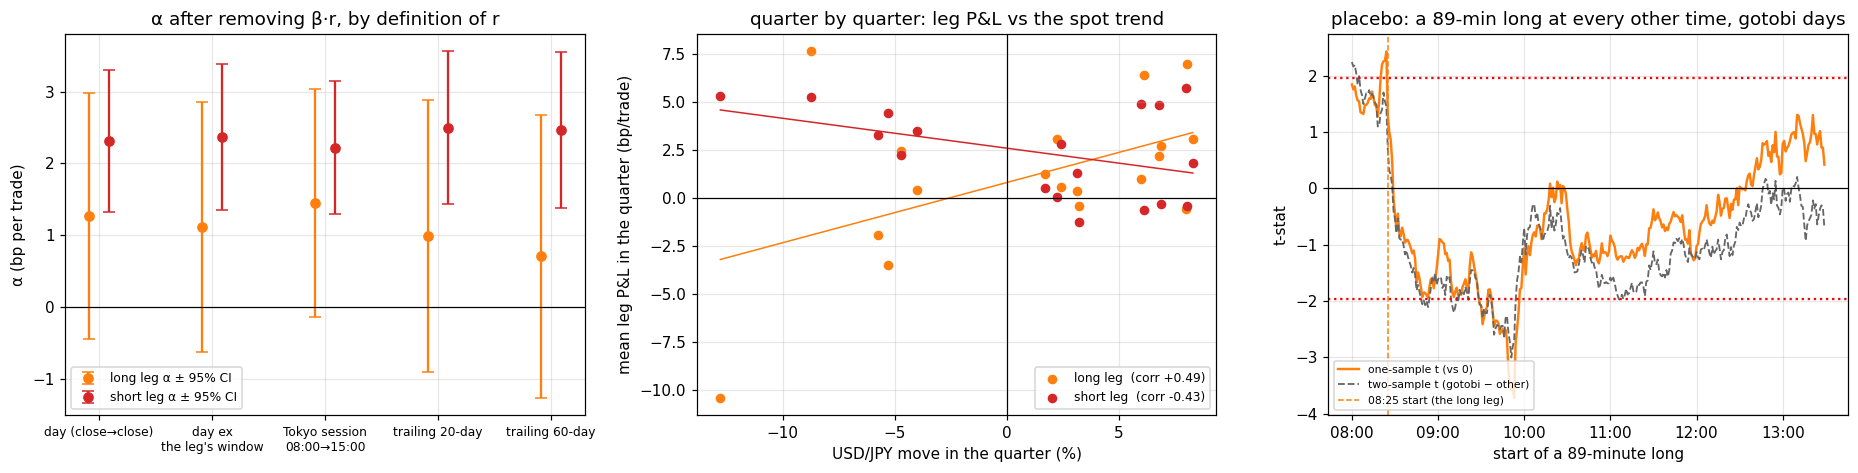

In [19]:
Lg, Sg = long_leg[gg] + LEG_TC, short_leg[gg] + LEG_TC                                   # gross leg P&L, gotobi days
tokyo = bp(0, 419); tr20 = (lpx[419].shift(1) - lpx[419].shift(21)) * 1e4; tr60 = (lpx[419].shift(1) - lpx[419].shift(61)) * 1e4
R = {"day (close→close)": cc, "day ex the leg's window": None, "Tokyo session 08:00→15:00": tokyo, "trailing 20-day": tr20, "trailing 60-day": tr60}
rows = []
for leg, y_, win in [("long", Lg, bp(e_ + LAG, FIX + LAG)), ("short", Sg, bp(FIX + LAG, FIX + x_ + LAG))]:
    for k, r_ in R.items():
        x_r = (cc - win) if r_ is None else r_                                             # remove the leg's own window from the day
        d = pd.concat([y_.rename("y"), x_r[gg].rename("r")], axis=1).dropna(); m = sm.OLS(d.y, sm.add_constant(d.r)).fit(cov_type="HC3")
        rows.append(dict(leg=leg, r=k, alpha=m.params["const"], a_t=m.tvalues["const"], a_p=m.pvalues["const"], beta=m.params["r"], b_t=m.tvalues["r"], R2=m.rsquared, n=len(d)))
AB = pd.DataFrame(rows).set_index(["leg", "r"])
print("PnL_t = α + β·r_t on gotobi days (bp, HC3):"); print(AB.round(3).to_string())
for leg, y_ in [("long", Lg), ("short", Sg)]:
    X = pd.DataFrame({"gotobi": G.astype(float), "r": cc, "r_x_gotobi": cc * G}); yy = (bp(e_ + LAG, FIX + LAG) if leg == "long" else -bp(FIX + LAG, FIX + x_ + LAG))
    m = sm.OLS(yy, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
    print(f"\npooled, all days, {leg}: α_other {m.params['const']:+.2f} (t {m.tvalues['const']:.2f}) | α_gotobi extra {m.params['gotobi']:+.2f} (t {m.tvalues['gotobi']:.2f}, p {m.pvalues['gotobi']:.3f}) | β {m.params['r']:+.3f} (t {m.tvalues['r']:.1f}) | β_gotobi extra {m.params['r_x_gotobi']:+.3f} (t {m.tvalues['r_x_gotobi']:.2f})")
up, dn = (tr60 > 0).values, (tr60 < 0).values
print("\nregime split by the trailing 60-day spot trend (known at entry):")
for leg, y_ in [("long", Lg), ("short", Sg)]:
    a, b = y_[up[gg]], y_[dn[gg]]
    print(f"  {leg}: uptrend {a.mean():+.2f} bp (t {stats.ttest_1samp(a, 0).statistic:.2f}, n {len(a)}) | downtrend {b.mean():+.2f} bp (t {stats.ttest_1samp(b, 0).statistic:.2f}, n {len(b)}) | difference Welch t {stats.ttest_ind(a, b, equal_var=False).statistic:+.2f}")
q = px.index.to_period("Q"); Qd = pd.DataFrame({"long": Lg.groupby(q[gg]).mean(), "short": Sg.groupby(q[gg]).mean(), "spot": (lpx[419].groupby(q).last() - lpx[419].groupby(q).first()) * 1e4, "n": G.groupby(q).sum()}).dropna(); Qd = Qd[Qd.n >= 8]
print(f"\nnon-overlapping quarters (n = {len(Qd)}): corr(long-leg mean, spot move) = {Qd.long.corr(Qd.spot):+.2f} (p {stats.pearsonr(Qd.long, Qd.spot).pvalue:.3f});  corr(short-leg mean, spot move) = {Qd.short.corr(Qd.spot):+.2f} (p {stats.pearsonr(Qd.short, Qd.spot).pvalue:.3f})")
print(f"  long leg in spot-up quarters {Qd.long[Qd.spot > 0].mean():+.2f} bp ({(Qd.spot > 0).sum()} q) vs spot-down {Qd.long[Qd.spot < 0].mean():+.2f} bp ({(Qd.spot < 0).sum()} q);  short leg {Qd.short[Qd.spot > 0].mean():+.2f} vs {Qd.short[Qd.spot < 0].mean():+.2f}")
HOLD = FIX - e_; st = np.arange(0, 420 - HOLD - LAG); PLB = []                             # same-length long at every start minute
for s0 in st:
    w = bp(s0 + LAG, s0 + HOLD + LAG); PLB.append(dict(start=s0, mean=w[gg].mean(), t1=stats.ttest_1samp(w[gg], 0).statistic, t2=stats.ttest_ind(w[gg], w[~gg], equal_var=False).statistic))
PLB = pd.DataFrame(PLB).set_index("start")
print(f"\n{HOLD}-minute long at every start time, gotobi days: {lab(e_)} start = {PLB.loc[e_, 'mean']:+.2f} bp (one-sample t {PLB.loc[e_, 't1']:.2f}, gotobi−other t {PLB.loc[e_, 't2']:.2f}), rank {(PLB['mean'] >= PLB.loc[e_, 'mean']).sum()} of {len(PLB)};  starts with one-sample |t| > 1.96: {(PLB.t1 > 1.96).sum()} positive, {(PLB.t1 < -1.96).sum()} negative")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ab = AB.reset_index(); xs = np.arange(len(R))
for i, (leg, c) in enumerate([("long", "C1"), ("short", "C3")]):
    s = ab[ab.leg == leg]; se = s.alpha / s.a_t
    ax[0].errorbar(xs + (i - .5) * .18, s.alpha, yerr=1.96 * se, fmt="o", color=c, capsize=4, label=f"{leg} leg α ± 95% CI")
ax[0].axhline(0, color="k", lw=.8); ax[0].set_xticks(xs); ax[0].set_xticklabels([k.replace(" the leg's", "\nthe leg's").replace("session ", "session\n") for k in R], fontsize=8); ax[0].set_ylabel("α (bp per trade)"); ax[0].set_title("α after removing β·r, by definition of r"); ax[0].legend(fontsize=8)
for leg, c in [("long", "C1"), ("short", "C3")]:
    ax[1].scatter(Qd.spot / 100, Qd[leg], color=c, s=28, label=f"{leg} leg  (corr {Qd[leg].corr(Qd.spot):+.2f})"); b_, a_ = np.polyfit(Qd.spot / 100, Qd[leg], 1); xx = np.linspace(Qd.spot.min() / 100, Qd.spot.max() / 100, 2); ax[1].plot(xx, a_ + b_ * xx, color=c, lw=1)
ax[1].axhline(0, color="k", lw=.8); ax[1].axvline(0, color="k", lw=.8); ax[1].set_xlabel("USD/JPY move in the quarter (%)"); ax[1].set_ylabel("mean leg P&L in the quarter (bp/trade)"); ax[1].set_title("quarter by quarter: leg P&L vs the spot trend"); ax[1].legend(fontsize=8)
ax[2].plot(PLB.index, PLB.t1, color="C1", lw=1.6, label="one-sample t (vs 0)"); ax[2].plot(PLB.index, PLB.t2, color="0.4", lw=1.2, ls="--", label="two-sample t (gotobi − other)")
ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(1.96, color="r", ls=":"); ax[2].axhline(-1.96, color="r", ls=":"); ax[2].axvline(e_, color="C1", ls="--", lw=1, label=f"{lab(e_)} start (the long leg)")
tk = range(0, 420 - HOLD, 60); ax[2].set_xticks(list(tk)); ax[2].set_xticklabels([lab(m) for m in tk]); ax[2].set_xlabel(f"start of a {HOLD}-minute long"); ax[2].set_ylabel("t-stat"); ax[2].set_title(f"placebo: a {HOLD}-min long at every other time, gotobi days"); ax[2].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Equity curves.** The long leg alone: Sharpe **0.55 in-sample, 0.03 out of sample**, +0.65 bp/trade, −347 bp
  max drawdown. The short leg alone: **1.85 / 1.53**, +1.9 bp/trade, −59 bp drawdown. The long leg has been flat
  since mid-2023 apart from one spike-and-crash around the July 2024 intervention; **2022 is 94 % of its total P&L
  and its ten best days are 178 % of it** — take those ten days out and it loses money. The short leg's ten best days
  are 49 %. Subtracting β × the day's spot move barely moves the orange line (β = 0.04): the long leg is not a
  *hedgeable* beta, it is noise with a small positive mean.
- **The α/β regression.** Long leg α is **+0.7 to +1.4 bp, t = 0.7–1.8, never significant** under any definition
  of $r_t$; the short leg's α is **+2.2 to +2.5 bp, t = 4.4–4.7** under every one. Both legs load on the day's
  move with the sign you would expect and about the same |β| (the window is part of the day) — the difference between
  them is entirely in α. β to the trailing 20-/60-day trend is zero for both legs (t ≈ 0–1.3): neither leg is a trend
  trade at the daily level. Pooled: the long leg's gotobi-specific α is +1.1 bp (t = 1.1, p = 0.29); the short's is
  +1.8 bp (t = 3.0, p = 0.002).
- **Where the long's P&L came from.** It is regime-dependent even though its β is not: **+2.1 bp when the 60-day
  trend is up, −1.1 bp when it is down**; quarter by quarter its mean P&L correlates +0.49 with the spot move
  (p = 0.04, n = 18) — positive in spot-up quarters (+2.2), negative in spot-down quarters (−0.9). The short leg
  is positive in both kinds of quarter (+1.6 / +4.0). Note the uniform-drift arithmetic is *not* the mechanism:
  +1.96 bp/day pro-rated to 90 minutes is +0.12 bp, and gotobi days are actually *down* days on average (−2.7 bp
  close-to-close). The long leg's P&L is what a ~zero-mean, fat-tailed 90-minute return looks like when the sample
  happened to be an uptrend with two intervention episodes in it.
- **Time placebo.** An 89-minute long started at 08:25 ranks 22nd of 330 start times by mean return on gotobi
  days; 5 start times are significantly positive and 25 significantly negative. There is a genuine early-morning
  bump (starts 08:00–08:30 all sit near t ≈ 1–2, which is section 3's 08:00–09:00 climb), but it is the only
  positive stretch of the day and does not clear 1.96 at the chosen entry.
- **Verdict: drop the long leg.** It has no measurable α, it halved the round trip's out-of-sample Sharpe
  (section 6: 1.49 → 0.78 with it vs 1.71 → 1.37 without), and every bp it made is attributable to 2022 and a
  handful of days. At 15.8 bp per-trade standard deviation and a +1.15 bp mean it would take ~750 gotobi days —
  eleven years — to reach t = 2. The pitch is the short leg: one mechanism, one leg, 20 minutes in the market.

**What this does.** One loose end before closing the long leg. Section 4 found the pre-fix drift survives only on
the heavy settlement days (25th and month-end). This cell asks whether a long restricted to those days has α: the
long leg's mean by settlement-day type, the 25th + EOM subset by year, and — because picking the best two of six
day types is a selection — a permutation test that shuffles the day-type labels and records the best pair's t-stat
each time. Finally, short-only vs short + a long on the 25th/EOM only.

In [20]:
Lraw = bp(e_ + LAG, FIX + LAG)
T2 = pd.DataFrame({k: dict(n=int((K == k).sum()), mean=Lraw[K == k].mean(), t=stats.ttest_1samp(Lraw[K == k], 0).statistic, hit=(Lraw[K == k] > 0).mean()) for k in ["5", "10", "15", "20", "25", "eom", "none"]}).T
print(f"long {lab(e_)}→09:55 by settlement-day type:"); print(T2.round(2).to_string())
HV = K.isin(["25", "eom"]).values; yh = Lraw[HV]
print(f"\n25th + month-end only: n {len(yh)}, mean {yh.mean():+.2f} bp, one-sample t {stats.ttest_1samp(yh, 0).statistic:.2f}, vs non-gotobi days Welch t {stats.ttest_ind(yh, Lraw[~gg], equal_var=False).statistic:.2f};  by year: " + ", ".join(f"{y} {Lraw[HV & (years == y)].mean():+.1f}" for y in sorted(set(years))) + f";  best 5 days = {yh.nlargest(5).sum() / yh.sum():.0%} of its total")
rng2 = np.random.default_rng(0); kinds = ["5", "10", "15", "20", "25", "eom"]; Lg_, Kg_ = Lraw[gg].values, K[gg].values
obs_t = stats.ttest_1samp(Lg_[np.isin(Kg_, ["25", "eom"])], 0).statistic
null = [max(stats.ttest_1samp(Lg_[np.isin(Kp, [a1, b1])], 0).statistic for i, a1 in enumerate(kinds) for b1 in kinds[i + 1:]) for Kp in (rng2.permutation(Kg_) for _ in range(3000))]
print(f"selection test: shuffle the day-type labels and take the best pair of types each time — P(best-pair t ≥ {obs_t:.2f}) = {np.mean(np.array(null) >= obs_t):.2f}")
combo = short_leg.copy(); combo[HV] += (Lraw - LEG_TC)[HV]
for nm, d in [("short only", short_leg), ("short + long on 25th/EOM only", combo)]:
    print(f"{nm:32s} Sharpe IS {d[is_m].mean() / d[is_m].std() * np.sqrt(252):.2f}  OOS {d[oos_m].mean() / d[oos_m].std() * np.sqrt(252):.2f}  all {d.mean() / d.std() * np.sqrt(252):.2f}  total {d.sum():+.0f} bp  maxDD {(d.cumsum() - d.cumsum().cummax()).min():+.0f} bp")

long 08:25→09:55 by settlement-day type:
          n  mean     t   hit
5      52.0 -3.04 -1.38  0.44
10     52.0 -1.27 -0.52  0.50
15     54.0  0.88  0.42  0.56
20     52.0  3.12  1.56  0.63
25     50.0  4.08  2.69  0.66
eom    53.0  3.23  1.25  0.49
none  769.0  0.42  0.73  0.54

25th + month-end only: n 103, mean +3.64 bp, one-sample t 2.41, vs non-gotobi days Welch t 1.99;  by year: 2022 +8.2, 2023 +3.9, 2024 -1.8, 2025 +3.5, 2026 +6.1;  best 5 days = 52% of its total


selection test: shuffle the day-type labels and take the best pair of types each time — P(best-pair t ≥ 2.41) = 0.30
short only                       Sharpe IS 1.85  OOS 1.53  all 1.74  total +586 bp  maxDD -59 bp
short + long on 25th/EOM only    Sharpe IS 1.89  OOS 2.11  all 1.96  total +909 bp  maxDD -65 bp


**Interpretation.** The 25th and month-end long is the one place the long leg shows anything: +3.6 bp, t = 2.4,
positive in four of five years, and bolting it onto the short leg lifts the all-sample Sharpe from 1.74 to 1.96.
It is not evidence to pitch on: (i) it is the best two of six day types — shuffle the labels and **the best pair
reaches t = 2.4 thirty per cent of the time**; (ii) five days are 52 % of its P&L; (iii) 2024 was negative. The
honest reading is that section 4's "the climb survives on the 25th/EOM" is a hypothesis with a hundred observations,
not a leg. **Trade the short alone; log "long on the 25th/month-end" as the thing to re-test with more data.**

**What this does.** Short leg only. Two parameters: **short exit** (10:00–10:45, 5-minute steps) and **vol-sizing
exponent *p***: position = (today's 08:00–09:55 realised vol ÷ the median morning vol of the trailing 6 months)^*p*,
capped at 3×. *p* = 0 is a constant 1 unit; *p* = 1 is linear in relative vol. The reference is rolling, so the rule
does not drift into "trade only in 2022"; both inputs are known at 09:54, so there is no look-ahead. Cost 0.25 bp per
unit filled (two fills), fills one minute late. Grid fitted on **2022–2024**, then every cell scored on **2025 onward**
with nothing re-fitted; Sharpe is the standard daily-series version. Marked: in-sample best and the fixed 10:15 exit.

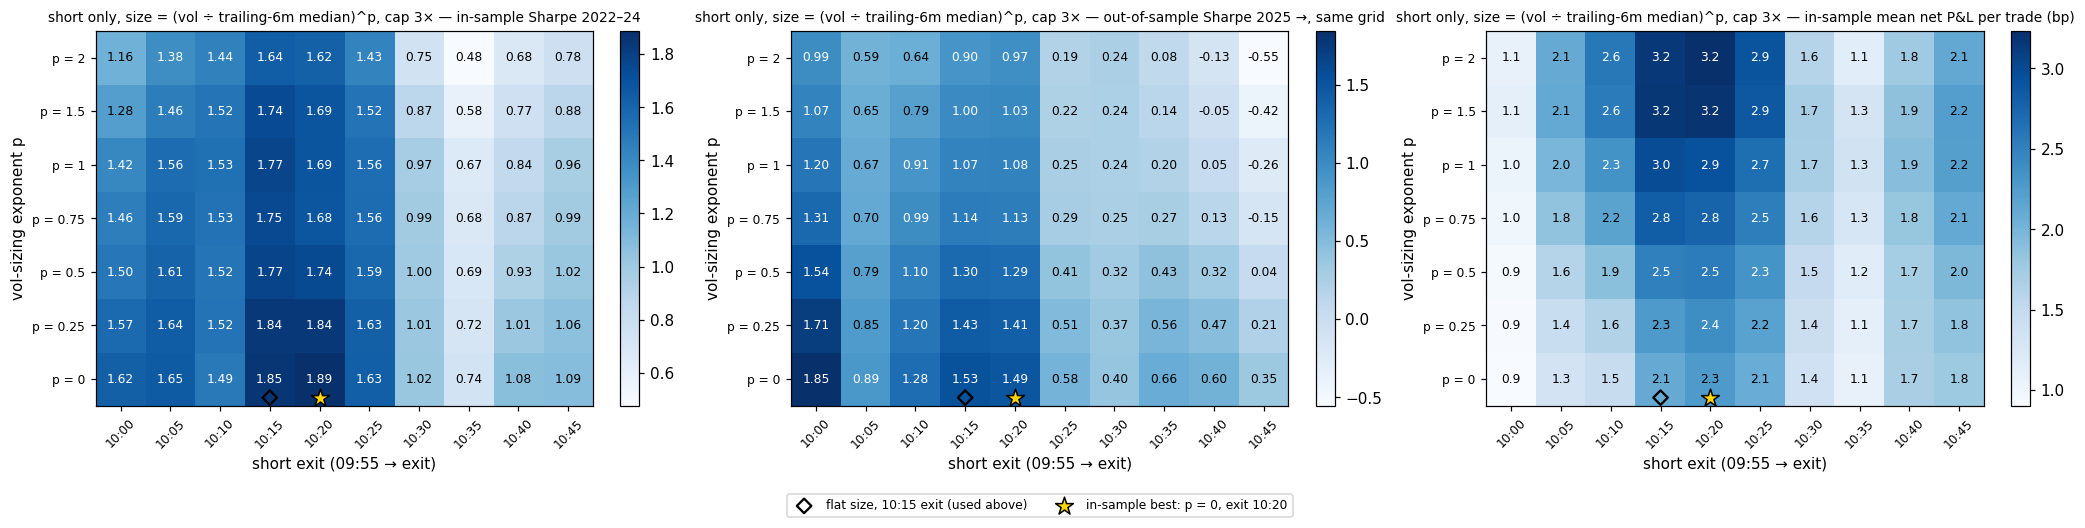

in-sample best: p = 0, exit 10:20 → IS Sharpe 1.89 (+2.27 bp/trade),  OOS Sharpe 1.49 (+1.56 bp/trade)
flat size, 10:15 exit:            IS Sharpe 1.85 (+2.10 bp/trade),  OOS Sharpe 1.53 (+1.50 bp/trade)
IS Sharpe by p (best exit in row):  p=0: 1.89@10:20, p=0.25: 1.84@10:15, p=0.5: 1.77@10:15, p=0.75: 1.75@10:15, p=1: 1.77@10:15, p=1.5: 1.74@10:15, p=2: 1.64@10:15
OOS Sharpe by p (same best-IS exit): p=0: 1.49, p=0.25: 1.43, p=0.5: 1.30, p=0.75: 1.14, p=1: 1.07, p=1.5: 1.00, p=2: 0.90
OOS best cell: p = 0, exit 10:00 → 1.85;  IS/OOS rank correlation across cells: 0.75
size at best p on gotobi days: mean 1.00×, median 1.00×, share at cap 0%, share below 0.5× 0%


In [21]:
PS2 = [0, 0.25, 0.5, 0.75, 1, 1.5, 2]; CAP = 3.0
mv_s = pd.Series(r1.loc[:, 1:FIX].std(axis=1), index=px.index)
ref_v = mv_s.rolling("182D", min_periods=40).median().shift(1)                       # trailing 6-month median, yesterday's value
relv = (mv_s / ref_v).fillna(1.0)
Ssh = np.column_stack([-bp(FIX + LAG, FIX + x + LAG).values for x in exts])           # all days × exits, short leg
def grid_vs(mask):
    S_, M_ = pd.DataFrame(index=PS2, columns=exts, dtype=float), pd.DataFrame(index=PS2, columns=exts, dtype=float)
    for p_ in PS2:
        sz = np.minimum(relv.values ** p_, CAP); Pd = sz[:, None] * Ssh - .5 * sz[:, None]
        D_ = np.where(gg[:, None], Pd, 0.0)[mask]; S_.loc[p_] = D_.mean(0) / D_.std(0, ddof=1) * np.sqrt(252); M_.loc[p_] = Pd[gg & mask].mean(0)
    return S_, M_
S_is, M_is2 = grid_vs(INS); S_oos, M_oos2 = grid_vs(~INS)
bi2 = np.unravel_index(np.nanargmax(S_is.values), S_is.shape); bp_, bx_ = PS2[bi2[0]], exts[bi2[1]]
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a_, Gd, ttl, fmt in [(ax[0], S_is, "in-sample Sharpe 2022–24", "{:.2f}"), (ax[1], S_oos, "out-of-sample Sharpe 2025 →, same grid", "{:.2f}"), (ax[2], M_is2, "in-sample mean net P&L per trade (bp)", "{:.1f}")]:
    norm = Normalize(Gd.values.min(), Gd.values.max()); im = a_.imshow(Gd.values, aspect="auto", origin="lower", cmap="Blues", norm=norm); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, p_ in enumerate(PS2):
        for cI, x_ in enumerate(exts): a_.text(cI, rI, fmt.format(Gd.values[rI, cI]), ha="center", va="center", fontsize=8, color="w" if norm(Gd.values[rI, cI]) > .6 else "k")
    a_.set_xticks(range(len(exts))); a_.set_xticklabels([lab(FIX + v) for v in exts], fontsize=8, rotation=45); a_.set_yticks(range(len(PS2))); a_.set_yticklabels([f"p = {p_}" for p_ in PS2], fontsize=8)
    a_.scatter(list(exts).index(150 - FIX - 15), 0 - .35, marker="D", s=45, facecolor="none", edgecolor="k", lw=1.5, label="flat size, 10:15 exit (used above)"); a_.scatter(bi2[1], bi2[0] - .35, marker="*", s=150, color="gold", edgecolor="k", label=f"in-sample best: p = {bp_}, exit {lab(FIX + bx_)}")
    a_.set_title(f"short only, size = (vol ÷ trailing-6m median)^p, cap 3× — {ttl}", fontsize=9); a_.set_xlabel("short exit (09:55 → exit)"); a_.set_ylabel("vol-sizing exponent p"); a_.grid(False)
ax[1].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2); plt.tight_layout(); plt.show()
flat = (0, 150 - FIX - 15)
print(f"in-sample best: p = {bp_}, exit {lab(FIX + bx_)} → IS Sharpe {S_is.loc[bp_, bx_]:.2f} ({M_is2.loc[bp_, bx_]:+.2f} bp/trade),  OOS Sharpe {S_oos.loc[bp_, bx_]:.2f} ({M_oos2.loc[bp_, bx_]:+.2f} bp/trade)")
print(f"flat size, 10:15 exit:            IS Sharpe {S_is.loc[flat]:.2f} ({M_is2.loc[flat]:+.2f} bp/trade),  OOS Sharpe {S_oos.loc[flat]:.2f} ({M_oos2.loc[flat]:+.2f} bp/trade)")
print("IS Sharpe by p (best exit in row):  " + ", ".join(f"p={p_}: {S_is.loc[p_].max():.2f}@{lab(FIX + S_is.loc[p_].idxmax())}" for p_ in PS2))
print("OOS Sharpe by p (same best-IS exit): " + ", ".join(f"p={p_}: {S_oos.loc[p_, S_is.loc[p_].idxmax()]:.2f}" for p_ in PS2))
print(f"OOS best cell: p = {PS2[np.unravel_index(np.nanargmax(S_oos.values), S_oos.shape)[0]]}, exit {lab(FIX + exts[np.unravel_index(np.nanargmax(S_oos.values), S_oos.shape)[1]])} → {S_oos.values.max():.2f};  IS/OOS rank correlation across cells: {stats.spearmanr(S_is.values.ravel(), S_oos.values.ravel()).statistic:.2f}")
sz = np.minimum(relv.values ** bp_, CAP)[gg]; print(f"size at best p on gotobi days: mean {sz.mean():.2f}×, median {np.median(sz):.2f}×, share at cap {(sz >= CAP).mean():.0%}, share below 0.5× {(sz < .5).mean():.0%}")

**Interpretation.** (Short only; 192 in-sample and 121 out-of-sample gotobi trades; cost 0.25 bp per unit filled.)
- **Vol-sizing does not help. In-sample best is p = 0 — no sizing at all.** Sharpe falls monotonically with *p* in every
  exit column: at the 10:15–10:20 ridge, 1.89 → 1.84 → 1.77 → 1.75 → 1.77 → 1.74 → 1.64 for p = 0 … 2 in-sample, and
  **1.49 → 1.43 → 1.30 → 1.14 → 1.07 → 1.00 → 0.90 out of sample.** Sizing up on noisy mornings adds P&L per trade
  (2.3 → 3.2 bp at p = 2) but adds variance faster; with a rolling reference the 2022 regime no longer inflates the
  apparent benefit, and what is left is negative. Section 5c's quintile pattern was real in-sample but does not convert
  into a better position rule.
- **Exit: 10:15–10:20 in-sample, earlier out of sample.** In-sample the ridge is 10:15–10:20 (1.85–1.89) with a cliff
  after 10:25 (below 1.1 by 10:30). Out of sample the best exit is **10:00** (1.85) and the ridge is 10:00 → 10:20
  (1.5–1.85), with everything past 10:25 collapsing to ≈ 0.3–0.6. The unwind has been finishing earlier in 2025–26 than
  it did in 2022–24. 10:15 is a fair compromise (1.85 / 1.53); 10:20 is one step too late out of sample.
- **The grid is stable**: in/out rank correlation across the 70 cells is 0.75, so the surface, not just the optimum,
  carries over.
- **Reading.** Flat size, short 09:55 → 10:15 (or 10:10 if you want to lean toward the recent regime). Morning vol is
  interesting as a description of the anomaly and useless as a trading parameter. This closes the question for *this morning's* vol — section 6d reopens it with the trailing 20-day range and gets a different answer.

**What this does.** Cumulative P&L of the in-sample-best (exit, *p*) from the grid above, short only, vol-sized, with
the 2025 out-of-sample segment marked. Flat-size 10:15 exit drawn faintly for comparison.

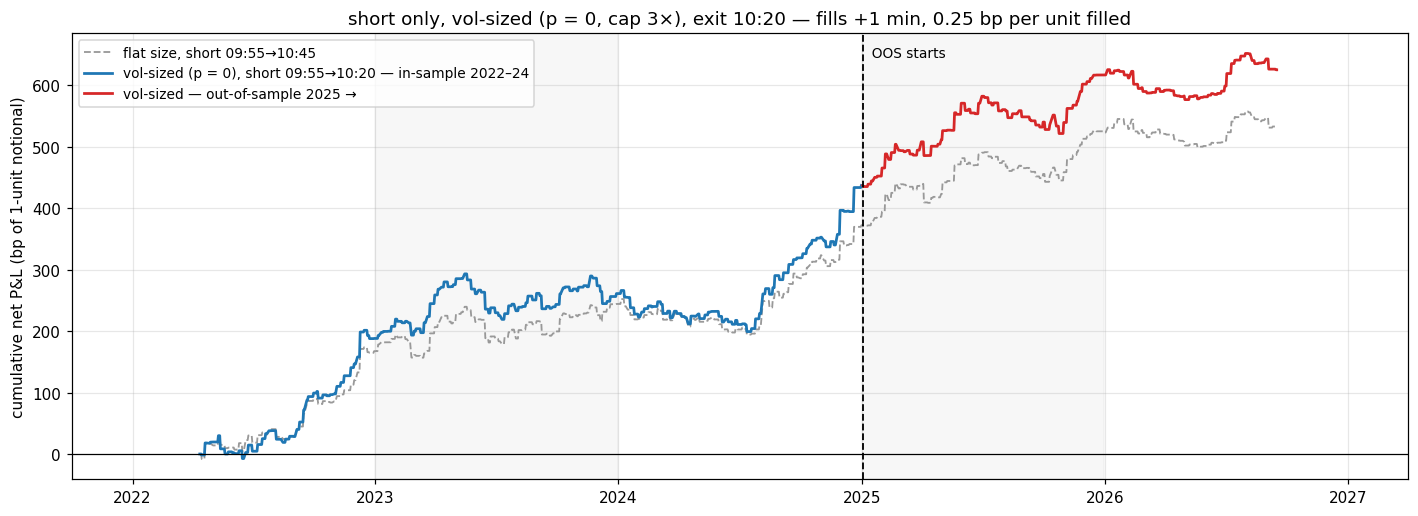

vol-sized, in-sample 2022–24 days  668  trades 192  Sharpe  1.89  mean/trade +2.27 bp  hit  62%  total  +436.7 bp = +4.37%  max drawdown -94 bp
vol-sized, OOS 2025 onward   days  414  trades 121  Sharpe  1.49  mean/trade +1.56 bp  hit  57%  total  +188.2 bp = +1.88%  max drawdown -61 bp
vol-sized, all               days 1082  trades 313  Sharpe  1.74  mean/trade +2.00 bp  hit  60%  total  +624.9 bp = +6.25%  max drawdown -94 bp

by year:
   2022                      days  175  trades  50  Sharpe  3.04  mean/trade +3.76 bp  hit  68%  total  +187.9 bp = +1.88%  max drawdown -37 bp
   2023                      days  246  trades  71  Sharpe  0.93  mean/trade +1.03 bp  hit  62%  total   +73.0 bp = +0.73%  max drawdown -74 bp
   2024                      days  247  trades  71  Sharpe  1.95  mean/trade +2.48 bp  hit  58%  total  +175.8 bp = +1.76%  max drawdown -67 bp
   2025                      days  241  trades  70  Sharpe  2.16  mean/trade +2.57 bp  hit  57%  total  +179.8 bp = +1.80%  ma

In [22]:
sz_all = np.minimum(relv.values ** bp_, CAP)
daily_v = pd.Series(0.0, index=px.index); daily_v[gg] = (sz_all * (-bp(FIX + LAG, FIX + bx_ + LAG).values) - .5 * sz_all)[gg]
cum_v = daily_v.cumsum()
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(cum_s.index, cum_s, color="0.6", lw=1.2, ls="--", label=f"flat size, short 09:55→{lab(FIX + x_)}")
ax.plot(cum_v.index[is_m], cum_v[is_m], color="C0", lw=1.8, label=f"vol-sized (p = {bp_}), short 09:55→{lab(FIX + bx_)} — in-sample 2022–24")
ax.plot(cum_v.index[oos_m], cum_v[oos_m], color="C3", lw=1.8, label="vol-sized — out-of-sample 2025 →")
ax.axvline(oos_start, color="k", ls="--", lw=1.2); ax.text(oos_start, ax.get_ylim()[1] * .97, "  OOS starts", va="top", fontsize=9); ax.axhline(0, color="k", lw=.8)
for y in sorted(set(years)): ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31), color="0.5" if y % 2 else "1.0", alpha=.06)
ax.set_ylabel("cumulative net P&L (bp of 1-unit notional)"); ax.set_title(f"short only, vol-sized (p = {bp_}, cap 3×), exit {lab(FIX + bx_)} — fills +1 min, 0.25 bp per unit filled"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()
stats_(daily_v[is_m], "vol-sized, in-sample 2022–24"); stats_(daily_v[oos_m], "vol-sized, OOS 2025 onward"); stats_(daily_v, "vol-sized, all")
print("\nby year:")
for y, d in daily_v.groupby(years): stats_(d, f"   {y}")
print(f"\ncumulative {daily_v.sum() / 100:+.2f}% over {frac:.1f} yrs → {daily_v.sum() / 100 / frac:+.2f}%/yr unlevered (annual vol {daily_v.std() * np.sqrt(252) / 100:.2f}%);  flat-size short only for comparison: OOS Sharpe {daily_s[oos_m].mean() / daily_s[oos_m].std() * np.sqrt(252):.2f}, {daily_s.sum() / 100:+.2f}% cumulative")

**Interpretation.** With p = 0 the "vol-sized" rule *is* the flat-size short (the curve differs from the dashed one only
by the exit — 10:20 vs 10:15 — and the slightly lower cost convention, 0.5 vs 0.67 bp).
- **In-sample 1.89 / out-of-sample 1.49**, +2.3 → +1.6 bp per trade, hit rate 62 → 57 %, max drawdown −94 → −61 bp.
  +6.3 % cumulative over 4.4 years = +1.4 % a year unlevered at 0.83 % vol.
- **By year:** 2022 3.0, 2023 0.9, 2024 2.0, 2025 2.2, **2026 0.2** (+0.16 bp/trade, 51 trades). 2025 was the second-best
  year of the sample and 2026 to date the worst; the red line is flat from about March 2026.
- **Reading.** The short-only, flat-size, ~10:15 exit rule is the version of this anomaly that survives every test in
  the notebook: in-sample 1.9, out-of-sample 1.5, positive every year, tiny drawdowns. Its size — ≈ +1.5–2 bp per gotobi
  day — is the number to pitch, together with the 2026 flat-line as the open risk.

## 6c. Which settlement days carry the drop?
**What this does.** Section 4 split the 09:55→10:30 return by settlement-day type and found the 20th/25th/month-end
doing the work. The traded exit is 10:15, so the question is asked again for the trade as actually run: short
09:55→10:15 (fills +1 min), gross, by type. Table: n, mean, one-sample t, hit rate, per-trade Sharpe, t against
non-gotobi days, in-sample and out-of-sample means, and the mean by year. Then: (i) a selection check — shuffle the
type labels among gotobi days and record the best single type's t each time, to see whether the winner is
distinguishable from luck; (ii) type means with weekday dummies, in case a type lands on Mondays more often;
(iii) month-end split into ordinary / quarter-end / March fiscal year-end; (iv) a one-way ANOVA across the six types;
(v) the same means for 09:55→10:15, 10:15→10:30 and 09:55→10:30, to reconcile with section 4. Figure: mean price
path around the fix by type, per-type bars in- vs out-of-sample, and a type × year heatmap.

short 09:55→10:15 (gross, fills +1 min) by settlement-day type — non-gotobi days: mean +0.44 bp, n 769
        n  mean     t   hit  sharpe_tr  vs_other_t    IS   OOS  t_OOS  2022  2023  2024  2025  2026
5    52.0  2.37  1.47  0.50       0.20        1.18  3.65  0.48   0.16  2.46  5.03  2.98  1.62 -1.05
10   52.0  2.36  1.86  0.67       0.26        1.48  2.74  1.74   1.08  9.77  1.81 -1.01 -0.67  4.69
15   54.0  1.55  1.30  0.65       0.18        0.90  1.08  2.28   1.45  1.00  1.56  0.65  4.46 -0.61
20   52.0  3.13  2.43  0.54       0.34        2.03  3.75  2.15   1.20  5.76  0.57  5.57  3.30  0.42
25   50.0  2.36  2.05  0.64       0.29        1.62  2.75  1.71   1.08  4.08  1.43  2.99  1.88  1.47
eom  53.0  2.49  2.52  0.70       0.35        1.98  1.76  3.69   3.01  1.50  0.05  3.67  5.98  0.26



selection check: best single type is the eom (t 2.52); shuffling the type labels, the best-of-six t is ≥ 2.52 in 94% of shuffles


type means, raw vs weekday-adjusted: 5: +2.37→+3.15, 10: +2.36→+3.02, 15: +1.55→+2.29, 20: +3.13→+3.81, 25: +2.36→+3.07, eom: +2.49→+3.18
month-end split: ordinary EOM +2.95 (n 36) | quarter-end +1.51 (n 17) | March fiscal year-end +3.40 (n 4)

one-way ANOVA across the six types, 09:55→10:15: p = 0.98;  Kruskal–Wallis p = 0.98

why section 4 (09:55→10:30) saw a type difference — mean short P&L by type and window (gross, bp):
  type   09:55→10:15  10:15→10:30  09:55→10:30
  5             2.37        -2.16         0.21
  10            2.36        -2.94        -0.58
  15            1.55        -1.12         0.43
  20            3.13        -0.60         2.53
  25            2.36         0.95         3.31
  eom           2.49         0.75         3.24
  none          0.44        -0.38         0.06


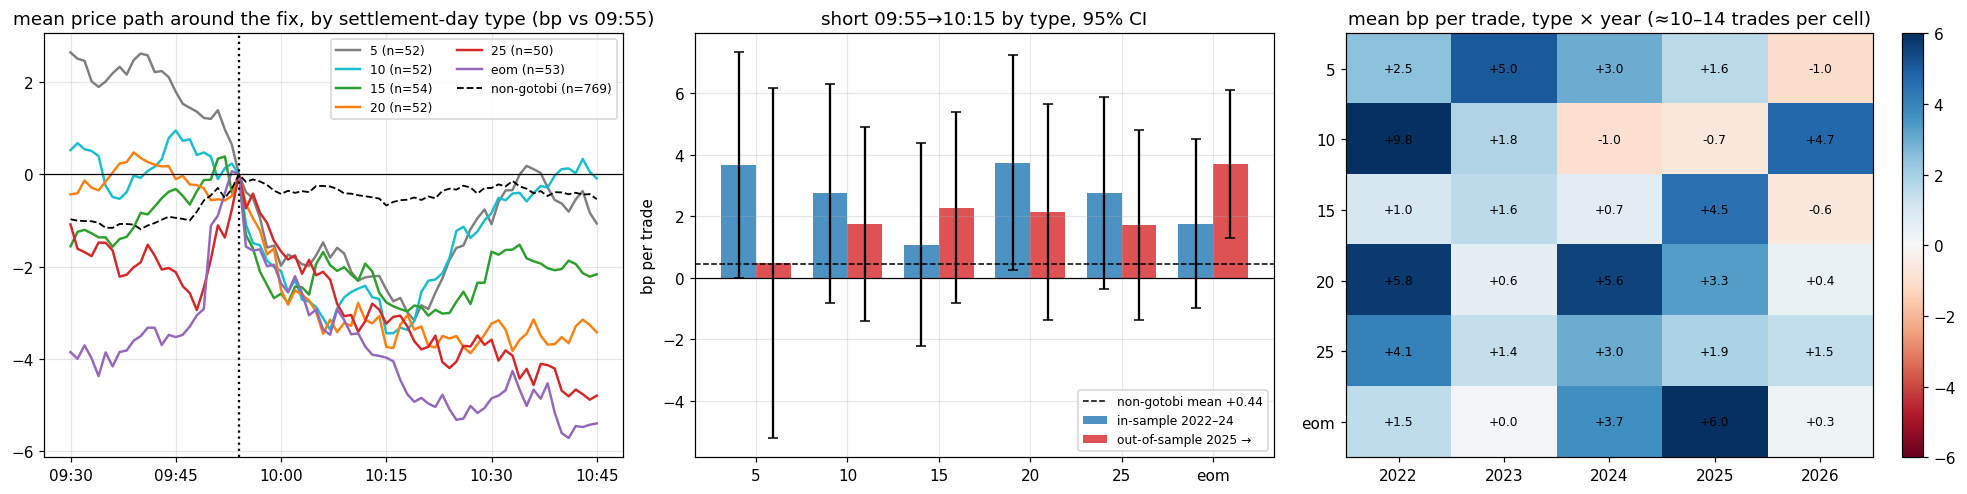

In [23]:
XS = 135 - FIX                                                                          # 10:15 exit (x_ is clobbered by the grid loop above)
ORDER = ["5", "10", "15", "20", "25", "eom"]; COL = dict(zip(ORDER, ["C7", "C9", "C2", "C1", "C3", "C4"]))
Sg_ = -bp(FIX + LAG, FIX + XS + LAG)                                                   # gross short P&L 09:56→10:16, every day
oth = Sg_[~gg]
rows = {}
for k in ORDER:
    m_ = (K == k).values; s = Sg_[m_]; si, so = Sg_[m_ & INS], Sg_[m_ & ~INS]
    rows[k] = dict(n=len(s), mean=s.mean(), t=stats.ttest_1samp(s, 0).statistic, hit=(s > 0).mean(), sharpe_tr=s.mean() / s.std(),
                   vs_other_t=stats.ttest_ind(s, oth, equal_var=False).statistic, IS=si.mean(), OOS=so.mean(), t_OOS=stats.ttest_1samp(so, 0).statistic,
                   **{str(y): Sg_[m_ & (years == y)].mean() for y in sorted(set(years))})
TT = pd.DataFrame(rows).T
print(f"short 09:55→{lab(FIX + XS)} (gross, fills +1 min) by settlement-day type — non-gotobi days: mean {oth.mean():+.2f} bp, n {len(oth)}"); print(TT.round(2).to_string())
# max-of-six selection null: shuffle type labels among gotobi days, record the best single type's t
rng3 = np.random.default_rng(2); Sgg, Kgg = Sg_[gg].values, K[gg].values
best_obs = TT.t.max(); null6 = [max(stats.ttest_1samp(Sgg[Kp == k], 0).statistic for k in ORDER) for Kp in (rng3.permutation(Kgg) for _ in range(3000))]
print(f"\nselection check: best single type is the {TT.t.idxmax()} (t {best_obs:.2f}); shuffling the type labels, the best-of-six t is ≥ {best_obs:.2f} in {np.mean(np.array(null6) >= best_obs):.0%} of shuffles")
# weekday confound: type dummies with and without weekday dummies
Xd = pd.get_dummies(K[gg], drop_first=False)[ORDER].astype(float); Xw = pd.get_dummies(px.index[gg].weekday, prefix="wd", drop_first=True).astype(float).set_index(Xd.index)
m0 = sm.OLS(Sg_[gg], Xd).fit(cov_type="HC3"); m1 = sm.OLS(Sg_[gg], pd.concat([Xd, Xw], axis=1)).fit(cov_type="HC3")
print("type means, raw vs weekday-adjusted: " + ", ".join(f"{k}: {m0.params[k]:+.2f}→{m1.params[k]:+.2f}" for k in ORDER))
# quarter/fiscal ends inside EOM
eom = (K == "eom").values; qe = eom & px.index.month.isin([3, 6, 9, 12]); fy = eom & (px.index.month == 3)
print(f"month-end split: ordinary EOM {Sg_[eom & ~qe].mean():+.2f} (n {(eom & ~qe).sum()}) | quarter-end {Sg_[qe].mean():+.2f} (n {qe.sum()}) | March fiscal year-end {Sg_[fy].mean():+.2f} (n {fy.sum()})")
print(f"\none-way ANOVA across the six types, 09:55→{lab(FIX + XS)}: p = {stats.f_oneway(*[Sg_[(K == k).values] for k in ORDER]).pvalue:.2f};  Kruskal–Wallis p = {stats.kruskal(*[Sg_[(K == k).values] for k in ORDER]).pvalue:.2f}")
print("\nwhy section 4 (09:55→10:30) saw a type difference — mean short P&L by type and window (gross, bp):")
print(f"  {'type':5s} {'09:55→10:15':>12s} {'10:15→10:30':>12s} {'09:55→10:30':>12s}")
for k in ORDER + ["none"]:
    m_ = (K == k).values; print(f"  {k:5s} {-bp(FIX + LAG, FIX + 21 + LAG)[m_].mean():12.2f} {-bp(FIX + 21 + LAG, FIX + 36 + LAG)[m_].mean():12.2f} {-bp(FIX + LAG, FIX + 36 + LAG)[m_].mean():12.2f}")
# figure: paths by type, bar with CI (IS vs OOS), year heatmap
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
seg = list(range(90, 166)); base = lpx[FIX]
for k in ORDER:
    m_ = (K == k).values; p = (lpx.loc[m_, seg].sub(base[m_], axis=0)) * 1e4; ax[0].plot(seg, p.mean(), color=COL[k], lw=1.6, label=f"{k} (n={m_.sum()})")
p = (lpx.loc[~gg, seg].sub(base[~gg], axis=0)) * 1e4; ax[0].plot(seg, p.mean(), color="k", lw=1.2, ls="--", label=f"non-gotobi (n={(~gg).sum()})")
ax[0].axvline(FIX, color="k", ls=":"); ax[0].axhline(0, color="k", lw=.8); ax[0].set_xticks(range(90, 166, 15)); ax[0].set_xticklabels([lab(m) for m in range(90, 166, 15)]); ax[0].set_title("mean price path around the fix, by settlement-day type (bp vs 09:55)"); ax[0].legend(fontsize=8, ncol=2)
xs = np.arange(len(ORDER)); w = .38
for j, (lbl, msk, c) in enumerate([("in-sample 2022–24", INS, "C0"), ("out-of-sample 2025 →", ~INS, "C3")]):
    mu = [Sg_[(K == k).values & msk].mean() for k in ORDER]; se = [Sg_[(K == k).values & msk].std() / np.sqrt(((K == k).values & msk).sum()) for k in ORDER]
    ax[1].bar(xs + (j - .5) * w, mu, w, yerr=1.96 * np.array(se), capsize=3, color=c, alpha=.8, label=lbl)
ax[1].axhline(oth.mean(), color="k", ls="--", lw=1, label=f"non-gotobi mean {oth.mean():+.2f}"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xticks(xs); ax[1].set_xticklabels(ORDER); ax[1].set_ylabel("bp per trade"); ax[1].set_title(f"short 09:55→{lab(FIX + XS)} by type, 95% CI"); ax[1].legend(fontsize=8)
YH = TT[[str(y) for y in sorted(set(years))]].astype(float)
im = ax[2].imshow(YH.values, aspect="auto", cmap="RdBu", vmin=-6, vmax=6); plt.colorbar(im, ax=ax[2], fraction=.04)
for r_i in range(YH.shape[0]):
    for c_i in range(YH.shape[1]): ax[2].text(c_i, r_i, f"{YH.values[r_i, c_i]:+.1f}", ha="center", va="center", fontsize=8)
ax[2].set_xticks(range(YH.shape[1])); ax[2].set_xticklabels(YH.columns); ax[2].set_yticks(range(len(ORDER))); ax[2].set_yticklabels(ORDER); ax[2].set_title("mean bp per trade, type × year (≈10–14 trades per cell)"); ax[2].grid(False)
plt.tight_layout(); plt.show()

**What this does.** The same question as a trading rule: trade only the *k* heaviest settlement types, k = 6 (all)
down to 1 (month-end only), with the types ordered by settlement weight before looking (5th < 10th < 15th < 20th <
25th < month-end — corporate payment dates thicken toward month-end), so k is one ordered integer rather than a
choice among 63 subsets. Grid: k × short exit, short only, flat size, ⅔ of the 1 bp/day cost. In-sample Sharpe,
out-of-sample Sharpe, net bp per trade.

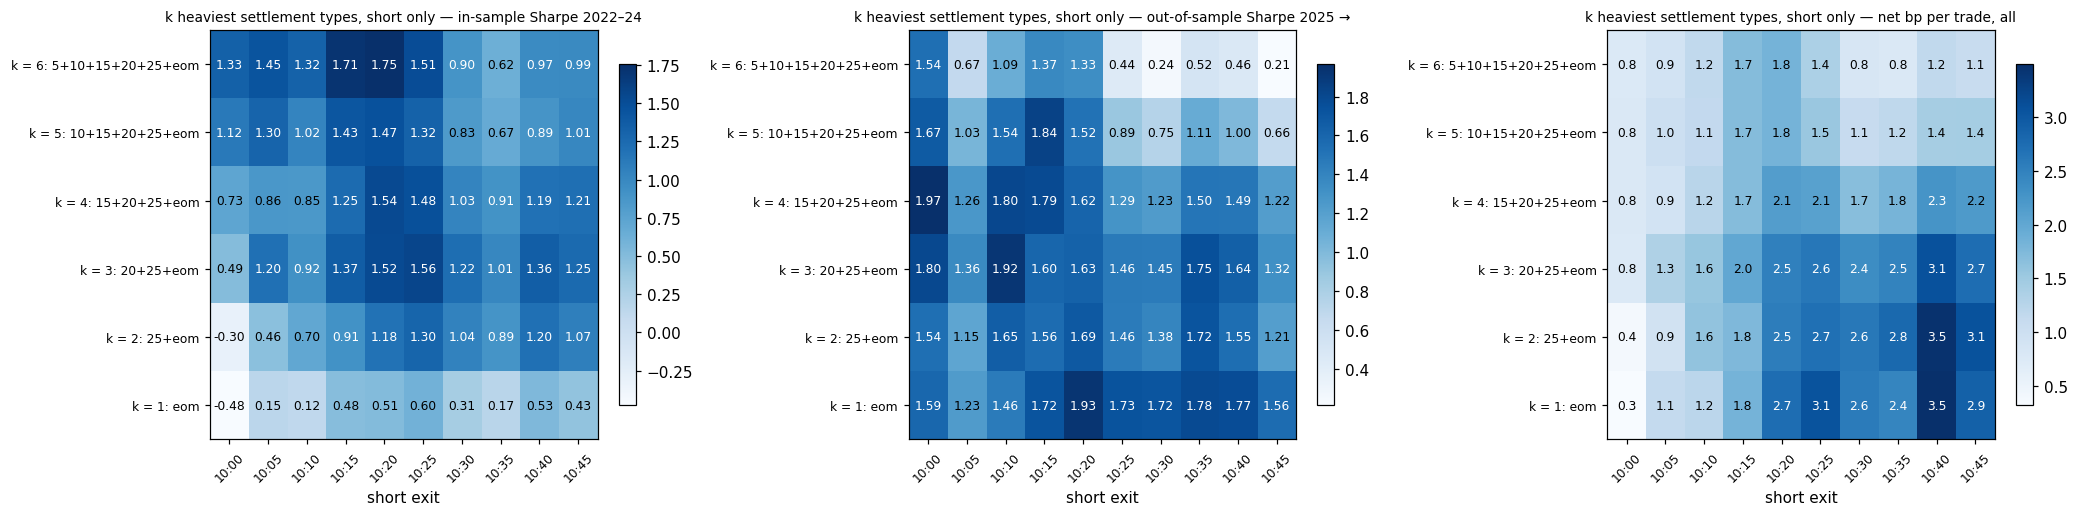

k heaviest types, exit 10:15 — trades / IS Sharpe / OOS Sharpe / all-sample Sharpe / bp per trade:
  k = 6 (5+10+15+20+25+eom) n 313   IS 1.71   OOS 1.37   all 1.59   +1.70 bp   total +533 bp
  k = 5 (10+15+20+25+eom ) n 261   IS 1.43   OOS 1.84   all 1.55   +1.70 bp   total +445 bp
  k = 4 (15+20+25+eom    ) n 209   IS 1.25   OOS 1.79   all 1.41   +1.71 bp   total +357 bp
  k = 3 (20+25+eom       ) n 155   IS 1.37   OOS 1.60   all 1.43   +2.00 bp   total +309 bp
  k = 2 (25+eom          ) n 103   IS 0.91   OOS 1.56   all 1.11   +1.76 bp   total +181 bp
  k = 1 (eom             ) n  53   IS 0.48   OOS 1.72   all 0.87   +1.82 bp   total +97 bp
IS/OOS rank correlation across the 60 cells: -0.20


In [24]:
ks = [6, 5, 4, 3, 2, 1]; exts = np.arange(6, 52, 5)
def sh_(d): return d.mean() / d.std() * np.sqrt(252)
Sk_is, Sk_oos, Mk = (pd.DataFrame(index=ks, columns=exts, dtype=float) for _ in range(3))
for k in ks:
    m_ = K.isin(ORDER[6 - k:]).values
    for x in exts:
        d = pd.Series(0.0, index=px.index); d[m_] = (-bp(FIX + LAG, FIX + x + LAG) - TC_DAY * 2 / 3)[m_]
        Sk_is.loc[k, x], Sk_oos.loc[k, x], Mk.loc[k, x] = sh_(d[INS]), sh_(d[~INS]), d[m_].mean()
fig, ax = plt.subplots(1, 3, figsize=(19, 4.8))
for a_, Gd, ttl, fmt in [(ax[0], Sk_is, "in-sample Sharpe 2022–24", "{:.2f}"), (ax[1], Sk_oos, "out-of-sample Sharpe 2025 →", "{:.2f}"), (ax[2], Mk, "net bp per trade, all", "{:.1f}")]:
    norm = Normalize(Gd.values.min(), Gd.values.max()); im = a_.imshow(Gd.values, aspect="auto", cmap="Blues", norm=norm); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, k in enumerate(ks):
        for cI, x in enumerate(exts): a_.text(cI, rI, fmt.format(Gd.values[rI, cI]), ha="center", va="center", fontsize=8, color="w" if norm(Gd.values[rI, cI]) > .6 else "k")
    a_.set_xticks(range(len(exts))); a_.set_xticklabels([lab(FIX + v) for v in exts], fontsize=8, rotation=45); a_.set_yticks(range(len(ks))); a_.set_yticklabels([f"k = {k}: {'+'.join(ORDER[6 - k:])}" for k in ks], fontsize=8)
    a_.set_title(f"k heaviest settlement types, short only — {ttl}", fontsize=9); a_.set_xlabel("short exit"); a_.grid(False)
plt.tight_layout(); plt.show()
print("k heaviest types, exit 10:15 — trades / IS Sharpe / OOS Sharpe / all-sample Sharpe / bp per trade:")
for k in ks:
    m_ = K.isin(ORDER[6 - k:]).values; d = pd.Series(0.0, index=px.index); d[m_] = (-bp(FIX + LAG, FIX + XS + LAG) - TC_DAY * 2 / 3)[m_]
    print(f"  k = {k} ({'+'.join(ORDER[6 - k:]):16s}) n {m_.sum():3d}   IS {sh_(d[INS]):.2f}   OOS {sh_(d[~INS]):.2f}   all {sh_(d):.2f}   {d[m_].mean():+.2f} bp   total {d.sum():+.0f} bp")
print(f"IS/OOS rank correlation across the {Sk_is.size} cells: {stats.spearmanr(Sk_is.values.ravel(), Sk_oos.values.ravel()).statistic:.2f}")

**Interpretation — no settlement day is higher conviction; heavy days just unwind for longer.**
- **At the 10:15 exit the six types are indistinguishable.** Means run +1.6 to +3.1 bp, every one above the
  non-gotobi +0.4; one-way ANOVA p = 0.98. The "best" type (month-end, t = 2.5) is beaten by the best-of-six in
  **94 % of label shuffles** — it is whichever type happened to be on top. Weekday adjustment moves all six up by
  ~0.7 bp and changes no ordering. The type × year heatmap is 30 cells of 10–14 trades; 26 are positive and the
  four negatives are scattered, not a type. In- vs out-of-sample bars swap places freely (5th: 3.7 → 0.5; EOM:
  1.8 → 3.7) — that is what n = 25 per bar looks like.
- **What section 4 actually found.** The left chart shows it: **all six types fall identically from 09:55 to about
  10:10**. After that the 5th/10th/15th bounce back (+2.2 / +2.9 / +1.1 bp of give-back by 10:30) while the
  20th/25th/month-end keep drifting down (−0.6 / +1.0 / +0.8). Type does not decide *whether* the fix unwinds; it
  decides *how long* the unwind lasts. That is also why the 10:15 exit was chosen: it is the last minute before the
  light days reverse.
- **The k × exit grid says the same.** In-sample the best row is k = 6 (all days, 1.71–1.75 at 10:15–10:20 — more
  trades win on √n); out of sample it is k = 4–5 (1.8–2.0). The two panels' cell ranks correlate at **−0.20**: there
  is no stable k. What *is* stable across both panels is the shape — the heavy-day rows (k ≤ 3) stay at
  Sharpe 1.2–1.9 out to 10:45 while the all-day row collapses to 0.2–0.5 after 10:25. Letting the heavy days run to
  10:20 lifts the all-days rule from 1.71 / 1.36 to 1.84 / 1.48 (IS / OOS) — real but one grid step, not a parameter
  worth pitching.
- **Month-end sub-types:** ordinary month-ends +3.0, quarter-ends +1.5 (n = 17), March fiscal year-end +3.4 (n = 4).
  Nothing to build on.
- **Reading.** Trade every gotobi day. The drop is a property of the fix on settlement days, not of particular
  settlement days; concentrating on "heavy" dates throws away identical trades and Sharpe with them. If you want one
  refinement, it is exit timing by type (10:15 light, ~10:20–10:30 heavy), and it is worth about 0.1 of Sharpe.

## 6d. Vol sizing revisited: which vol, and relative to what?
**Why reopen it.** Section 6 sized the short by *this morning's* realised vol relative to a rolling 6-month median and
found sizing hurts Sharpe. But "vol" is not one thing. A fast measure (this morning, the fix spike) says how noisy
today is; a slow measure (the trailing 20-day range) says what regime we are in. Section 5c showed the drop is bigger
on noisy mornings — the problem was that the *risk* is bigger too, so the ratio did not improve. The question here is
whether a different vol measure separates reward from risk.

**What this does.** Ten vol measures, all known at 09:54 (most at 08:00). For each, on gotobi days: correlation with
the short's P&L (does it predict the drop?) and with |P&L| (does it predict the risk?), the per-trade Sharpe
(mean ÷ sd) in the low / mid / high tercile of the measure, and the high-minus-low Sharpe gap in-sample and
out-of-sample. A measure is useful for sizing only if per-trade Sharpe *rises* with it — then sizing up buys more
reward per unit of risk. If Sharpe is flat across terciles, sizing is leverage.

In [25]:
Sx = -bp(FIX + LAG, FIX + XS + LAG)                                                          # gross short 09:55→10:15, every day
rng_d = np.log(px.max(axis=1) / px.min(axis=1)) * 1e4                                        # Tokyo-session high–low range, bp
rv_d = r1.std(axis=1)                                                                         # Tokyo-session 1-min realised vol
VOLS = {"morning rv 08:00–09:55 (section 5c / 6)": r1.loc[:, 1:FIX].std(axis=1), "late-morning rv 09:30–09:55": r1.loc[:, 91:FIX].std(axis=1),
        "fix spike |09:54–09:55|": r1[[FIX, FIX + 1]].abs().sum(axis=1), "morning range 08:00–09:55": np.log(px.loc[:, :FIX].max(axis=1) / px.loc[:, :FIX].min(axis=1)) * 1e4,
        "overnight gap |prev close → 08:00|": ((lpx[0] - lpx[419].shift(1)) * 1e4).abs(), "previous day's Tokyo range": rng_d.shift(1),
        "trailing 5-day rv": rv_d.shift(1).rolling(5).mean(), "trailing 20-day Tokyo range": rng_d.shift(1).rolling(20).mean(), "trailing 60-day Tokyo range": rng_d.shift(1).rolling(60).mean(),
        "morning rv ÷ trailing 20-day rv (surprise)": r1.loc[:, 1:FIX].std(axis=1) / rv_d.shift(1).rolling(20).mean()}
def terciles(v, s):
    q = pd.qcut(v.rank(method="first"), 3, labels=["lo", "mid", "hi"]); return s.groupby(q).agg(lambda z: z.mean() / z.std()), s.groupby(q).mean()
rows = []
for nm, v in VOLS.items():
    d = pd.concat([v[gg].rename("v"), Sx[gg].rename("s")], axis=1).dropna(); t, m = terciles(d.v, d.s)
    t_is, _ = terciles(d.v[d.index < SPLIT], d.s[d.index < SPLIT]); t_oos, _ = terciles(d.v[d.index >= SPLIT], d.s[d.index >= SPLIT])
    rows.append(dict(vol=nm, corr_pnl=d.v.corr(d.s), corr_abs=d.v.corr(d.s.abs()), lo=t["lo"], mid=t["mid"], hi=t["hi"], hi_minus_lo=t["hi"] - t["lo"], IS_hi_lo=t_is["hi"] - t_is["lo"], OOS_hi_lo=t_oos["hi"] - t_oos["lo"], bp_lo=m["lo"], bp_hi=m["hi"]))
VS = pd.DataFrame(rows).set_index("vol")
print("ten ways to measure 'vol', gotobi days: correlation with the short's P&L and |P&L|, per-trade Sharpe (mean ÷ sd) by tercile of the vol measure, and the hi − lo Sharpe gap in-/out-of-sample")
print(VS.round(2).to_string())

ten ways to measure 'vol', gotobi days: correlation with the short's P&L and |P&L|, per-trade Sharpe (mean ÷ sd) by tercile of the vol measure, and the hi − lo Sharpe gap in-/out-of-sample
                                            corr_pnl  corr_abs    lo   mid    hi  hi_minus_lo  IS_hi_lo  OOS_hi_lo  bp_lo  bp_hi
vol                                                                                                                             
morning rv 08:00–09:55 (section 5c / 6)         0.10      0.28  0.14  0.30  0.33         0.19      0.24       0.05   0.84   3.91
late-morning rv 09:30–09:55                     0.15      0.36  0.12  0.29  0.34         0.22      0.24      -0.08   0.70   4.05
fix spike |09:54–09:55|                         0.23      0.35  0.18  0.12  0.46         0.28      0.18       0.17   1.53   4.58
morning range 08:00–09:55                       0.12      0.32  0.15  0.34  0.28         0.13      0.20       0.02   0.84   3.04
overnight gap |prev close → 08:00|   

**What this does.** Takes the winner — regime vol = trailing 20-day mean Tokyo range, known at 08:00 — and stress-tests
the tercile pattern: without 2022, in- and out-of-sample separately, ranking *within* each year so the year level cannot
drive it, and with 5/10/40/60-day windows. Then quarter by quarter (per-trade Sharpe vs mean regime vol, n = 18) and a
2 × 2 of regime vol × this morning's vol, to see how the fast and slow measures interact.

regime vol (trailing 20-day range): per-trade Sharpe by tercile — is it just 2022?
  all            Sharpe/trade 0.06 / 0.14 / 0.53   mean bp +0.4 / +1.2 / +5.5   (n 306)
  ex-2022        Sharpe/trade 0.09 / 0.01 / 0.54   mean bp +0.6 / +0.1 / +5.4   (n 263)
  in-sample      Sharpe/trade -0.04 / 0.23 / 0.59   mean bp -0.3 / +2.1 / +6.0   (n 185)
  out-of-sample  Sharpe/trade 0.16 / 0.15 / 0.37   mean bp +0.9 / +1.1 / +3.9   (n 121)
  within-year terciles (rank inside each year, so the year level cannot drive it): 0.16 / 0.15 / 0.45
  same with a  5-day window: 0.17 / 0.04 / 0.54
  same with a 10-day window: 0.10 / 0.11 / 0.52
  same with a 40-day window: 0.10 / 0.31 / 0.35
  same with a 60-day window: 0.17 / 0.20 / 0.40
  trailing-20d range by year (bp): 2022: 52, 2023: 43, 2024: 45, 2025: 46, 2026: 28   ← 2026 is the lowest-vol year in the sample


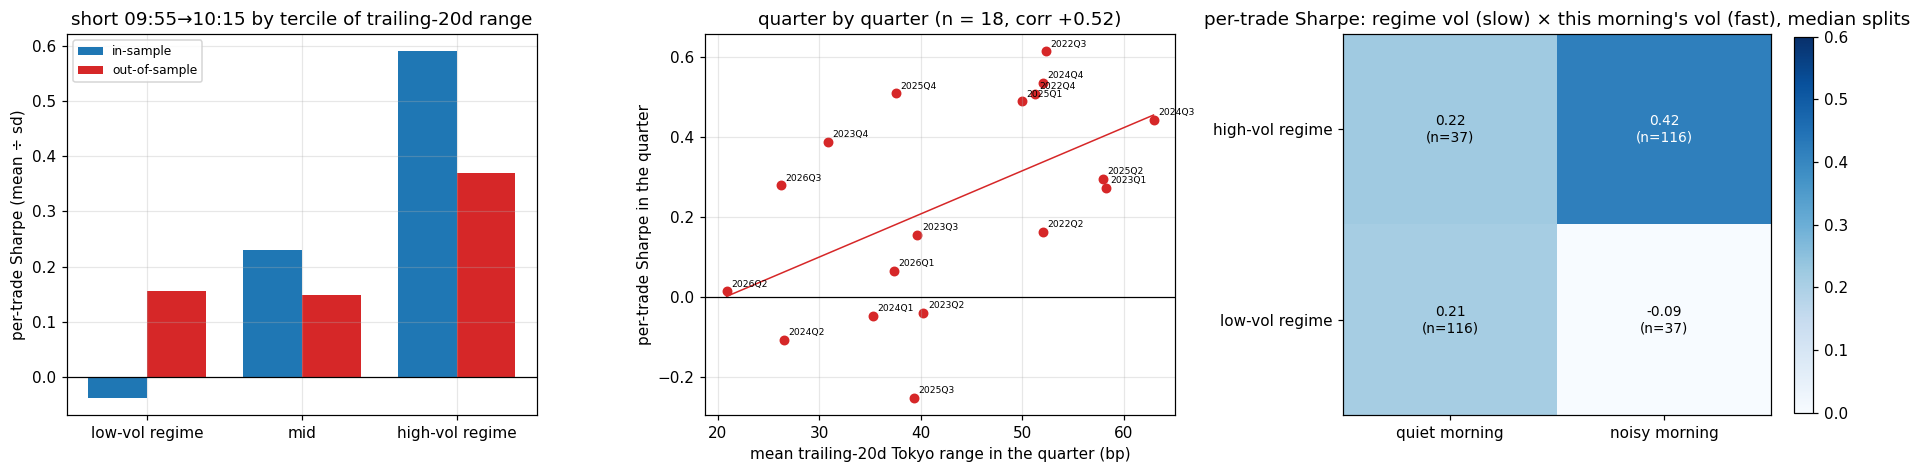


regime × morning (per-trade Sharpe):
fast             quiet morning  noisy morning
slow                                         
low-vol regime            0.21          -0.09
high-vol regime           0.22           0.42


In [26]:
REG = rng_d.shift(1).rolling(20).mean()                                                         # regime vol: trailing 20-day Tokyo range, known at 08:00
print("regime vol (trailing 20-day range): per-trade Sharpe by tercile — is it just 2022?")
d = pd.concat([REG[gg].rename("v"), Sx[gg].rename("s")], axis=1).dropna(); yr = pd.Series(years[gg], index=px.index[gg]).loc[d.index]
for lbl, msk in [("all", np.ones(len(d), bool)), ("ex-2022", np.asarray(yr != 2022)), ("in-sample", np.asarray(d.index < SPLIT)), ("out-of-sample", np.asarray(d.index >= SPLIT))]:
    t, m = terciles(d.v[msk], d.s[msk]); print(f"  {lbl:14s} Sharpe/trade {t['lo']:.2f} / {t['mid']:.2f} / {t['hi']:.2f}   mean bp {m['lo']:+.1f} / {m['mid']:+.1f} / {m['hi']:+.1f}   (n {msk.sum()})")
qw = d.v.groupby(yr).transform(lambda s: pd.qcut(s.rank(method="first"), 3, labels=[0, 1, 2])); tw = d.s.groupby(qw).agg(lambda z: z.mean() / z.std())
print(f"  within-year terciles (rank inside each year, so the year level cannot drive it): {tw[0]:.2f} / {tw[1]:.2f} / {tw[2]:.2f}")
for N in [5, 10, 40, 60]:
    dN = pd.concat([rng_d.shift(1).rolling(N).mean()[gg].rename("v"), Sx[gg].rename("s")], axis=1).dropna(); t, _ = terciles(dN.v, dN.s); print(f"  same with a {N:2d}-day window: {t['lo']:.2f} / {t['mid']:.2f} / {t['hi']:.2f}")
print("  trailing-20d range by year (bp): " + ", ".join(f"{y}: {REG[years == y].mean():.0f}" for y in sorted(set(years))) + "   ← 2026 is the lowest-vol year in the sample")
q = px.index.to_period("Q"); QQ = pd.DataFrame({"sharpe": Sx[gg].groupby(q[gg]).agg(lambda z: z.mean() / z.std()), "vol": REG[gg].groupby(q[gg]).mean(), "n": G.groupby(q).sum()}).dropna(); QQ = QQ[QQ.n >= 8]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for j, (lbl, msk, c) in enumerate([("in-sample", np.asarray(d.index < SPLIT), "C0"), ("out-of-sample", np.asarray(d.index >= SPLIT), "C3")]):
    t, _ = terciles(d.v[msk], d.s[msk]); ax[0].bar(np.arange(3) + (j - .5) * .38, t.values, .38, color=c, label=lbl)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(["low-vol regime", "mid", "high-vol regime"]); ax[0].set_ylabel("per-trade Sharpe (mean ÷ sd)"); ax[0].set_title("short 09:55→10:15 by tercile of trailing-20d range"); ax[0].legend(fontsize=8); ax[0].axhline(0, color="k", lw=.8)
ax[1].scatter(QQ.vol, QQ.sharpe, color="C3", s=30); b1, a1 = np.polyfit(QQ.vol, QQ.sharpe, 1); xx = np.linspace(QQ.vol.min(), QQ.vol.max(), 2); ax[1].plot(xx, a1 + b1 * xx, color="C3", lw=1)
for i_, r_ in QQ.iterrows(): ax[1].annotate(str(i_), (r_.vol, r_.sharpe), fontsize=6, xytext=(3, 3), textcoords="offset points")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xlabel("mean trailing-20d Tokyo range in the quarter (bp)"); ax[1].set_ylabel("per-trade Sharpe in the quarter"); ax[1].set_title(f"quarter by quarter (n = {len(QQ)}, corr {QQ.vol.corr(QQ.sharpe):+.2f})")
m1 = r1.loc[:, 1:FIX].std(axis=1); dd = pd.concat([m1[gg].rename("fast"), REG[gg].rename("slow"), Sx[gg].rename("s")], axis=1).dropna()
qf = (dd.fast > dd.fast.median()).map({False: "quiet morning", True: "noisy morning"}); qs = (dd.slow > dd.slow.median()).map({False: "low-vol regime", True: "high-vol regime"})
PT2 = dd.s.groupby([qs, qf]).agg(lambda z: z.mean() / z.std()).unstack().loc[["low-vol regime", "high-vol regime"], ["quiet morning", "noisy morning"]]; NN = dd.s.groupby([qs, qf]).size().unstack().loc[PT2.index, PT2.columns]
im = ax[2].imshow(PT2.values, cmap="Blues", aspect="auto", origin="lower", vmin=0, vmax=.6); plt.colorbar(im, ax=ax[2], fraction=.04)
for r_i in range(2):
    for c_i in range(2): ax[2].text(c_i, r_i, f"{PT2.values[r_i, c_i]:.2f}\n(n={NN.values[r_i, c_i]})", ha="center", va="center", fontsize=9, color="w" if PT2.values[r_i, c_i] > .35 else "k")
ax[2].set_xticks(range(2)); ax[2].set_xticklabels(PT2.columns); ax[2].set_yticks(range(2)); ax[2].set_yticklabels(PT2.index); ax[2].set_title("per-trade Sharpe: regime vol (slow) × this morning's vol (fast), median splits"); ax[2].grid(False)
plt.tight_layout(); plt.show()
print("\nregime × morning (per-trade Sharpe):\n" + PT2.round(2).to_string())

**What this does.** The section-6 grid again — short only, exit × sizing exponent *p* — with two changes. (1) Vol is the
trailing 20-day range instead of this morning's. (2) The reference is the **median of all past days** (expanding,
shifted one day) instead of a rolling 6-month median. The rolling reference re-centres size at 1× every few months,
which throws away the *level* of vol — exactly the information the terciles say matters. Size = clip((vol ÷ past
median)^*p*, ⅓, 3), *p* from −1 (inverse-vol, risk-parity style) to 2; cost 0.25 bp per unit per fill. In-sample fit
2022–24, scored 2025 →. Then cumulative P&L for *p* = 0, 1, 2.

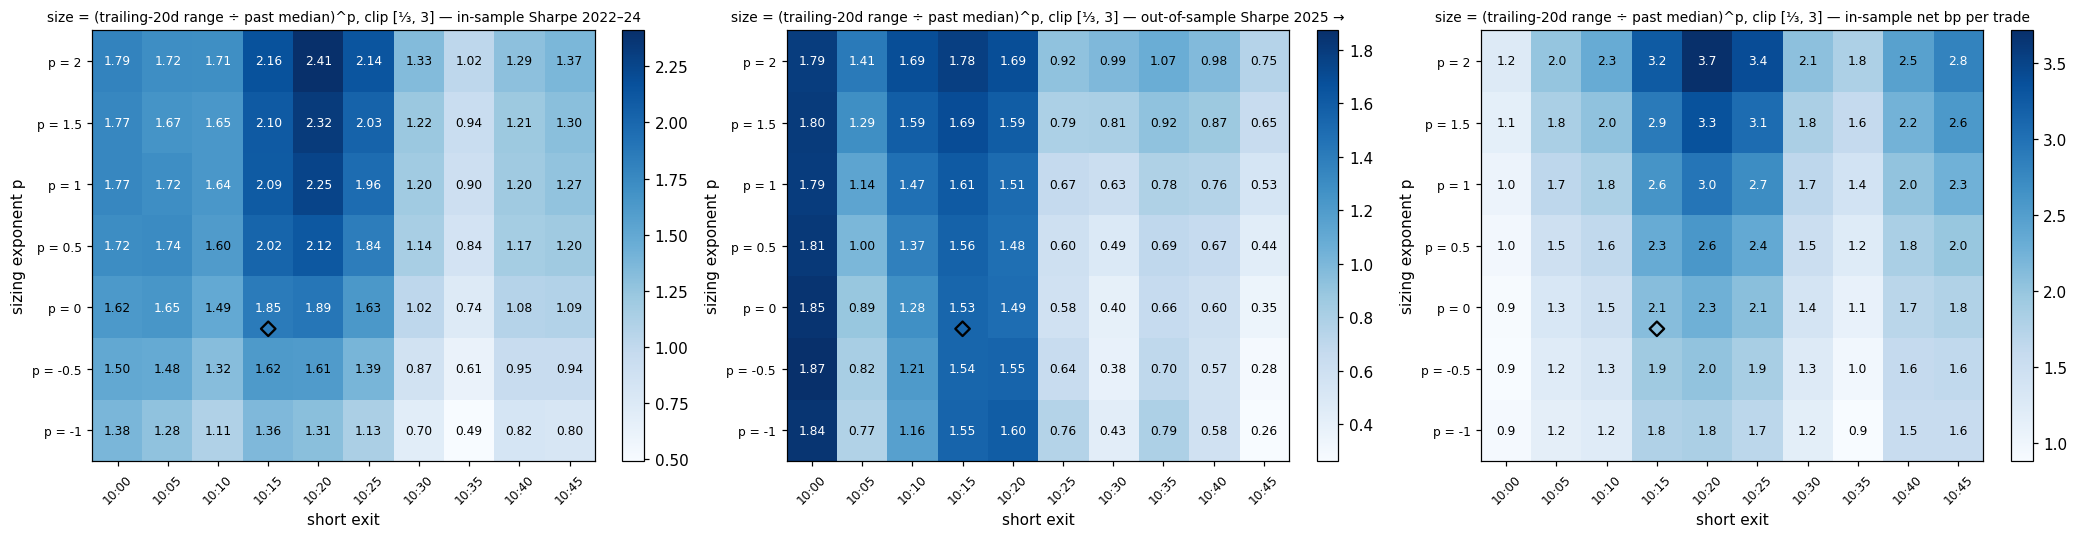

at the 10:15 exit — p: IS Sharpe / OOS Sharpe / IS bp / OOS bp:  p=-1: 1.36/1.55/+1.8/+1.9   p=-0.5: 1.62/1.54/+1.9/+1.6   p=0: 1.85/1.53/+2.1/+1.5   p=0.5: 2.02/1.56/+2.3/+1.5   p=1: 2.09/1.61/+2.6/+1.6   p=1.5: 2.10/1.69/+2.9/+1.7   p=2: 2.16/1.78/+3.2/+2.0
IS/OOS rank correlation across the 70 cells: 0.66;  compare the morning-vol grid above: p ≥ 0.5 lost 0.1–0.6 of OOS Sharpe


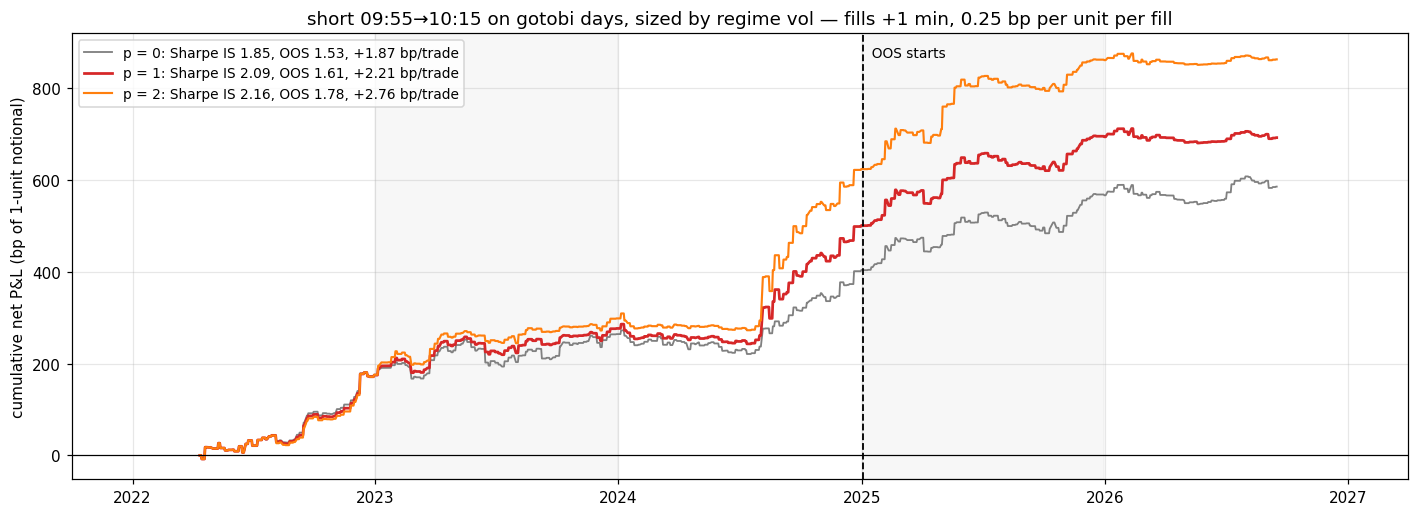

size at p = 1 on gotobi days: mean 0.91×, range [0.33, 2.41], by year 2022: 0.99×, 2023: 0.83×, 2024: 1.01×, 2025: 1.01×, 2026: 0.66×
p = 0 by year Sharpe: 2022: 2.95, 2023: 1.14, 2024: 1.74, 2025: 2.10, 2026: 0.48   max drawdown -59 bp, worst day -30 bp
p = 1 by year Sharpe: 2022: 2.84, 2023: 1.59, 2024: 2.06, 2025: 2.30, 2026: -0.06   max drawdown -43 bp, worst day -28 bp
p = 2 by year Sharpe: 2022: 2.74, 2023: 2.05, 2024: 2.22, 2025: 2.41, 2026: 0.07   max drawdown -37 bp, worst day -32 bp


In [27]:
REF = REG.expanding(min_periods=40).median().shift(1); relR = (REG / REF).fillna(1.0)         # reference = median of all PAST days (no look-ahead, no re-centring)
PSR = [-1, -0.5, 0, 0.5, 1, 1.5, 2]; LO, HI = 1 / 3, 3.0; exts = np.arange(6, 52, 5)
Ssh_ = np.column_stack([-bp(FIX + LAG, FIX + x + LAG).values for x in exts])
def grid_reg(mask):
    S_, M_ = (pd.DataFrame(index=PSR, columns=exts, dtype=float) for _ in range(2))
    for p_ in PSR:
        sz = np.clip(relR.values ** p_, LO, HI); Pd = sz[:, None] * Ssh_ - .5 * sz[:, None]; D_ = np.where(gg[:, None], Pd, 0.0)[mask]
        S_.loc[p_] = D_.mean(0) / D_.std(0, ddof=1) * np.sqrt(252); M_.loc[p_] = Pd[gg & mask].mean(0)
    return S_, M_
R_is, RM_is = grid_reg(INS); R_oos, RM_oos = grid_reg(~INS)
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a_, Gd, ttl, fmt in [(ax[0], R_is, "in-sample Sharpe 2022–24", "{:.2f}"), (ax[1], R_oos, "out-of-sample Sharpe 2025 →", "{:.2f}"), (ax[2], RM_is, "in-sample net bp per trade", "{:.1f}")]:
    norm = Normalize(Gd.values.min(), Gd.values.max()); im = a_.imshow(Gd.values, aspect="auto", origin="lower", cmap="Blues", norm=norm); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, p_ in enumerate(PSR):
        for cI, x in enumerate(exts): a_.text(cI, rI, fmt.format(Gd.values[rI, cI]), ha="center", va="center", fontsize=8, color="w" if norm(Gd.values[rI, cI]) > .6 else "k")
    a_.set_xticks(range(len(exts))); a_.set_xticklabels([lab(FIX + v) for v in exts], fontsize=8, rotation=45); a_.set_yticks(range(len(PSR))); a_.set_yticklabels([f"p = {p_}" for p_ in PSR], fontsize=8)
    a_.scatter(list(exts).index(XS), 2 - .35, marker="D", s=45, facecolor="none", edgecolor="k", lw=1.5); a_.set_title(f"size = (trailing-20d range ÷ past median)^p, clip [⅓, 3] — {ttl}", fontsize=9); a_.set_xlabel("short exit"); a_.set_ylabel("sizing exponent p"); a_.grid(False)
plt.tight_layout(); plt.show()
print(f"at the 10:15 exit — p: IS Sharpe / OOS Sharpe / IS bp / OOS bp:  " + "   ".join(f"p={p_}: {R_is.loc[p_, XS]:.2f}/{R_oos.loc[p_, XS]:.2f}/{RM_is.loc[p_, XS]:+.1f}/{RM_oos.loc[p_, XS]:+.1f}" for p_ in PSR))
print(f"IS/OOS rank correlation across the {R_is.size} cells: {stats.spearmanr(R_is.values.ravel(), R_oos.values.ravel()).statistic:.2f};  compare the morning-vol grid above: p ≥ 0.5 lost 0.1–0.6 of OOS Sharpe")
fig, ax = plt.subplots(figsize=(13, 4.8)); curves = {}
for p_, c, lw in [(0, "0.5", 1.2), (1, "C3", 1.8), (2, "C1", 1.4)]:
    sz = np.clip(relR.values ** p_, LO, HI); dd_ = pd.Series(0.0, index=px.index); dd_[gg] = (sz * Sx.values - .5 * sz)[gg]; curves[p_] = dd_
    ax.plot(dd_.cumsum(), color=c, lw=lw, label=f"p = {p_}: Sharpe IS {dd_[is_m].mean() / dd_[is_m].std() * np.sqrt(252):.2f}, OOS {dd_[oos_m].mean() / dd_[oos_m].std() * np.sqrt(252):.2f}, {dd_[gg].mean():+.2f} bp/trade")
ax.axvline(oos_start, color="k", ls="--", lw=1.2); ax.text(oos_start, ax.get_ylim()[1] * .97, "  OOS starts", va="top", fontsize=9); ax.axhline(0, color="k", lw=.8)
for y in sorted(set(years)): ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31), color="0.5" if y % 2 else "1.0", alpha=.06)
ax.set_ylabel("cumulative net P&L (bp of 1-unit notional)"); ax.set_title("short 09:55→10:15 on gotobi days, sized by regime vol — fills +1 min, 0.25 bp per unit per fill"); ax.legend(loc="upper left", fontsize=9); plt.tight_layout(); plt.show()
sz1 = np.clip(relR.values ** 1, LO, HI)[gg]; print(f"size at p = 1 on gotobi days: mean {sz1.mean():.2f}×, range [{sz1.min():.2f}, {sz1.max():.2f}], by year " + ", ".join(f"{y}: {np.clip(relR.values, LO, HI)[gg & (years == y)].mean():.2f}×" for y in sorted(set(years))))
for p_ in [0, 1, 2]: print(f"p = {p_} by year Sharpe: " + ", ".join(f"{y}: {curves[p_][years == y].mean() / curves[p_][years == y].std() * np.sqrt(252):.2f}" for y in sorted(set(years))) + f"   max drawdown {(curves[p_].cumsum() - curves[p_].cumsum().cummax()).min():+.0f} bp, worst day {curves[p_].min():+.0f} bp")

**Interpretation — vol sizing works when the vol is the regime, not the morning.**
- **Fast vol predicts risk as much as reward.** Morning rv, late-morning rv, the fix spike, the morning range all
  correlate with |P&L| (0.28–0.36) far more than with P&L (0.10–0.23); per-trade Sharpe is flat-to-mildly rising across
  their terciles (0.14 → 0.33), and the out-of-sample high-minus-low gap is ≈ 0. Sizing on them is leverage. That is
  section 6's result, explained.
- **Slow vol predicts reward without the risk.** The trailing 20-day range has the smallest correlation with |P&L|
  (0.19) and the largest tercile spread: per-trade Sharpe **0.06 / 0.14 / 0.53**, mean drop +0.4 / +1.2 / +5.5 bp. It
  survives every cut: ex-2022 0.09 / 0.01 / 0.54; in-sample −0.04 / 0.23 / 0.59; out-of-sample 0.16 / 0.15 / 0.37;
  **within-year 0.16 / 0.15 / 0.45**; 5- and 10-day windows the same, 40–60-day windows weaker but monotone. Quarter by
  quarter, per-trade Sharpe correlates +0.52 with regime vol. The 2 × 2 says how the two interact: the short's only
  losing cell is a **noisy morning in a low-vol regime** (−0.8 bp, n = 37); its best is a noisy morning in a high-vol
  regime (+4.6 bp, n = 116). Morning vol is a good sign only when the regime is already volatile.
- **Mechanism.** Importers hedge harder, and banks warehouse less, when USD/JPY has been moving; the fix flow — and
  therefore the unwind — scales with how much hedging urgency the last month has built up. A quiet month means small
  fix orders and a small unwind; a noisy morning in a quiet month is more likely news than flow, which is why the short
  gets run over there.
- **The grid.** With regime vol and a past-median reference, Sharpe rises with *p* in *both* panels: at the 10:15
  exit **1.85 → 2.09 → 2.16 in-sample and 1.53 → 1.61 → 1.78 out-of-sample for *p* = 0 / 1 / 2**; bp per trade
  2.1 → 2.6 → 3.2; max drawdown −59 → −43 → −37 bp. IS/OOS rank correlation across the 70 cells is 0.66 (the
  morning-vol grid lost 0.1–0.6 of OOS Sharpe at every *p* ≥ 0.5). Inverse-vol sizing (*p* < 0) is the worst row —
  risk parity is exactly wrong for this trade. By year, *p* = 1 beats flat size in 2023, 2024 and 2025 and is ≈ 0 in
  2026 — because it sizes 2026 at 0.66×.
- **This reframes the 2026 caveat.** 2026's trailing range averages 28 bp against 43–52 bp in every other year; it is
  the lowest-vol year in the sample, and the regime terciles say the drop should be ≈ +0.4 bp in that state — which is
  what 2026 delivered (+0.2). The evidence is consistent with a vol-dependent effect in a quiet year, not (yet) with
  decay. The two are only separable when vol comes back.
- **Caveats, honestly.** The out-of-sample gain is +0.08 to +0.25 Sharpe on 121 trades — not significant on its own;
  the case rests on the tercile structure, which is. The 3× cap binds on 4 % of days; without it *p* = 2 would be a
  2022 bet. *p* = 1 (linear, unfitted) is the defensible choice; *p* = 2 is the in-sample best.
- **Reading.** Two parameters: **exit ≈ 10:15, size linear in regime vol (*p* ≈ 1, cap 3×)**. Section 6 was right that
  this morning's vol is not a trading parameter; last month's is.

## 6e. Entry × exit: when to be short
**What this does.** The two timing parameters together. Rows: the minute the short is **filled**, 09:50 → 10:00
wall clock, one-minute steps. Columns: the minute it is covered, 10:02 → 10:47. This cell labels everything by
wall-clock fill time (bar *m*'s close is minute *m* + 1), so **09:55 is the fix print itself** (red tick) and the
notebook's "short at 09:55, fills +1 min, cover 10:15" rule is the **sell 09:56 / cover 10:16** cell (diamond).
Rows above the red line are late entries — the trade after the fix; rows below are early — short *into* the fix,
carrying the last minutes of the pre-fix climb to be sure of holding through the print. Flat size, ⅔ of the 1 bp/day
cost. Panels: in-sample **Sharpe − 1**, out-of-sample **Sharpe − 1** (light = low, dark = high; the sign of the number is
the question — positive means a Sharpe above 1), in-sample bp per trade, and the same grid on non-gotobi days as a placebo. Below: each row at the 10:16 cover, with what the entry gives up relative to the fix print, and the
minute-by-minute cumulative drop after the fix, in- vs out-of-sample.

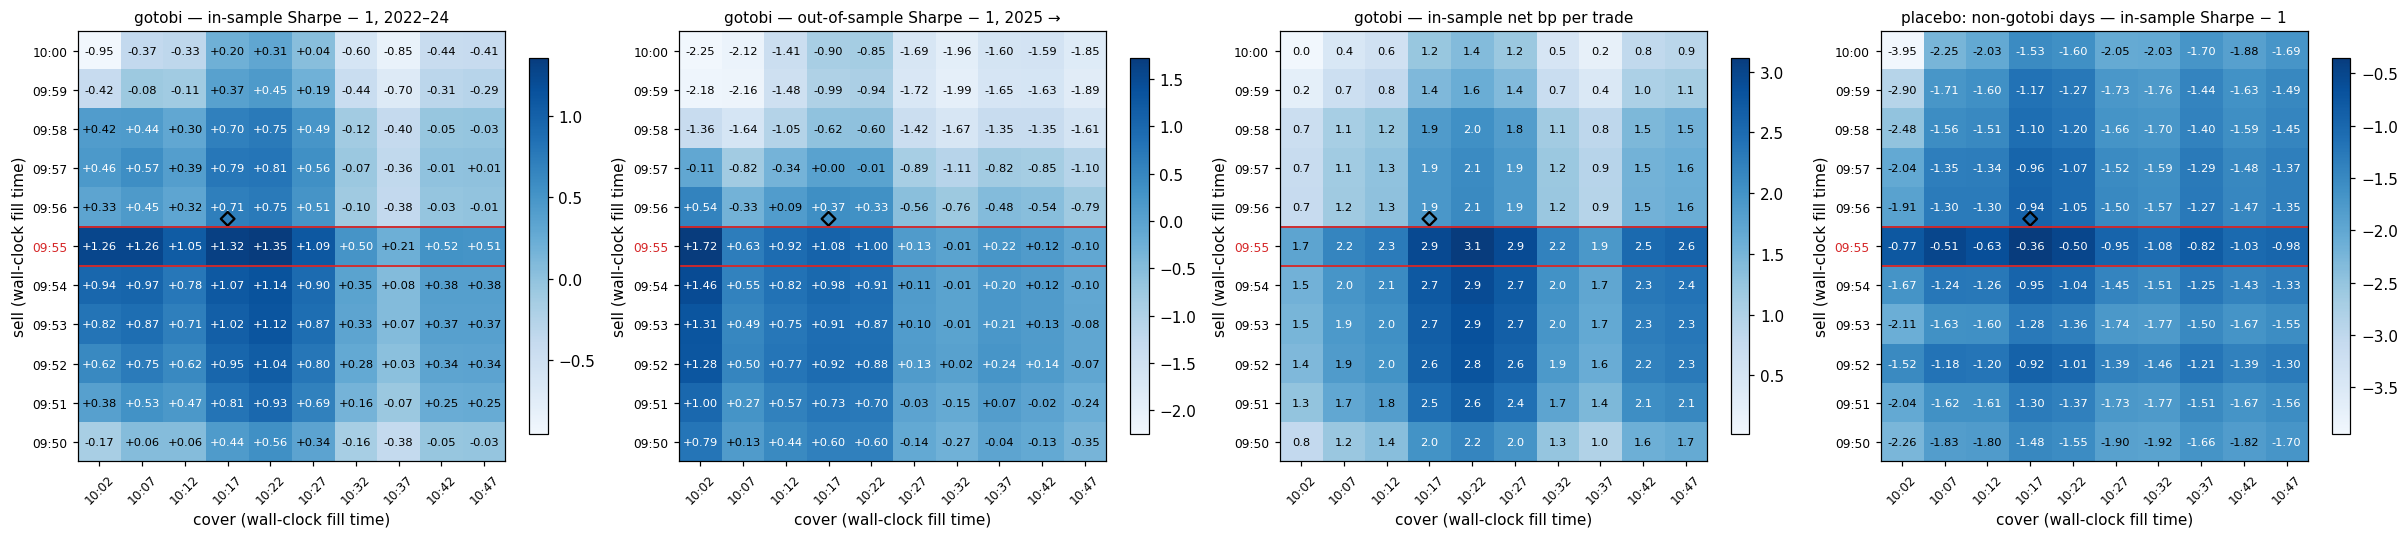

in-sample best: sell 09:55 → cover 10:22: IS 2.35, OOS 2.00, +3.11 bp.   Baseline sell 09:56 → cover 10:16 (diamond): IS 1.71, OOS 1.37.   IS/OOS rank corr 0.73

by sell time, cover 10:16 — IS / OOS Sharpe, bp per trade IS / OOS, and what the entry costs or misses relative to the fix print (gotobi mean, bp):
  sell 09:50: IS 1.44  OOS 1.60   +1.99 / +1.98 bp   | short into the fix: -0.68
  sell 09:51: IS 1.81  OOS 1.73   +2.47 / +2.12 bp   | short into the fix: -0.33
  sell 09:52: IS 1.95  OOS 1.92   +2.63 / +2.34 bp   | short into the fix: -0.14
  sell 09:53: IS 2.02  OOS 1.91   +2.68 / +2.30 bp   | short into the fix: -0.13
  sell 09:54: IS 2.07  OOS 1.98   +2.74 / +2.27 bp   | short into the fix: -0.11
  sell 09:55: IS 2.32  OOS 2.08   +2.94 / +2.23 bp   | the fix print itself
  sell 09:56: IS 1.71  OOS 1.37   +1.94 / +1.33 bp   | drop already gone: +0.96
  sell 09:57: IS 1.79  OOS 1.00   +1.93 / +0.95 bp   | drop already gone: +1.11
  sell 09:58: IS 1.70  OOS 0.38   +1.86 / +0.35 b

In [28]:
# Wall-clock FILL times here. Price index m is the close of the bar that opens at minute m, i.e. wall clock m+1;
# the notebook's "09:55 → 10:15, fills +1 min" rule is lpx[115] → lpx[136] = sell 09:56, cover 10:16 (diamond).
wc = lambda m: lab(m + 1)
ENT = np.arange(109, 120)                                                    # sell at 09:50 … 10:00 wall clock (lpx[109] … lpx[119]); lpx[114] = the 09:55 fix print
EXT = np.arange(121, 167, 5)                                                 # cover at 10:02, 10:07, … 10:47 wall clock (10:16 = the baseline)
BASE = (115, 136)
def sh_(d): return d.mean() / d.std() * np.sqrt(252)
def grid_ee(mask, days):
    S_, M_ = (pd.DataFrame(index=ENT, columns=EXT, dtype=float) for _ in range(2))
    for e in ENT:
        for x in EXT:
            if x <= e: S_.loc[e, x] = M_.loc[e, x] = np.nan; continue
            pnl = -bp(e, x) - TC_DAY * 2 / 3; d = pd.Series(0.0, index=px.index); d[days] = pnl[days]
            S_.loc[e, x], M_.loc[e, x] = sh_(d[mask]), pnl[days & mask].mean()
    return S_, M_
E_is, EM_is = grid_ee(INS, gg); E_oos, EM_oos = grid_ee(~INS, gg); E_pl, _ = grid_ee(INS, ~gg)
fig, ax = plt.subplots(1, 4, figsize=(22, 5))
from matplotlib.colors import LinearSegmentedColormap
BL = LinearSegmentedColormap.from_list("blues_soft", plt.get_cmap("Blues")(np.linspace(.03, .95, 256)))              # very light → dark blue, one hue
for a_, Gd, ttl, fmt in [(ax[0], E_is - 1, "gotobi — in-sample Sharpe − 1, 2022–24", "{:+.2f}"), (ax[1], E_oos - 1, "gotobi — out-of-sample Sharpe − 1, 2025 →", "{:+.2f}"), (ax[2], EM_is, "gotobi — in-sample net bp per trade", "{:.1f}"), (ax[3], E_pl - 1, "placebo: non-gotobi days — in-sample Sharpe − 1", "{:+.2f}")]:
    norm = Normalize(np.nanmin(Gd.values), np.nanmax(Gd.values)); cmap = BL; dark = lambda v: norm(v) > .6
    im = a_.imshow(np.ma.masked_invalid(Gd.values.astype(float)), aspect="auto", origin="lower", cmap=cmap, norm=norm, interpolation="nearest"); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, e in enumerate(ENT):
        for cI, x in enumerate(EXT):
            v = Gd.values[rI, cI]
            if np.isfinite(v): a_.text(cI, rI, fmt.format(v), ha="center", va="center", fontsize=7.5, color="w" if dark(v) else "k")
    fr = list(ENT).index(FIX); a_.axhline(fr - .5, color="C3", lw=1.2); a_.axhline(fr + .5, color="C3", lw=1.2)
    a_.scatter(list(EXT).index(BASE[1]), list(ENT).index(BASE[0]) - .3, marker="D", s=40, facecolor="none", edgecolor="k", lw=1.5)
    a_.set_xticks(range(len(EXT))); a_.set_xticklabels([wc(v) for v in EXT], fontsize=8, rotation=45); a_.set_yticks(range(len(ENT))); a_.set_yticklabels([wc(v) for v in ENT], fontsize=8); a_.get_yticklabels()[fr].set_color("C3")
    a_.set_title(ttl, fontsize=10); a_.set_xlabel("cover (wall-clock fill time)"); a_.set_ylabel("sell (wall-clock fill time)"); a_.grid(False)
plt.tight_layout(); plt.show()
bi = np.unravel_index(np.nanargmax(E_is.values), E_is.shape); be, bx = ENT[bi[0]], EXT[bi[1]]
print(f"in-sample best: sell {wc(be)} → cover {wc(bx)}: IS {E_is.loc[be, bx]:.2f}, OOS {E_oos.loc[be, bx]:.2f}, {EM_is.loc[be, bx]:+.2f} bp.   Baseline sell 09:56 → cover 10:16 (diamond): IS {E_is.loc[BASE]:.2f}, OOS {E_oos.loc[BASE]:.2f}.   IS/OOS rank corr {stats.spearmanr(E_is.values.ravel(), E_oos.values.ravel(), nan_policy='omit').statistic:.2f}")
print("\nby sell time, cover 10:16 — IS / OOS Sharpe, bp per trade IS / OOS, and what the entry costs or misses relative to the fix print (gotobi mean, bp):")
for e in ENT:
    rel = -bp(e, FIX)[gg].mean() if e < FIX else (0.0 if e == FIX else -bp(FIX, e)[gg].mean())
    tag = f"short into the fix: {rel:+.2f}" if e < FIX else ("the fix print itself" if e == FIX else f"drop already gone: {rel:+.2f}")
    print(f"  sell {wc(e)}: IS {E_is.loc[e, 136]:.2f}  OOS {E_oos.loc[e, 136]:.2f}   {EM_is.loc[e, 136]:+.2f} / {EM_oos.loc[e, 136]:+.2f} bp   | {tag}")
print("\nmean cumulative drop from the fix print, minute by minute (gotobi days, bp):")
for lbl, msk in [("in-sample ", gg & INS), ("out-sample", gg & ~INS)]:
    print(f"  {lbl}: " + "  ".join(f"{wc(m)} {-bp(FIX, m)[msk].mean():+.2f}" for m in [115, 116, 117, 118, 119, 120, 124, 129, 134, 136, 144]))

**Interpretation — be short *before* the fix, not after it.**
- **The first minute after the fix is a third of the trade.** From the 09:55 print, USD/JPY is down 1.0 bp by 09:56
  in-sample and 0.9 bp out-of-sample, against a total of 3.2 / 2.4 bp by 10:15. The "fills +1 min" convention used
  everywhere above throws that minute away: selling at the print instead of one minute later takes the rule from
  **1.71 / 1.37 to 2.32 / 2.08** (IS / OOS) and from 1.9 to 2.9 bp per trade.
- **Every further minute of delay is fatal out of sample.** At the 10:16 cover: sell 09:56 → OOS 1.37; 09:57 → 1.00;
  09:58 → 0.38; 09:59 → 0.01. The out-of-sample unwind is finished by 09:59 (−2.2 bp, vs −2.4 at 10:15); in-sample it
  kept drifting to 10:15. A desk that reacts to the fix rather than anticipating it has, since 2025, been trading noise.
- **Being short into the fix costs almost nothing and guarantees the print.** The last three pre-fix minutes carry
  −0.1 bp of climb on gotobi days; selling at 09:52–09:54 scores **1.95–2.07 in-sample and 1.91–1.98 out-of-sample** —
  the best rows in the out-of-sample panel apart from the print itself, and all above the 09:56 baseline. Even a
  09:50 entry (−0.7 bp of climb carried) gives 1.44 / 1.60. Out of sample, *every* pre-fix row beats *every*
  post-fix row. The placebo panel is negative or ≈ 0 everywhere except a faint 0.6 at the print — this is gotobi.
- **Exit is unchanged.** Each row peaks at 10:17–10:22 in-sample and is flat 10:07–10:22 out-of-sample, with the
  same cliff after 10:27 as in sections 6 and 6d. 10:15–10:20 stands.
- **Caveats.** Selling before the fix is trivially executable (there is no rule against being short at 09:55) but it
  changes the character of the position: the short is now exposed to the fix print itself, which is the most volatile
  minute of the Tokyo morning (section 2), so the worst days get worse. The improvement from 09:56 to 09:53 is
  driven by not missing the first minute, not by the pre-fix climb reversing. The IS/OOS rank correlation across the
  grid is 0.45, lower than the other grids, because the post-fix rows collapse out of sample while the pre-fix rows
  hold — that *is* the finding.
- **Reading.** The parameters are **sell 09:53 (± a minute), cover 10:15–10:20**, size linear in regime vol
  (section 6d). Out of sample that is a Sharpe ≈ 1.9–2.0 on the flat-size version, versus 1.37 for the
  react-after-the-fix version pitched above. The edge lives in the print and the minute after it; the rest of the
  notebook's conservatism about fills was hiding a third of the trade.

**What this does.** A walk-forward optimisation over two *meta*-parameters instead of the entry/exit times themselves:
- **lookback (months):** on each gotobi day, take only the previous *L* months of gotobi days, pick the entry/exit pair
  (same 08:00–08:50 × 10:00–10:45 grid) with the best Sharpe over that window, and trade today with it. Nothing from
  the future is used; the parameters re-fit every day.
- **balance ratio *r* = long notional ÷ short notional**, from 0 (short only) to 1 (equal legs). The short is always
  1 unit; the long is *r* units. Cost is 0.25 bp per unit filled (entry *r*, flip 1 + *r*, cover 1 → 0.5 × (1 + *r*)
  bp/day), fills one minute late.
Every (lookback, ratio) pair is scored on the same period — **2023-10 → 2026-09**, the first day on which the longest
lookback has enough history — so the cells are comparable. Heatmaps: walk-forward Sharpe and mean bp/day.

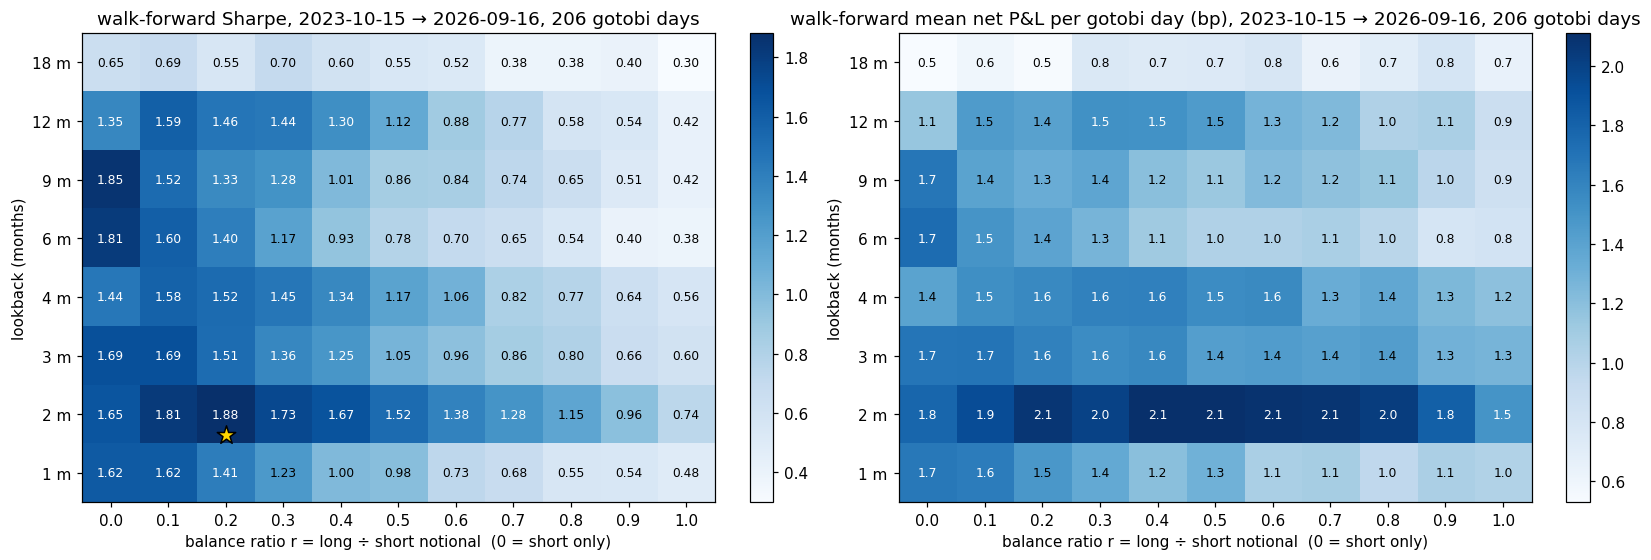

best: lookback 2 m, ratio 0.2 → Sharpe 1.88, +2.07 bp/day;   short-only (r=0) best lookback: 9 m, Sharpe 1.85
Sharpe by ratio, averaged over lookbacks:  r=0.0: 1.51, r=0.1: 1.51, r=0.2: 1.38, r=0.3: 1.29, r=0.4: 1.14, r=0.5: 1.00, r=0.6: 0.88, r=0.7: 0.77, r=0.8: 0.68, r=0.9: 0.58, r=1.0: 0.49
Sharpe by lookback, averaged over ratios:  1m: 0.99, 2m: 1.43, 3m: 1.13, 4m: 1.12, 6m: 0.94, 9m: 1.00, 12m: 1.04, 18m: 0.52

parameters chosen day-by-day at the best cell — exit: 10:00 33%, 10:05 11%, 10:10 7%, 10:15 7%, 10:20 16%, 10:25 6%, 10:30 2%, 10:35 7%, 10:40 5%, 10:45 4%   |   entry: 08:00 32%, 08:05 15%, 08:10 12%, 08:50 18%


In [29]:
LBs = [1, 2, 3, 4, 6, 9, 12, 18]; RATS = np.round(np.arange(0, 1.01, .1), 1)
ents = np.arange(0, 51, 5); exts = np.arange(6, 52, 5)
Lm = np.column_stack([bp(e + LAG, FIX + LAG).values for e in ents])          # all days × entries (long leg, fills +1)
Sm = np.column_stack([-bp(FIX + LAG, FIX + x + LAG).values for x in exts])   # all days × exits  (short leg, fills +1)
gidx = np.where(gg)[0]; gdates = px.index[gidx]
eval_start = gdates[0] + pd.DateOffset(months=max(LBs)); eval_days = gidx[gdates >= eval_start]
WF = {}; CH = {}
for L_ in LBs:
    for r_ in RATS:
        pnl = pd.Series(0.0, index=px.index); chosen = []
        for t in eval_days:
            d0 = px.index[t] - pd.DateOffset(months=L_); lb = gidx[(gdates >= d0) & (gdates < px.index[t])]
            Pl = r_ * Lm[lb][:, :, None] + Sm[lb][:, None, :] - .5 * (1 + r_)
            sr = Pl.mean(0) / Pl.std(0, ddof=1); ei, xi = np.unravel_index(np.nanargmax(sr), sr.shape)
            pnl.iloc[t] = r_ * Lm[t, ei] + Sm[t, xi] - .5 * (1 + r_); chosen.append((ents[ei], exts[xi]))
        WF[(L_, r_)] = pnl; CH[(L_, r_)] = chosen
ev = px.index >= eval_start
SRwf = pd.DataFrame({r_: {L_: WF[(L_, r_)][ev].mean() / WF[(L_, r_)][ev].std() * np.sqrt(252) for L_ in LBs} for r_ in RATS})
MUwf = pd.DataFrame({r_: {L_: WF[(L_, r_)][ev][WF[(L_, r_)][ev] != 0].mean() for L_ in LBs} for r_ in RATS})
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
from matplotlib.colors import Normalize
for a_, Gd, ttl, fmt in [(ax[0], SRwf, "walk-forward Sharpe", "{:.2f}"), (ax[1], MUwf, "walk-forward mean net P&L per gotobi day (bp)", "{:.1f}")]:
    norm = Normalize(Gd.values.min(), Gd.values.max()); im = a_.imshow(Gd.values, aspect="auto", origin="lower", cmap="Blues", norm=norm); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, L_ in enumerate(LBs):
        for cI, r_ in enumerate(RATS): a_.text(cI, rI, fmt.format(Gd.values[rI, cI]), ha="center", va="center", fontsize=8, color="w" if norm(Gd.values[rI, cI]) > .6 else "k")
    a_.set_xticks(range(len(RATS))); a_.set_xticklabels([f"{r_:.1f}" for r_ in RATS]); a_.set_yticks(range(len(LBs))); a_.set_yticklabels([f"{L_} m" for L_ in LBs])
    a_.set_xlabel("balance ratio r = long ÷ short notional  (0 = short only)"); a_.set_ylabel("lookback (months)"); a_.set_title(f"{ttl}, {eval_start.date()} → {px.index[-1].date()}, {len(eval_days)} gotobi days"); a_.grid(False)
bi = np.unravel_index(np.nanargmax(SRwf.values), SRwf.shape); ax[0].scatter(bi[1], bi[0] - .35, marker="*", s=160, color="gold", edgecolor="k")
plt.tight_layout(); plt.show()
bL, bR = LBs[bi[0]], RATS[bi[1]]
print(f"best: lookback {bL} m, ratio {bR:.1f} → Sharpe {SRwf.iloc[bi]:.2f}, {MUwf.iloc[bi]:+.2f} bp/day;   short-only (r=0) best lookback: {SRwf[0.0].idxmax()} m, Sharpe {SRwf[0.0].max():.2f}")
print("Sharpe by ratio, averaged over lookbacks:  " + ", ".join(f"r={r_:.1f}: {SRwf[r_].mean():.2f}" for r_ in RATS))
print("Sharpe by lookback, averaged over ratios:  " + ", ".join(f"{L_}m: {SRwf.loc[L_].mean():.2f}" for L_ in LBs))
ch = pd.DataFrame(CH[(bL, bR)], columns=["entry", "exit"]); print(f"\nparameters chosen day-by-day at the best cell — exit: " + ", ".join(f"{lab(FIX + k)} {v / len(ch):.0%}" for k, v in ch.exit.value_counts().sort_index().items()) + "   |   entry: " + ", ".join(f"{lab(k)} {v / len(ch):.0%}" for k, v in ch.entry.value_counts().sort_index().items() if v / len(ch) >= .08))

**Interpretation.** (206 gotobi days, 2023-10 → 2026-09; every cell is genuinely out of sample — each day's entry/exit
was chosen from the previous *L* months only.)
- **Ratio: the smaller the long leg, the better, monotonically.** Averaged over lookbacks, Sharpe is 1.51 at r = 0,
  1.38 at 0.2, 1.00 at 0.5, 0.49 at 1.0. Every row shows the same slope. The best cell (2 m, r = 0.2, Sharpe 1.88) is
  statistically identical to short-only at 9 m (1.85); r = 0.1–0.2 buys a little extra P&L (+2.1 vs +1.7 bp/day on the
  2-month row) for no Sharpe. **Optimal ratio ≈ 0–0.2: a token long, or none.** This is sections 5b and the short-only
  P&L again, now confirmed walk-forward.
- **Lookback: 2–12 months all work; 18 months does not.** Row averages: 1 m 0.99, 2 m 1.43, 3–4 m 1.1, 6–12 m 0.9–1.0,
  18 m 0.52. The 18-month row is the only clearly bad one — it drags 2022's intervention-year parameters into 2024–25.
  One month is too few trades (~6) to choose from. For short-only, 6–12 months is the sweet spot (1.35–1.85); the
  2-month row's dominance across all ratios is partly luck — with ~12 trades to fit on, the day-by-day choices at the
  best cell scatter across every exit from 10:00 to 10:45 and it still works only because the exit surface is a plateau.
- **What the re-fitting actually chose.** At the best cell the exit was 10:00 a third of the time, 10:20 a sixth, and
  spread thinly elsewhere; the entry sat at the grid edges (08:00 or 08:50 half the time). That is what noise looks like.
  A fixed 10:15 exit (section 6, short-only, Sharpe 1.37 on 2025 →) is not worse than any of this — the walk-forward's
  higher numbers come from a longer, easier evaluation window (it includes late 2023–2024), not from adaptivity.
- **Reading.** Two conclusions survive: (i) do not carry a long leg for Sharpe — r ≈ 0–0.2; (ii) if you re-fit at all,
  use a 3–12-month window and expect it to add nothing over a fixed 09:55→10:15 exit. The anomaly is stable enough that
  the meta-parameters barely matter — which is the reassuring answer.

**What this does.** Adds the morning-vol condition from section 5c to the walk-forward and optimises two things:
- **vol-sizing exponent *p*:** on gotobi days whose 08:00–09:55 realised vol is **≥ 1.25 bp/min** (Q3 and above), the
  short is sized at (vol ÷ 1.25)^*p* units, capped at 3×; *p* = 0 is a flat 1 unit on every qualifying day, *p* = 1 is
  linear in vol, *p* = 2 is aggressive. Below 1.25 the short is skipped.
- **lookback *L* (months):** as before, entry and exit are re-chosen each day from the previous *L* months of gotobi days.

Because full-morning vol is not known until 09:54, it cannot condition a long opened at 08:xx without look-ahead. The
long leg is therefore kept **unconditional at r = 0.2** (the optimum from the grid above) on every gotobi day; only the
short is filtered and sized. Cost 0.25 bp per unit filled, fills one minute late. Scored on the same 2023-10 → 2026-09
window. Reference lines: the unfiltered r = 0.2 walk-forward from the grid above.

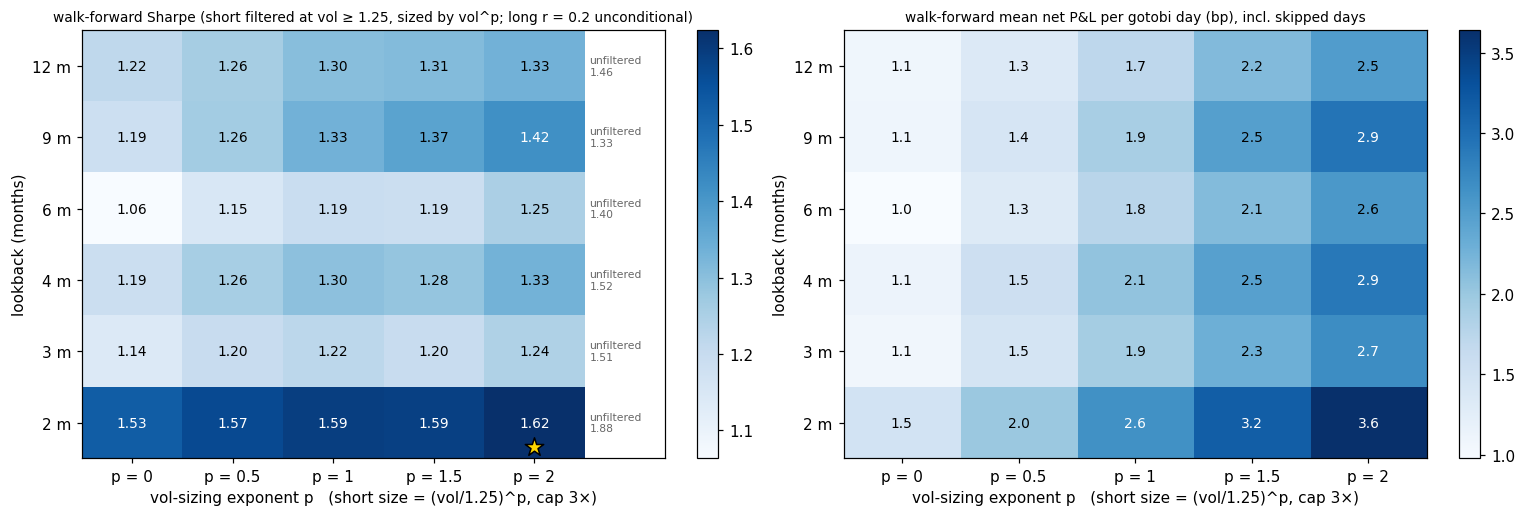

best: lookback 2 m, p = 2 → Sharpe 1.62, +3.64 bp per gotobi day;   unfiltered r=0.2 at 2 m: 1.88
filter: short traded on 50% of gotobi days (102 of 206);  at p = 2: mean size when traded 2.01×, max 3.00×, share of traded days at the 3× cap 25%
Sharpe by p, averaged over lookbacks:  p=0: 1.22, p=0.5: 1.28, p=1: 1.32, p=1.5: 1.32, p=2: 1.37   |   unfiltered r=0.2 average: 1.52
Sharpe by lookback, averaged over p:   2m: 1.58, 3m: 1.20, 4m: 1.27, 6m: 1.17, 9m: 1.31, 12m: 1.28

filter only (p = 0) vs filter + sizing (p = 2) at 2 m:  Sharpe 1.53 vs 1.62;  worst day -21 vs -53 bp;  max drawdown -41 vs -68 bp

same sizing with NO threshold (short on every gotobi day, size = (vol/1.25)^p, cap 3×), by lookback:
   2 m:  p=0: 1.88 (+2.1 bp)   p=0.5: 1.86 (+2.5 bp)   p=1: 1.81 (+3.1 bp)   p=1.5: 1.75 (+3.5 bp)   p=2: 1.76 (+4.0 bp)


   3 m:  p=0: 1.51 (+1.6 bp)   p=0.5: 1.48 (+1.9 bp)   p=1: 1.42 (+2.3 bp)   p=1.5: 1.34 (+2.6 bp)   p=2: 1.36 (+2.9 bp)
   4 m:  p=0: 1.52 (+1.6 bp)   p=0.5: 1.50 (+1.9 bp)   p=1: 1.47 (+2.4 bp)   p=1.5: 1.42 (+2.8 bp)   p=2: 1.43 (+3.1 bp)


   6 m:  p=0: 1.40 (+1.4 bp)   p=0.5: 1.41 (+1.7 bp)   p=1: 1.39 (+2.1 bp)   p=1.5: 1.33 (+2.4 bp)   p=2: 1.37 (+2.8 bp)
   9 m:  p=0: 1.33 (+1.3 bp)   p=0.5: 1.39 (+1.6 bp)   p=1: 1.44 (+2.1 bp)   p=1.5: 1.46 (+2.7 bp)   p=2: 1.49 (+3.1 bp)


  12 m:  p=0: 1.46 (+1.4 bp)   p=0.5: 1.46 (+1.6 bp)   p=1: 1.47 (+2.0 bp)   p=1.5: 1.43 (+2.4 bp)   p=2: 1.44 (+2.7 bp)


In [30]:
VTH, RFIX, CAP = 1.25, 0.2, 3.0; PS = [0, 0.5, 1, 1.5, 2]; LB2 = [2, 3, 4, 6, 9, 12]
mvol = r1.loc[:, 1:FIX].std(axis=1).values
WF2, SZ = {}, {}
for L_ in LB2:
    for p_ in PS:
        pnl = pd.Series(0.0, index=px.index); sizes = []
        for t in eval_days:
            d0 = px.index[t] - pd.DateOffset(months=L_); lb = gidx[(gdates >= d0) & (gdates < px.index[t])]
            Pl = RFIX * Lm[lb][:, :, None] + Sm[lb][:, None, :] - .5 * (1 + RFIX); sr = Pl.mean(0) / Pl.std(0, ddof=1); ei, xi = np.unravel_index(np.nanargmax(sr), sr.shape)
            sz = min((mvol[t] / VTH) ** p_, CAP) if mvol[t] >= VTH else 0.0; sizes.append(sz)
            pnl.iloc[t] = RFIX * Lm[t, ei] + sz * Sm[t, xi] - .5 * (RFIX + sz)      # cost: 0.25 × (r + (r + sz) + sz)
        WF2[(L_, p_)] = pnl; SZ[(L_, p_)] = np.array(sizes)
SR2 = pd.DataFrame({p_: {L_: WF2[(L_, p_)][ev].mean() / WF2[(L_, p_)][ev].std() * np.sqrt(252) for L_ in LB2} for p_ in PS})
MU2 = pd.DataFrame({p_: {L_: WF2[(L_, p_)][ev].iloc[np.isin(np.where(ev)[0], eval_days - ev.argmax())].mean() if False else WF2[(L_, p_)].iloc[eval_days].mean() for L_ in LB2} for p_ in PS})
ref = {L_: SRwf.loc[L_, 0.2] for L_ in LB2}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for a_, Gd, ttl, fmt in [(ax[0], SR2, "walk-forward Sharpe (short filtered at vol ≥ 1.25, sized by vol^p; long r = 0.2 unconditional)", "{:.2f}"), (ax[1], MU2, "walk-forward mean net P&L per gotobi day (bp), incl. skipped days", "{:.1f}")]:
    norm = Normalize(Gd.values.min(), Gd.values.max()); im = a_.imshow(Gd.values, aspect="auto", origin="lower", cmap="Blues", norm=norm); plt.colorbar(im, ax=a_, fraction=.04)
    for rI, L_ in enumerate(LB2):
        for cI, p_ in enumerate(PS): a_.text(cI, rI, fmt.format(Gd.values[rI, cI]), ha="center", va="center", fontsize=9, color="w" if norm(Gd.values[rI, cI]) > .6 else "k")
    a_.set_xticks(range(len(PS))); a_.set_xticklabels([f"p = {p_}" for p_ in PS]); a_.set_yticks(range(len(LB2))); a_.set_yticklabels([f"{L_} m" for L_ in LB2])
    a_.set_xlabel("vol-sizing exponent p   (short size = (vol/1.25)^p, cap 3×)"); a_.set_ylabel("lookback (months)"); a_.set_title(ttl, fontsize=9); a_.grid(False)
for rI, L_ in enumerate(LB2): ax[0].text(len(PS) - .45, rI, f"unfiltered\n{ref[L_]:.2f}", va="center", fontsize=7, color="0.4")
bi = np.unravel_index(np.nanargmax(SR2.values), SR2.shape); ax[0].scatter(bi[1], bi[0] - .35, marker="*", s=160, color="gold", edgecolor="k"); ax[0].set_xlim(-.5, len(PS) + .3)
plt.tight_layout(); plt.show()
bL, bP = LB2[bi[0]], PS[bi[1]]; sz = SZ[(bL, bP)]
print(f"best: lookback {bL} m, p = {bP} → Sharpe {SR2.iloc[bi]:.2f}, {MU2.iloc[bi]:+.2f} bp per gotobi day;   unfiltered r=0.2 at {bL} m: {ref[bL]:.2f}")
print(f"filter: short traded on {(sz > 0).mean():.0%} of gotobi days ({(sz > 0).sum()} of {len(sz)});  at p = {bP}: mean size when traded {sz[sz > 0].mean():.2f}×, max {sz.max():.2f}×, share of traded days at the 3× cap {(sz >= CAP).mean() / max((sz > 0).mean(), 1e-9):.0%}")
print("Sharpe by p, averaged over lookbacks:  " + ", ".join(f"p={p_}: {SR2[p_].mean():.2f}" for p_ in PS) + f"   |   unfiltered r=0.2 average: {np.mean(list(ref.values())):.2f}")
print("Sharpe by lookback, averaged over p:   " + ", ".join(f"{L_}m: {SR2.loc[L_].mean():.2f}" for L_ in LB2))
flat = WF2[(bL, 0)]; best_ = WF2[(bL, bP)]
print(f"\nfilter only (p = 0) vs filter + sizing (p = {bP}) at {bL} m:  Sharpe {flat[ev].mean() / flat[ev].std() * np.sqrt(252):.2f} vs {best_[ev].mean() / best_[ev].std() * np.sqrt(252):.2f};  worst day {flat.min():+.0f} vs {best_.min():+.0f} bp;  max drawdown {(flat.cumsum() - flat.cumsum().cummax()).min():+.0f} vs {(best_.cumsum() - best_.cumsum().cummax()).min():+.0f} bp")
print("\nsame sizing with NO threshold (short on every gotobi day, size = (vol/1.25)^p, cap 3×), by lookback:")
for L_ in LB2:
    row = []
    for p_ in PS:
        pnl = pd.Series(0.0, index=px.index)
        for t in eval_days:
            d0 = px.index[t] - pd.DateOffset(months=L_); lb = gidx[(gdates >= d0) & (gdates < px.index[t])]
            Pl = RFIX * Lm[lb][:, :, None] + Sm[lb][:, None, :] - .5 * (1 + RFIX); sr = Pl.mean(0) / Pl.std(0, ddof=1); ei, xi = np.unravel_index(np.nanargmax(sr), sr.shape)
            sz = min((mvol[t] / VTH) ** p_, CAP); pnl.iloc[t] = RFIX * Lm[t, ei] + sz * Sm[t, xi] - .5 * (RFIX + sz)
        row.append(f"p={p_}: {pnl[ev].mean() / pnl[ev].std() * np.sqrt(252):.2f} ({pnl.iloc[eval_days].mean():+.1f} bp)")
    print(f"  {L_:2d} m:  " + "   ".join(row))

**Interpretation.** (Walk-forward, 206 gotobi days 2023-10 → 2026-09; the grey numbers beside each row are the
unfiltered r = 0.2 result from the grid above, same lookback.)
- **The ≥ 1.25 filter *lowers* Sharpe in every row.** Filtered p = 0 (flat size on qualifying days) averages 1.22 across
  lookbacks vs 1.52 unfiltered; at the best lookback it is 1.53 vs 1.88. The reason is arithmetic, not a failure of
  section 5c: quiet-morning gotobi days still drop (Q1–Q2 mean −1.3 to −1.6 bp, i.e. positive expectancy for the short),
  and skipping half the days throws that P&L away while cutting the trade count — Sharpe scales with √n. A filter helps
  only if the skipped days have *negative* expectancy; here they merely have less.
- **Sizing by vol helps a little, and mostly in bp.** Within the filtered grid, p = 0 → p = 2 lifts Sharpe 1.22 → 1.37
  on average and P&L per day 1.1 → 2.5 bp, at the cost of a worst day of −53 bp instead of −21 and a −68 bp drawdown
  instead of −41. A quarter of traded days sit at the 3× cap, so the heaviest sizing lands on the fat-tailed Q5 mornings.
- **Better: no threshold, mild sizing.** The block printed under the chart runs the same sizing on *every* gotobi day.
  At 2 m: p = 0 1.88, p = 0.5 1.86, p = 1 1.81 — Sharpe flat, while P&L per day rises 2.1 → 2.5 → 3.1 bp. At 9 m sizing
  actually helps (1.33 → 1.49). Across lookbacks the unfiltered-sized rows dominate the filtered ones at the same p.
  So the morning-vol signal is best used as a **position-size dial, not an on/off switch**: trade every settlement day,
  scale the short roughly linearly with morning vol (p ≈ 0.5–1), cap it.
- **Lookback:** 2 months is best again, but by the same noisy margin as before; 3–12 months are a plateau (1.2–1.5).
  Nothing here changes the earlier conclusion that the lookback barely matters.
- **The long leg was carried unconditionally at r = 0.2** because morning vol is unknown at 08:xx. That is a small drag
  on skipped days (long cost with no short) and part of why the filtered rows look worse. Dropping the long leg entirely
  (r = 0) would tighten every number here.
- **Reading.** Keep the calendar filter, drop the vol threshold, size by vol with p ≈ 0.5–1 and a cap, expect ≈ +2.5–3
  bp per gotobi day at Sharpe ≈ 1.4–1.8 walk-forward — and treat the 2-month lookback's edge as luck.

## 7. Conclusion

| question | answer |
|---|---|
| Is 09:55 still a fix event? | Yes — 1.7× the volatility of neighbouring minutes, every year. |
| Is the classic gotobi pre-fix drift still there? | Not in 09:00–09:55. It has been front-run into **08:00–09:00**, and survives only on the 25th and month-end. |
| Is there a post-fix reversal? | **Yes: −2.5 bp on gotobi days vs ≈ 0 otherwise**, concentrated in the first 20 minutes after the fix, carried by the 20th/25th/month-end. |
| Is it significant? | Permutation p = 0.003; true calendar beats all 10 shifts; specific to the fix time; robust to outliers and controls (t = −3.3). |
| Is it tradeable? | At interbank cost, yes: ≈ +2 bp/trade, Sharpe ≈ 1.5. At 2 bp cost, no. |
| Is the long leg (pre-fix) worth carrying? | **No.** Long 08:25→09:55 has α ≈ +1 bp (t ≈ 1.3) under every definition of the trend, Sharpe 0.03 out of sample, 2022 = 94 % of its P&L. Short-only is the pitch. |
| Are some settlement days better? | **No.** At the 10:15 exit all six types drop the same (+1.6 to +3.1 bp, ANOVA p = 0.98). Heavy days (20th/25th/EOM) only unwind for longer; light days bounce back after 10:15. Trade them all. |
| Does vol sizing help? | Not on this morning's vol (it predicts risk as much as reward). **Yes on regime vol**: per-trade Sharpe is 0.06 / 0.14 / 0.53 across terciles of the trailing 20-day range, within years too; sizing linearly in it lifts Sharpe 1.85 → 2.09 in-sample and 1.53 → 1.61 out. |
| When to enter? | **Before the fix.** A third of the drop happens in the minute after the 09:55 print; out of sample the unwind is over by 09:59. Sell 09:52–09:54 (−0.1 bp of climb carried), cover 10:15–10:20: Sharpe ≈ 2.0 in- and out-of-sample vs 1.7 / 1.4 for selling at 09:56. |
| Is it stable? | Negative in 2022–2025; weakest in 2026 — which is also the lowest-vol year (trailing range 28 bp vs 43–52), and the regime terciles predict ≈ 0 in that state. Consistent with a vol-dependent effect in a quiet year; decay not yet separable from it. |

**The pitch in one sentence.** A textbook FX anomaly, ten years after publication: the front half has been competed away
and pushed an hour earlier, the back half still pays about 2 bp on ~70 days a year — and if it is real, it should be gone
by the time anyone re-runs this notebook. That is a falsifiable prediction, which is more than most pitches offer.

**Caveats.** 4.4 years of data (2022-04 → 2026-09; the pull hit the API's daily cap — set `RUN_PULL = True` to extend
to 2020); vendor composite feed rather than a Tokyo interbank feed; the fix minute is assumed to be 09:55:00 (the 09:54
close); 0.5 bp is a conservative interbank cost and optimistic for anyone else; six windows were tested and the
headline p = 0.003 survives a Bonferroni correction, but the post-fix reversal was the pre-stated hypothesis, not a search result.